In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from utils import (
    load_benchmark_results,
    compute_winrates,
    compute_elo_scores,
    compute_absolute_improvements,
    plot_leaderboard,
    plot_grouped_leaderboards,
    plot_cd_diagram,
)

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern"],
    "font.size": 12,
    "axes.labelsize": 14,
    "axes.titlesize": 16,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "figure.dpi": 300,
    "pdf.fonttype": 42,
})

# Binary benchmarks

In [2]:
binary_methods = [
    "Base-model",
    "Hist-uniform",
    "Hist-quantile",
    "Scaling-Binning",
    "BBQ",
    "Isotonic",
    "CIR",
    "Venn-Abers",
    "TS",
    "ETS",
    "Platt",
    "Affine",
    "Quadratic",
    "Beta",
    "Spline",
    "CDF-Spline",
    "Kernel",
    "XGBoost",
    "LightGBM",
    "CatBoost",
]

binary_metrics = {
    "brier": "min",
    "logloss": "min",
    "kuiper": "min",
    "ece-15": "min",
    "accuracy": "max",
}

## TabRepo-binary

In [3]:
binary_tabrepo_results = load_benchmark_results(benchmark_name="TabRepo-binary", methods=binary_methods)

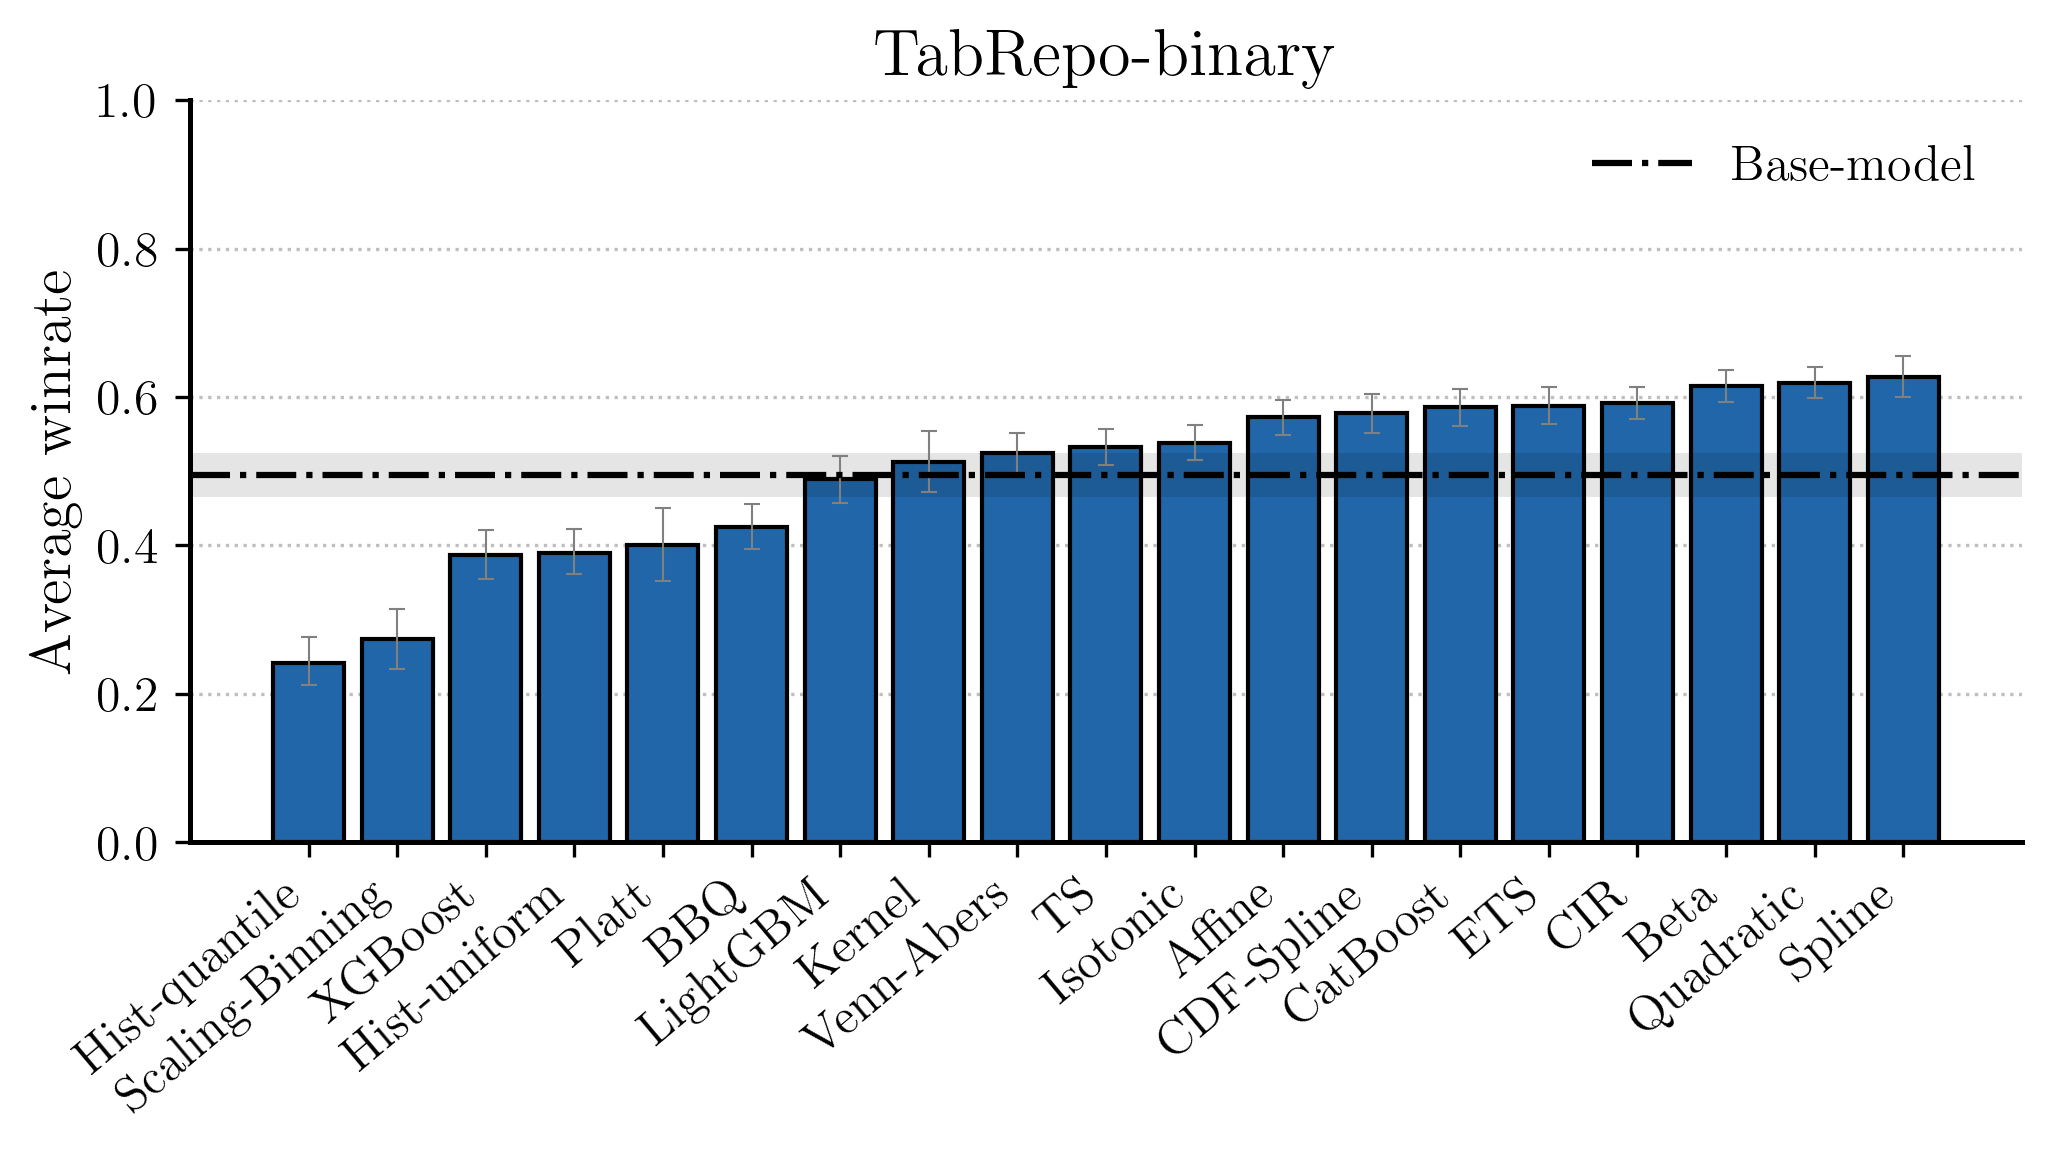

In [4]:
binary_tabrepo_winrates = compute_winrates(binary_tabrepo_results, binary_methods, metric="brier", bootstrap_datasets=True, n_bootstraps=1000)
plot_leaderboard(
    binary_tabrepo_winrates,
    title="TabRepo-binary",
    y_label="Average winrate",
    y_lim=(0,1),
    savefile="figures/binary_tabrepo_winrates.pdf"
)

Bootstrapping datasets: 100%|██████████| 100/100 [00:30<00:00,  3.28it/s]


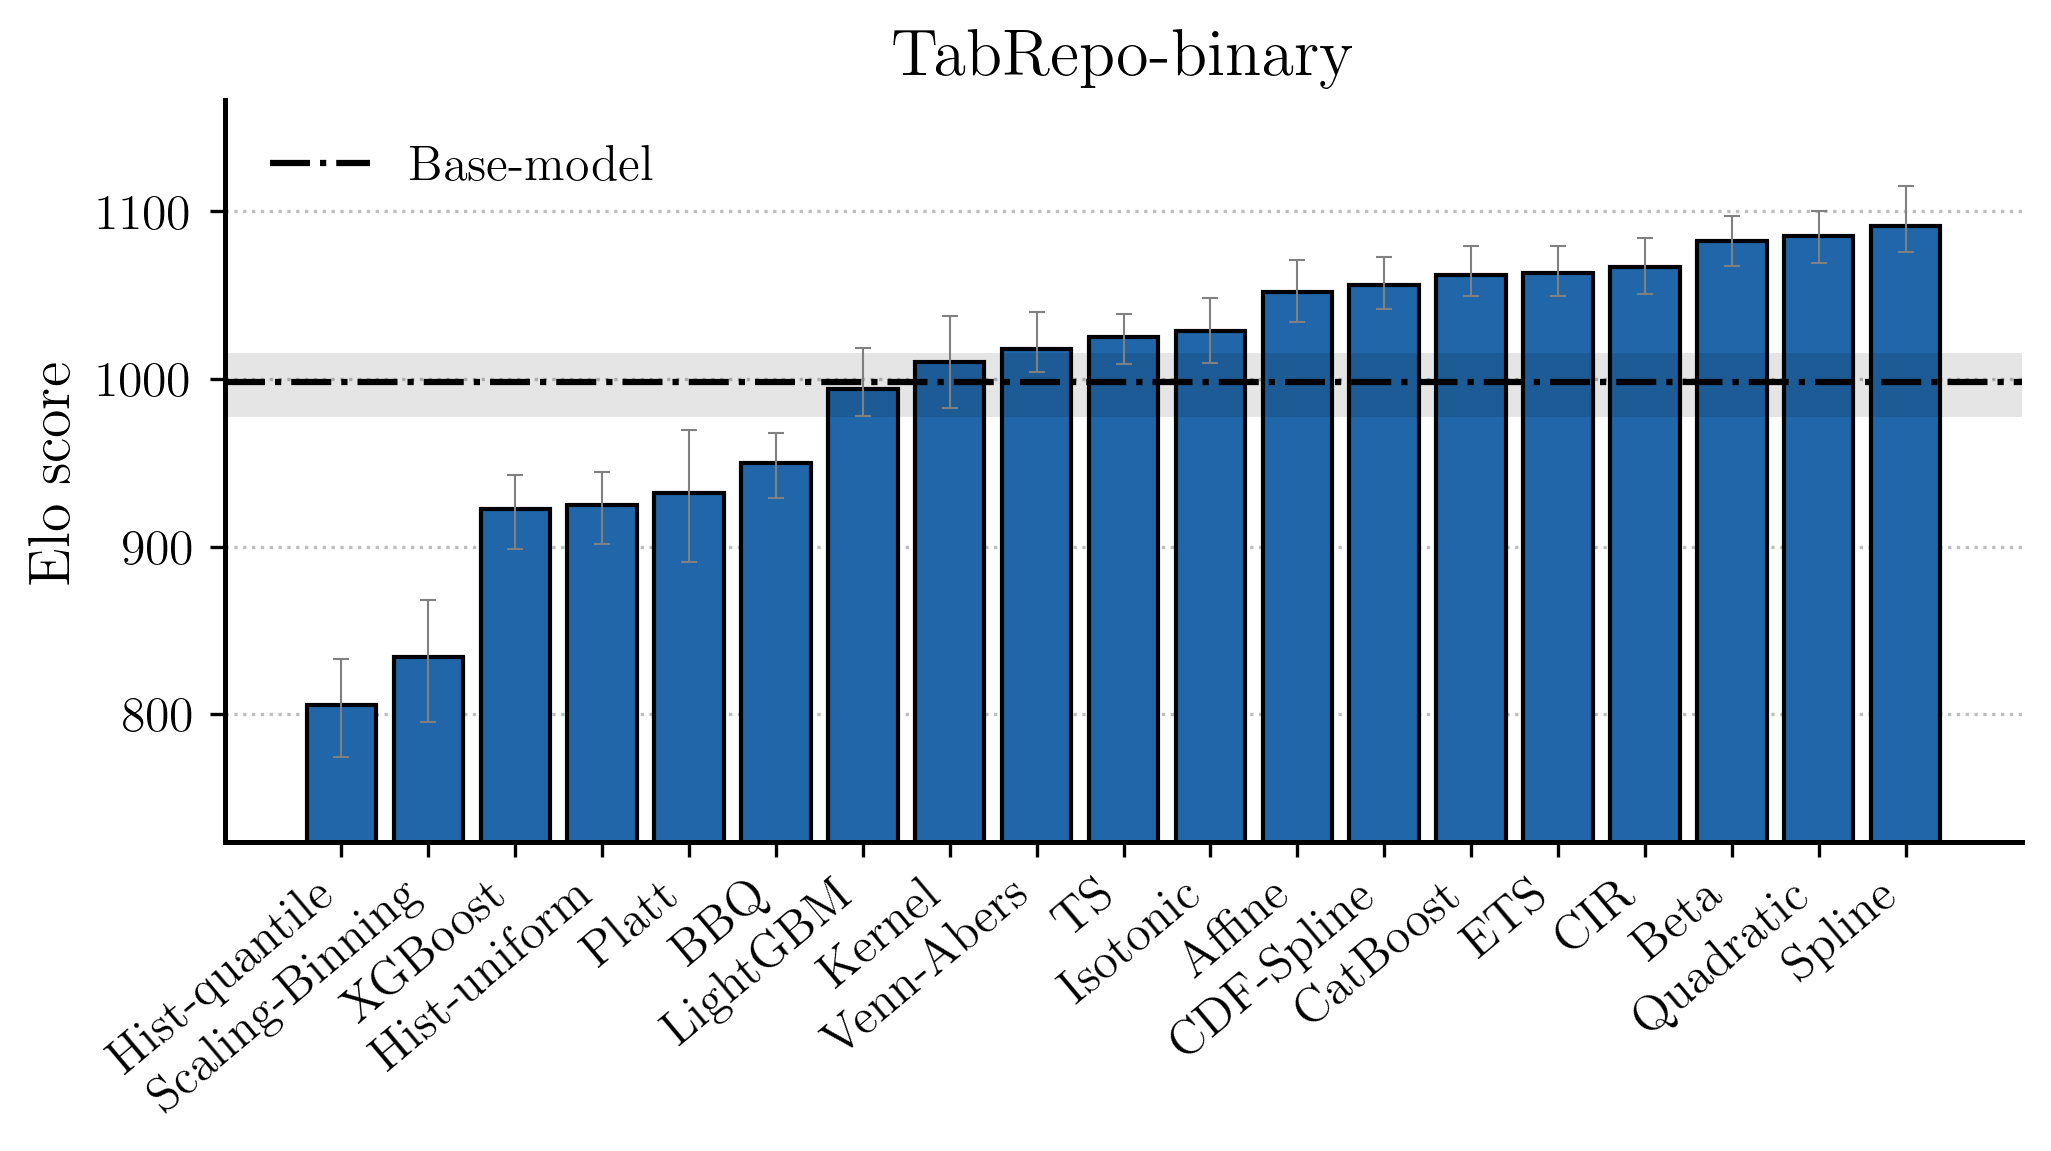

In [5]:
binary_tabrepo_elo = compute_elo_scores(binary_tabrepo_results, binary_methods, bootstrap_datasets=True, num_bootstrap=100)
plot_leaderboard(
    binary_tabrepo_elo,
    title="TabRepo-binary",
    y_label="Elo score",
    savefile="figures/binary_tabrepo_elo.pdf"
)


Friedman Test Statistic: nan
P-Value: nan
Result: No significant difference found. Stop here.


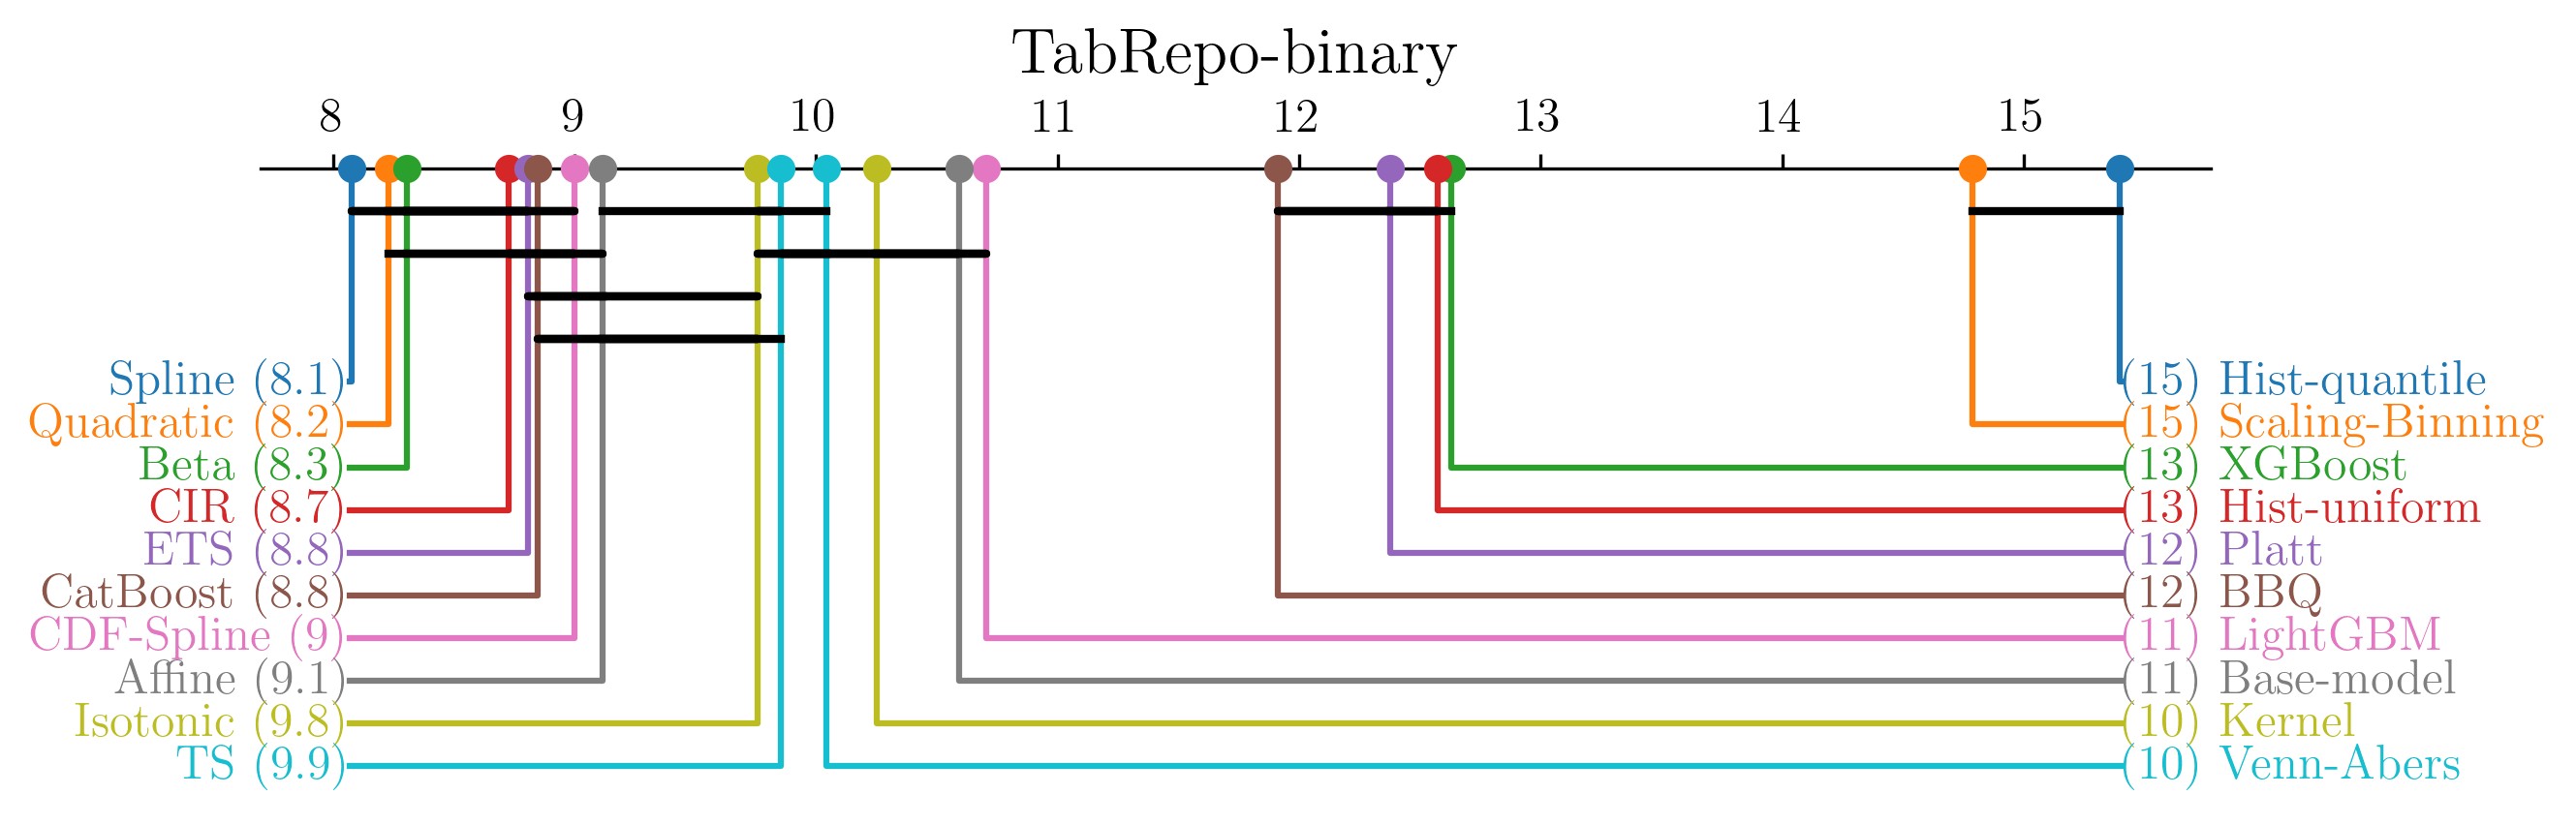

In [6]:
plot_cd_diagram(
    binary_tabrepo_results,
    binary_methods,
    metric="brier",
    groupby_dataset=False,
    title="TabRepo-binary",
    savefile="figures/binary_tabrepo_cd.pdf"
)

In [7]:
binary_tabrepo_absolute = compute_absolute_improvements(
    results=binary_tabrepo_results,
    methods=binary_methods,
    metrics=binary_metrics,
    use_num_datasets=True,
    precision=2,
    factor=100
)
print(binary_tabrepo_absolute.to_latex())

\begin{tabular}{llllll}
\toprule
 & Brier & Logloss & Kuiper & Ece-15 & Accuracy \\
Method &  &  &  &  &  \\
\midrule
Quadratic & $\phantom{-}0.36$ {\tiny $\pm 0.39$} (\#1) & $\phantom{-}1.27$ {\tiny $\pm 2.44$} (\#6) & $\phantom{-}0.43$ {\tiny $\pm 0.31$} (\#5) & $\phantom{-}0.92$ {\tiny $\pm 0.62$} (\#13) & $\phantom{-}0.03$ {\tiny $\pm 0.26$} (\#4) \\
Spline & $\phantom{-}0.35$ {\tiny $\pm 0.39$} (\#2) & $\phantom{-}0.86$ {\tiny $\pm 2.92$} (\#13) & $\phantom{-}0.44$ {\tiny $\pm 0.31$} (\#3) & $\phantom{-}1.03$ {\tiny $\pm 0.64$} (\#11) & $-0.01$ {\tiny $\pm 0.32$} (\#9) \\
ETS & $\phantom{-}0.35$ {\tiny $\pm 0.38$} (\#3) & $\phantom{-}1.63$ {\tiny $\pm 2.33$} (\#3) & $\phantom{-}0.14$ {\tiny $\pm 0.47$} (\#12) & $\phantom{-}0.78$ {\tiny $\pm 0.62$} (\#16) & $\phantom{-}0.01$ {\tiny $\pm 0.07$} (\#6) \\
Beta & $\phantom{-}0.34$ {\tiny $\pm 0.39$} (\#4) & $\phantom{-}1.22$ {\tiny $\pm 2.46$} (\#8) & $\phantom{-}0.43$ {\tiny $\pm 0.31$} (\#4) & $\phantom{-}0.97$ {\tiny $\pm 0.62$} (\#

## TabArena-binary

In [8]:
binary_tabarena_results = load_benchmark_results(benchmark_name="TabArena-binary", methods=binary_methods)

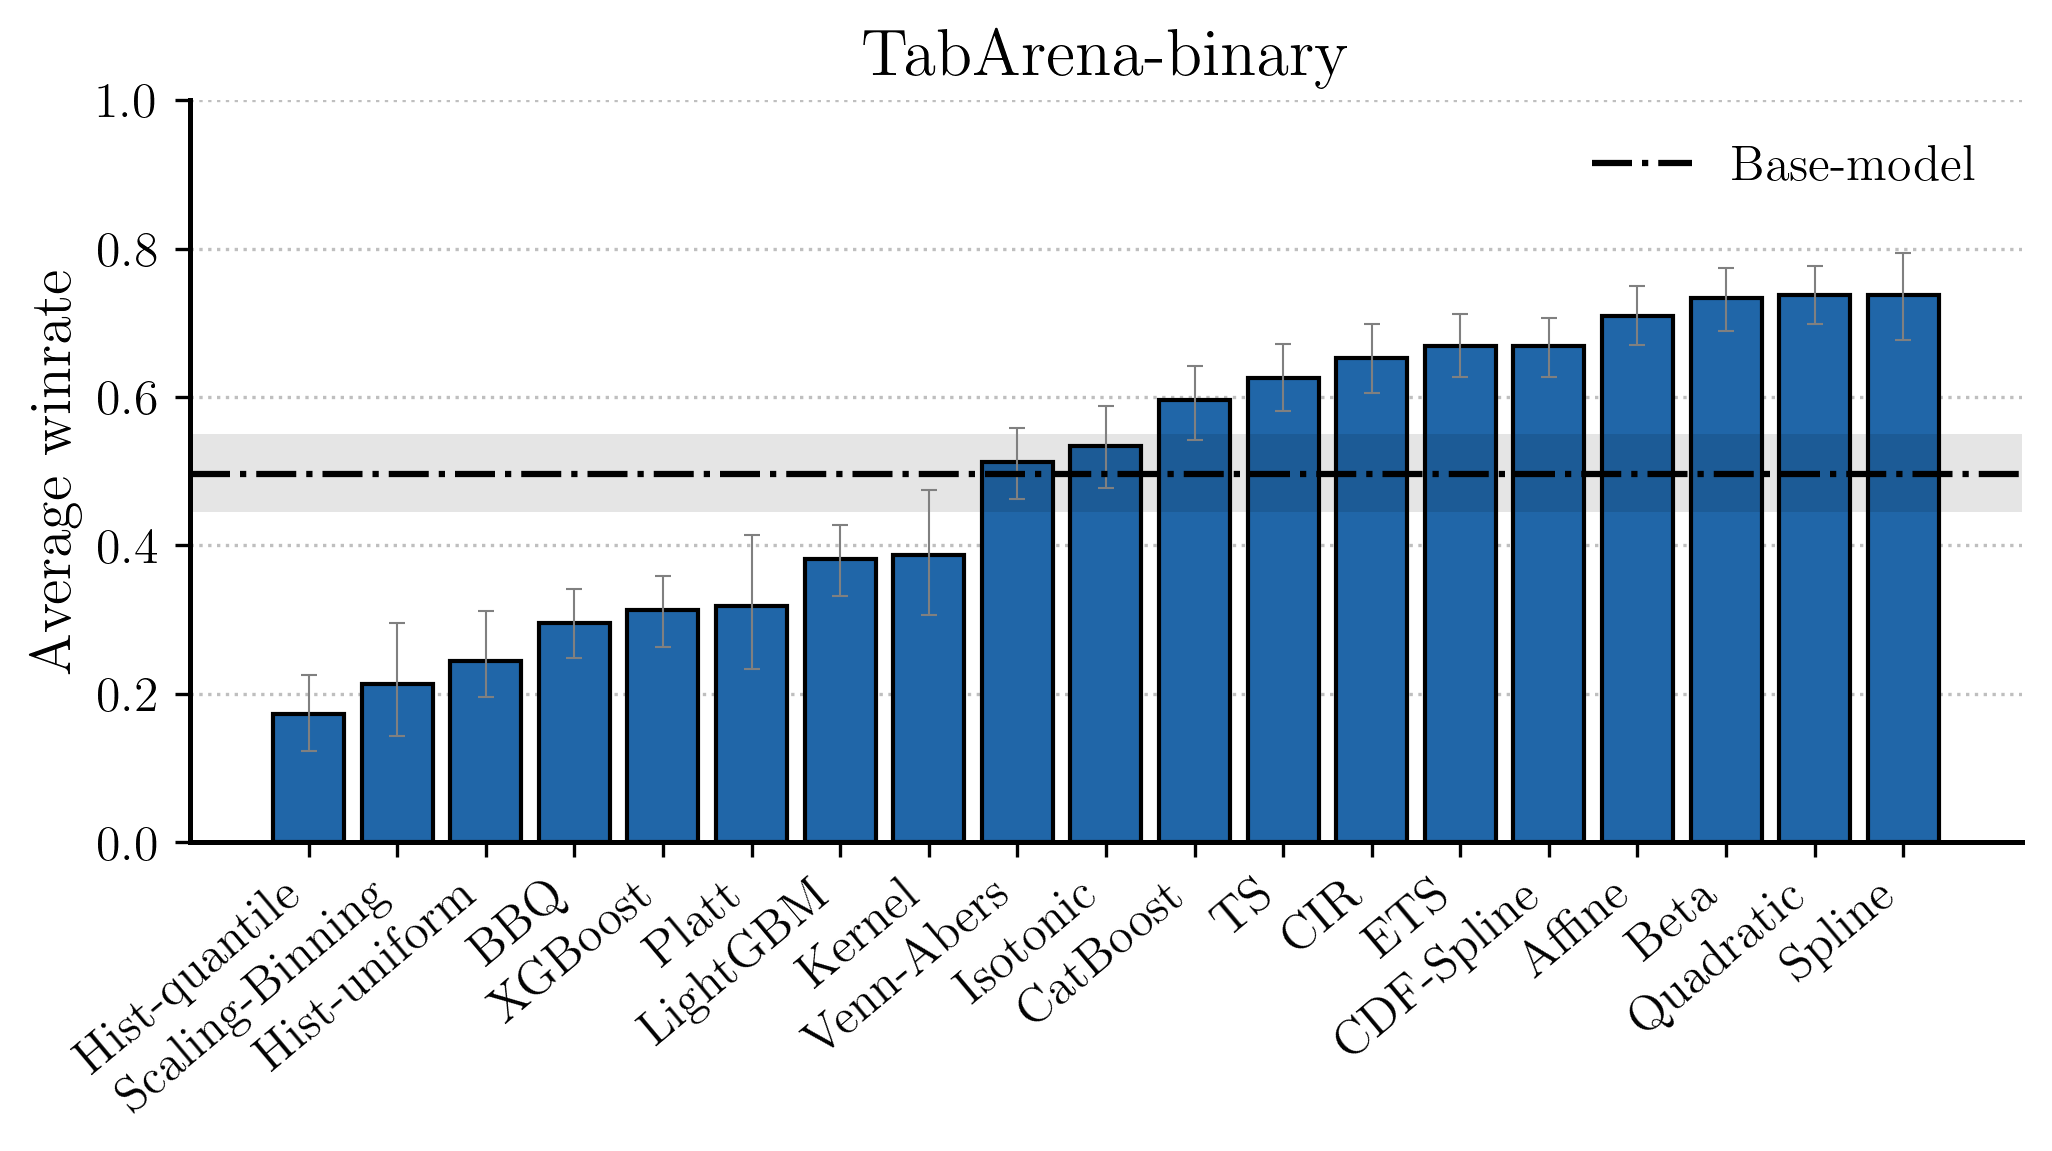

In [9]:
binary_tabarena_winrates = compute_winrates(binary_tabarena_results, binary_methods, metric="brier", bootstrap_datasets=True, n_bootstraps=1000)
plot_leaderboard(
    binary_tabarena_winrates,
    title="TabArena-binary",
    y_label="Average winrate",
    y_lim=(0,1),
    savefile="figures/binary_tabarena_winrates.pdf"
)

Bootstrapping datasets: 100%|██████████| 100/100 [00:34<00:00,  2.87it/s]


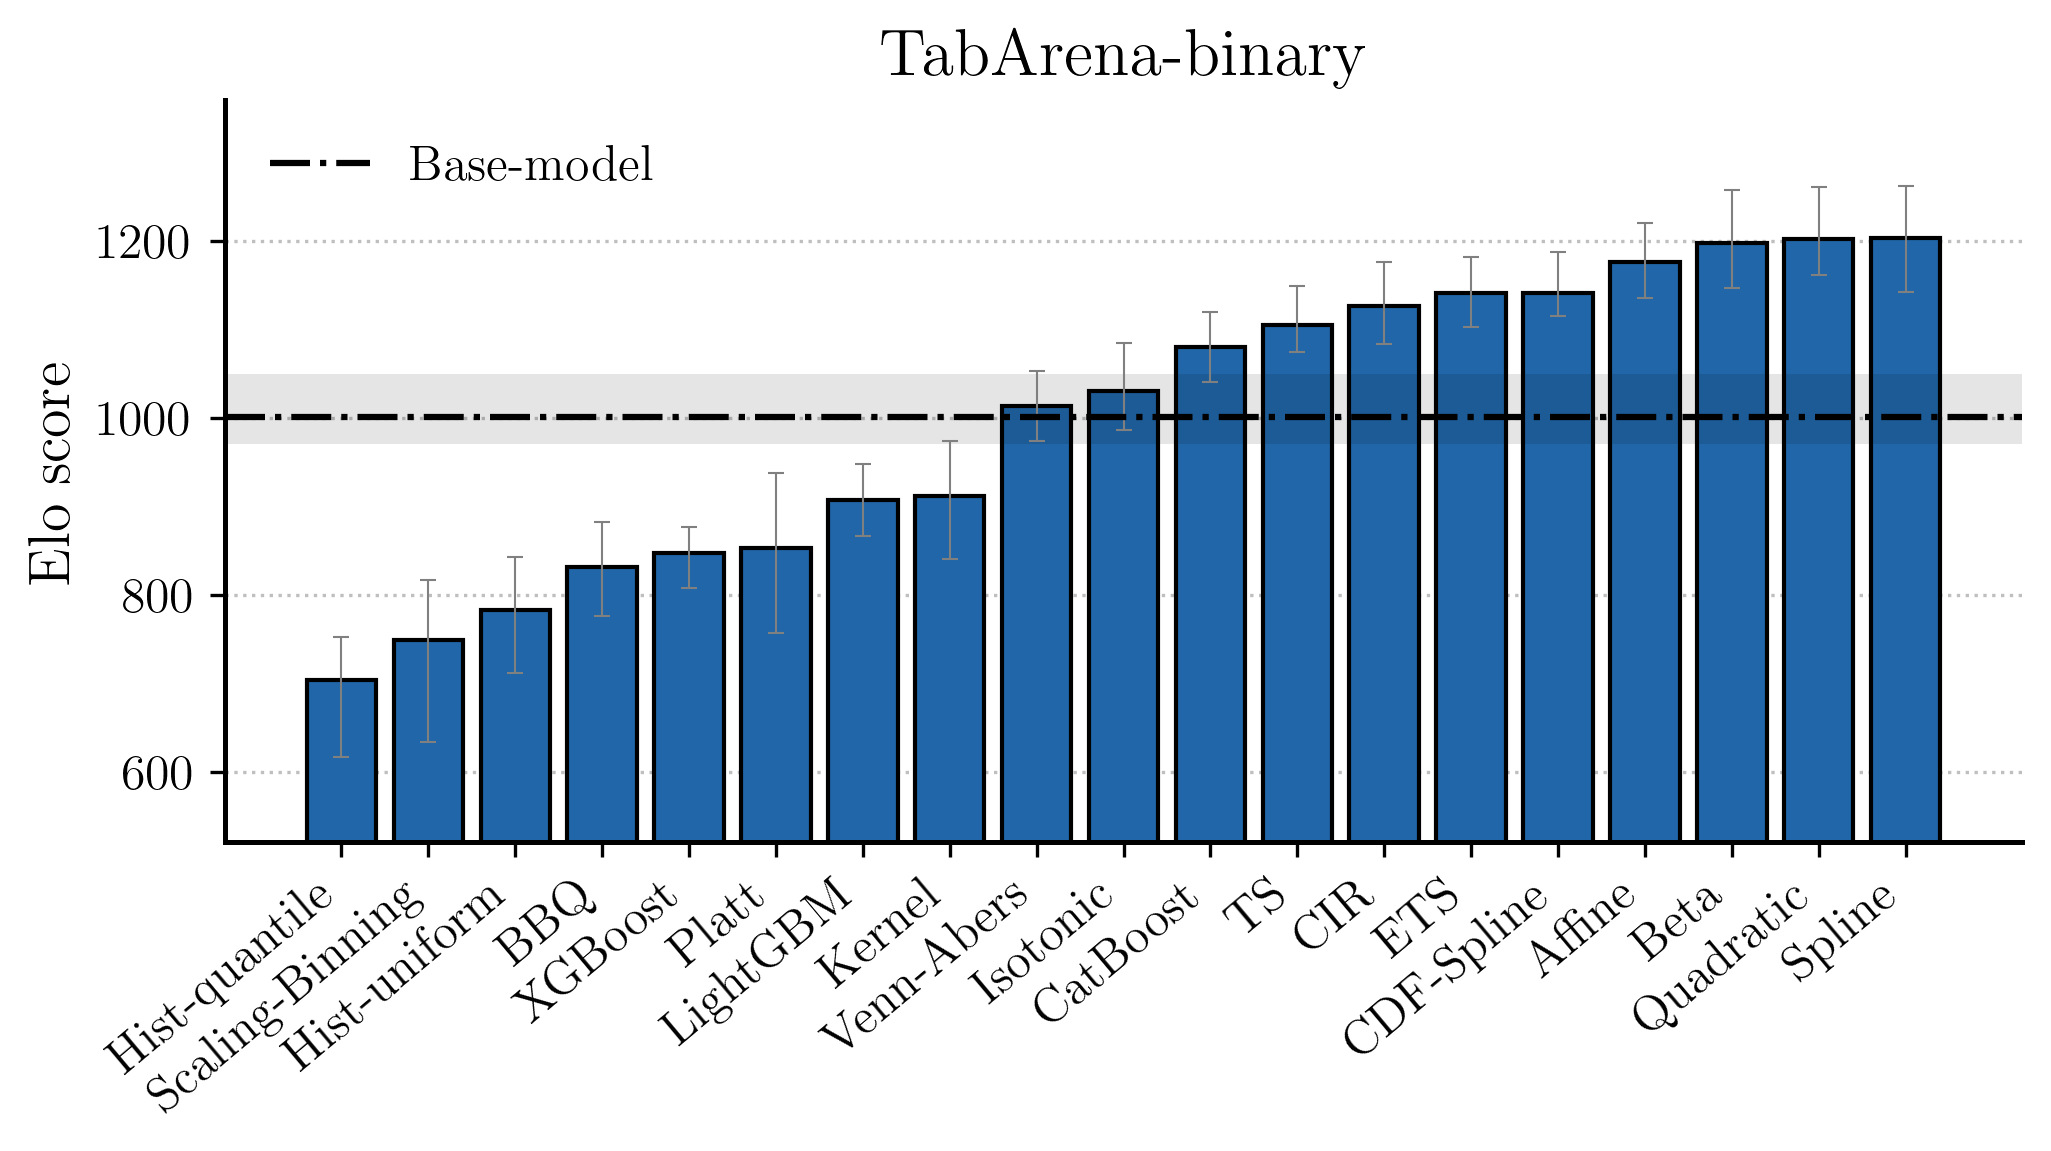

In [10]:
binary_tabarena_elo = compute_elo_scores(binary_tabarena_results, binary_methods, bootstrap_datasets=True, num_bootstrap=100)
plot_leaderboard(
    binary_tabarena_elo,
    title="TabArena-binary",
    y_label="Elo score",
    savefile="figures/binary_tabarena_elo.pdf"
)


Friedman Test Statistic: 2295.189
P-Value: 0.00000e+00
Result: Significant difference found. Proceeding to Nemenyi test.


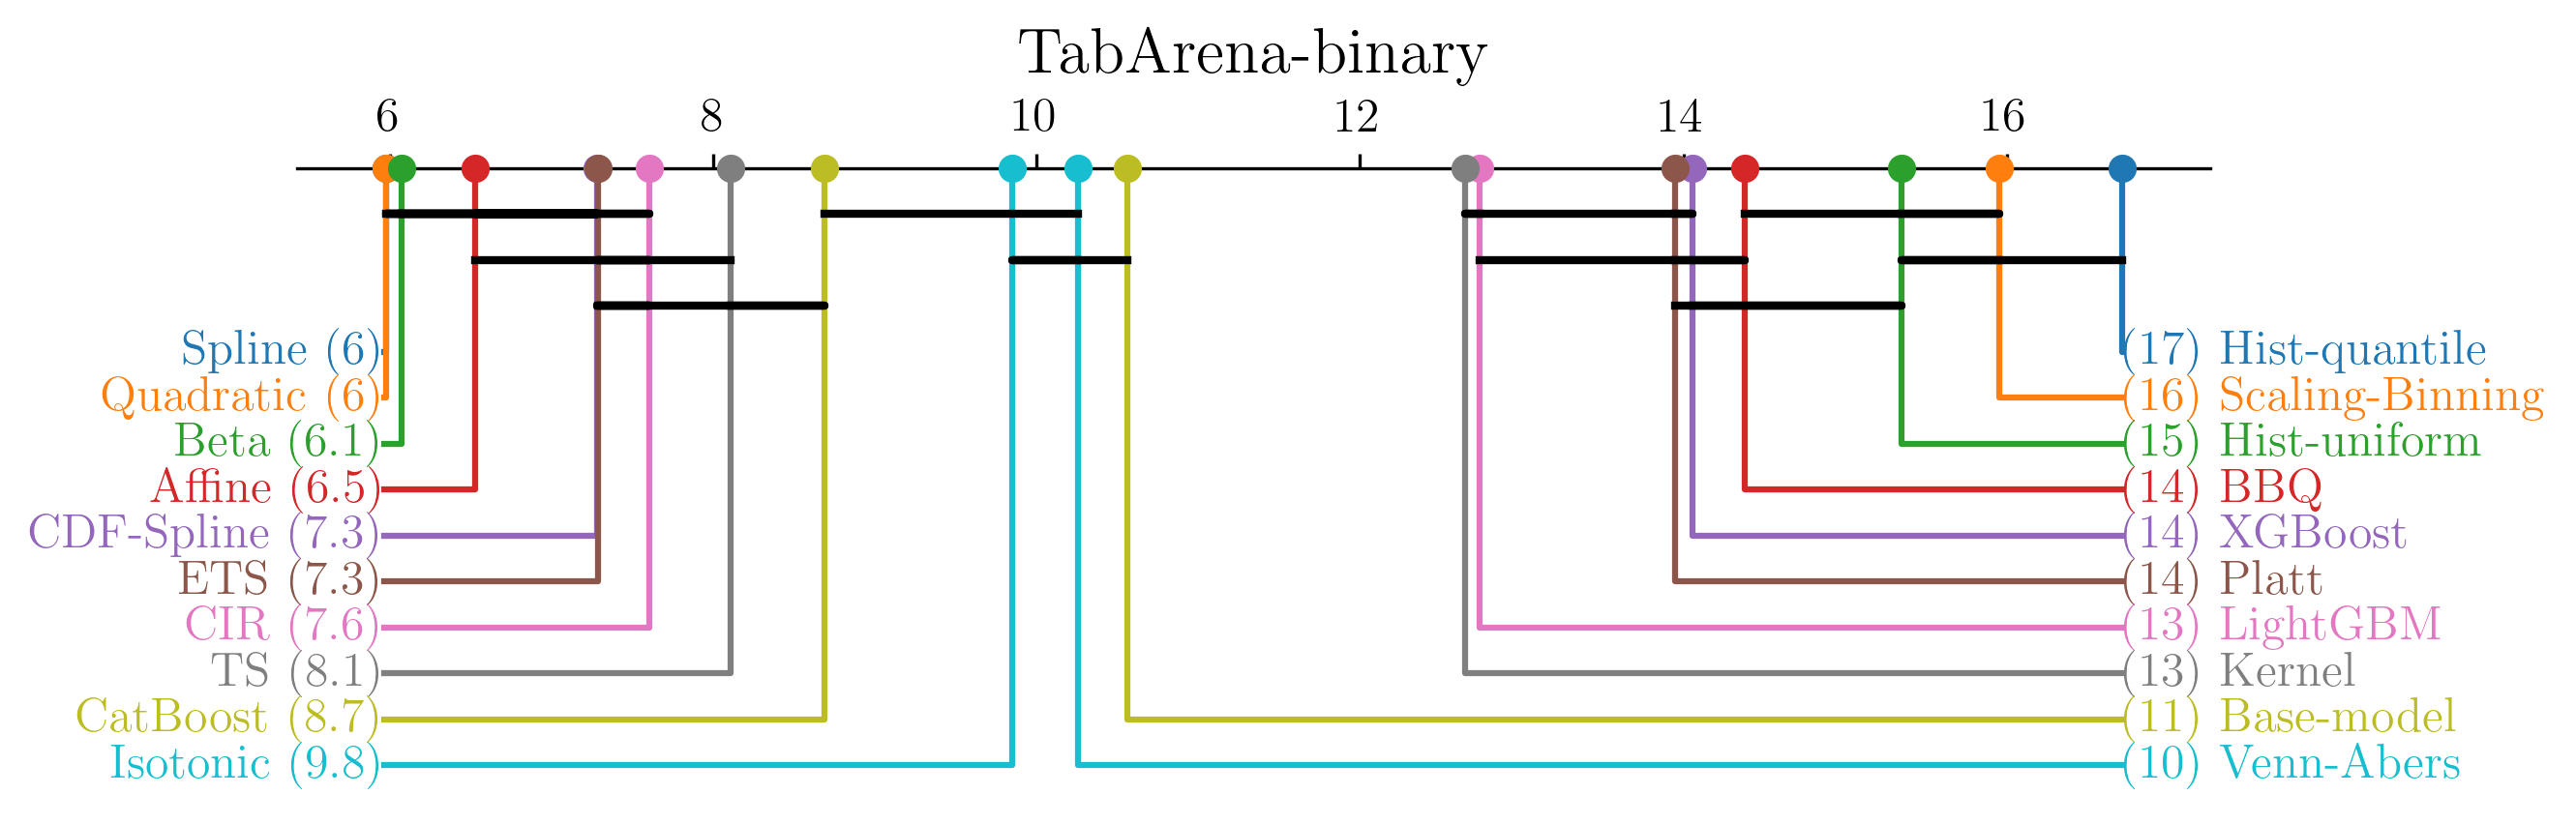

In [11]:
plot_cd_diagram(
    binary_tabarena_results,
    binary_methods,
    metric="brier",
    groupby_dataset=False,
    title="TabArena-binary",
    savefile="figures/binary_tabarena_cd.pdf"
)

In [12]:
binary_tabarena_absolute = compute_absolute_improvements(
    results=binary_tabarena_results,
    methods=binary_methods,
    metrics=binary_metrics,
    use_num_datasets=True,
    precision=2,
    factor=100
)
print(binary_tabarena_absolute.to_latex())

\begin{tabular}{llllll}
\toprule
 & Brier & Logloss & Kuiper & Ece-15 & Accuracy \\
Method &  &  &  &  &  \\
\midrule
Quadratic & $\phantom{-}0.25$ {\tiny $\pm 0.47$} (\#1) & $\phantom{-}1.43$ {\tiny $\pm 2.46$} (\#1) & $\phantom{-}0.83$ {\tiny $\pm 0.77$} (\#1) & $\phantom{-}0.89$ {\tiny $\pm 0.81$} (\#7) & $\phantom{-}0.11$ {\tiny $\pm 0.33$} (\#3) \\
Affine & $\phantom{-}0.25$ {\tiny $\pm 0.48$} (\#2) & $\phantom{-}1.39$ {\tiny $\pm 2.36$} (\#3) & $\phantom{-}0.82$ {\tiny $\pm 0.78$} (\#3) & $\phantom{-}0.85$ {\tiny $\pm 0.80$} (\#11) & $\phantom{-}0.09$ {\tiny $\pm 0.31$} (\#5) \\
Beta & $\phantom{-}0.25$ {\tiny $\pm 0.48$} (\#3) & $\phantom{-}1.43$ {\tiny $\pm 2.48$} (\#2) & $\phantom{-}0.82$ {\tiny $\pm 0.77$} (\#2) & $\phantom{-}0.88$ {\tiny $\pm 0.81$} (\#8) & $\phantom{-}0.11$ {\tiny $\pm 0.33$} (\#1) \\
CDF-Spline & $\phantom{-}0.23$ {\tiny $\pm 0.41$} (\#4) & $\phantom{-}1.18$ {\tiny $\pm 2.22$} (\#9) & $\phantom{-}0.78$ {\tiny $\pm 0.74$} (\#6) & $\phantom{-}0.82$ {\tiny $\

## CV-binary

In [13]:
binary_cv_results = load_benchmark_results(benchmark_name="CV-binary", methods=binary_methods)

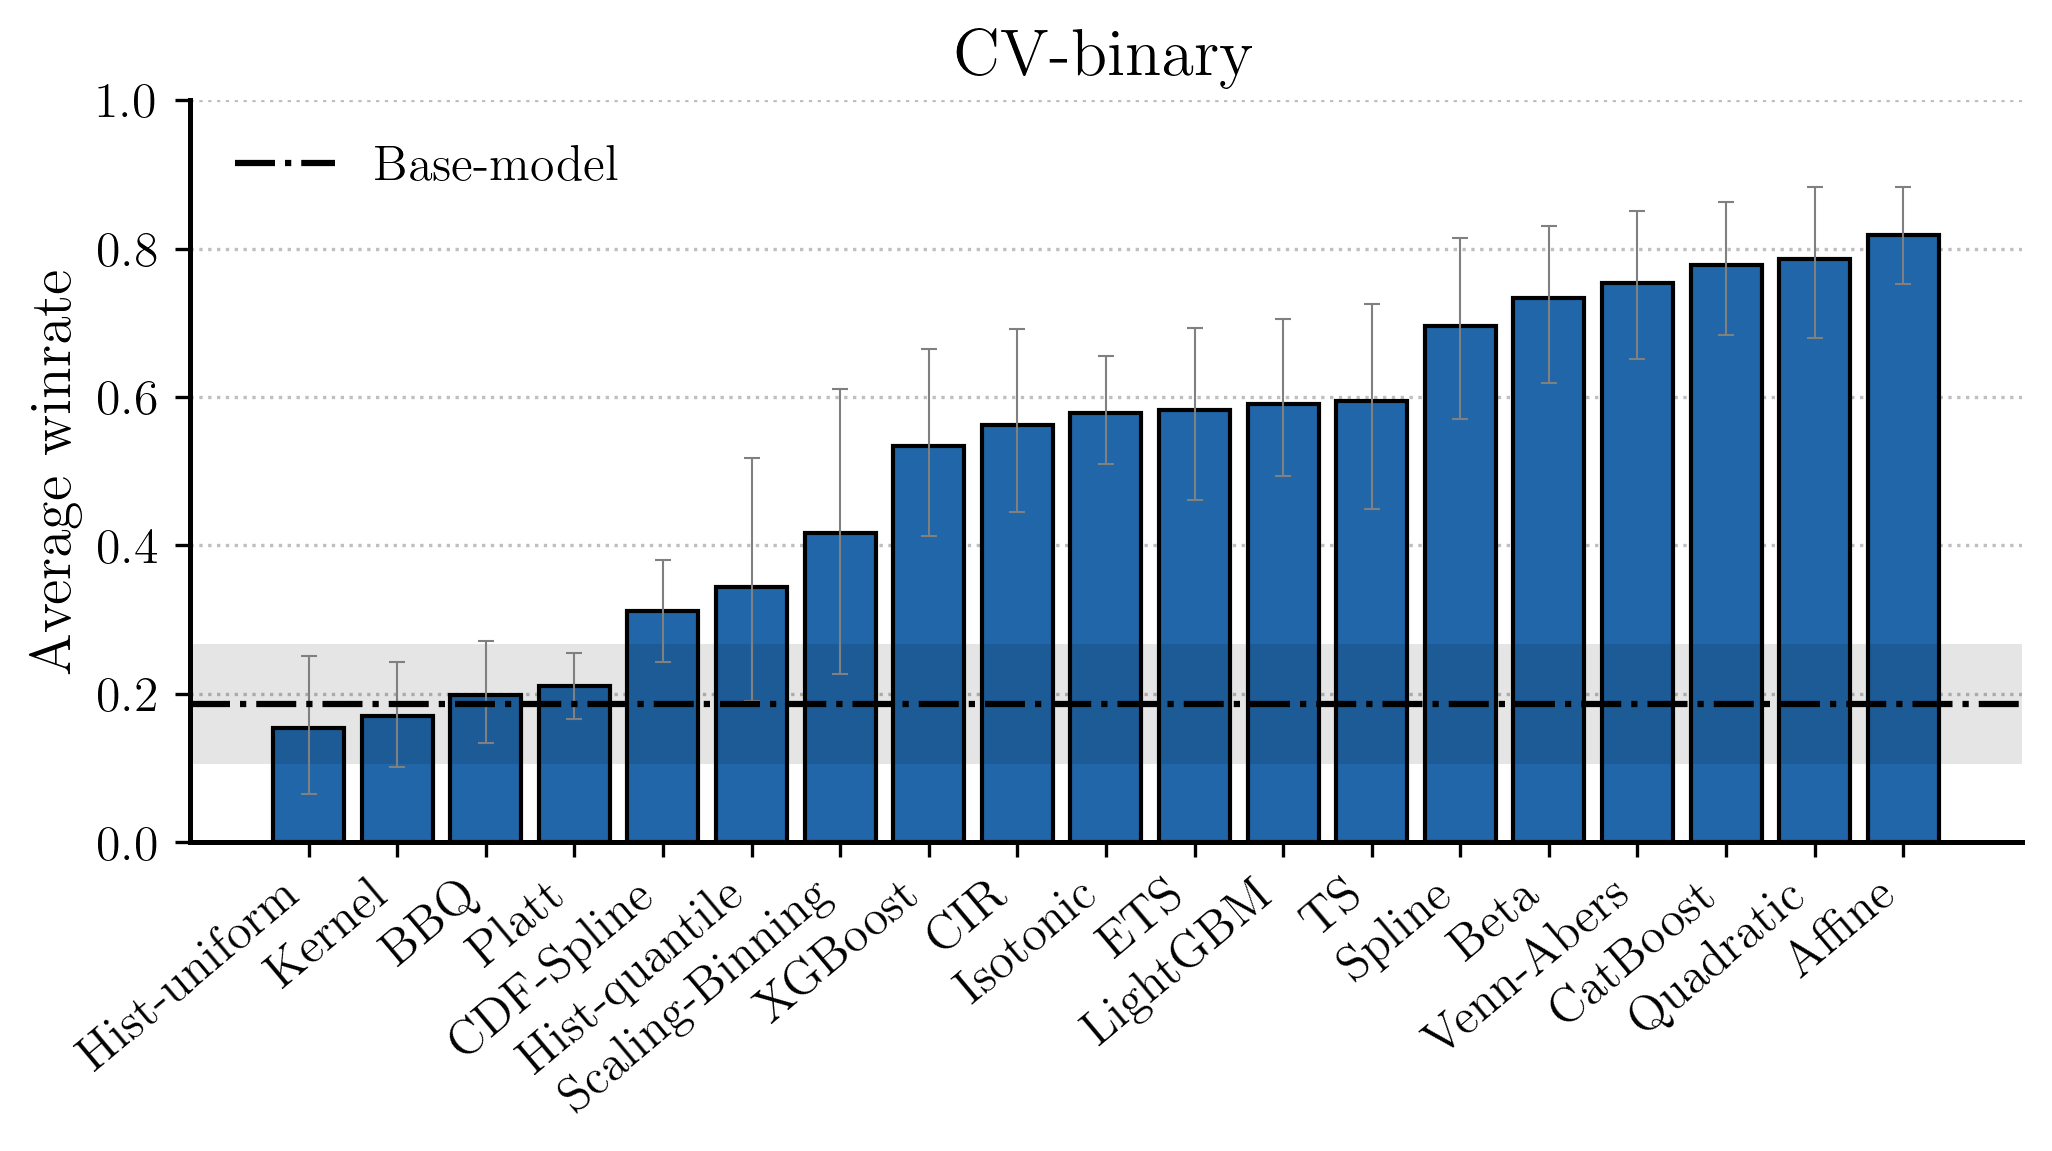

In [14]:
binary_cv_winrates = compute_winrates(binary_cv_results, binary_methods, metric="brier", bootstrap_datasets=False, n_bootstraps=1000)
plot_leaderboard(
    binary_cv_winrates,
    title="CV-binary",
    y_label="Average winrate",
    y_lim=(0,1),
    savefile="figures/binary_cv_winrates.pdf"
)

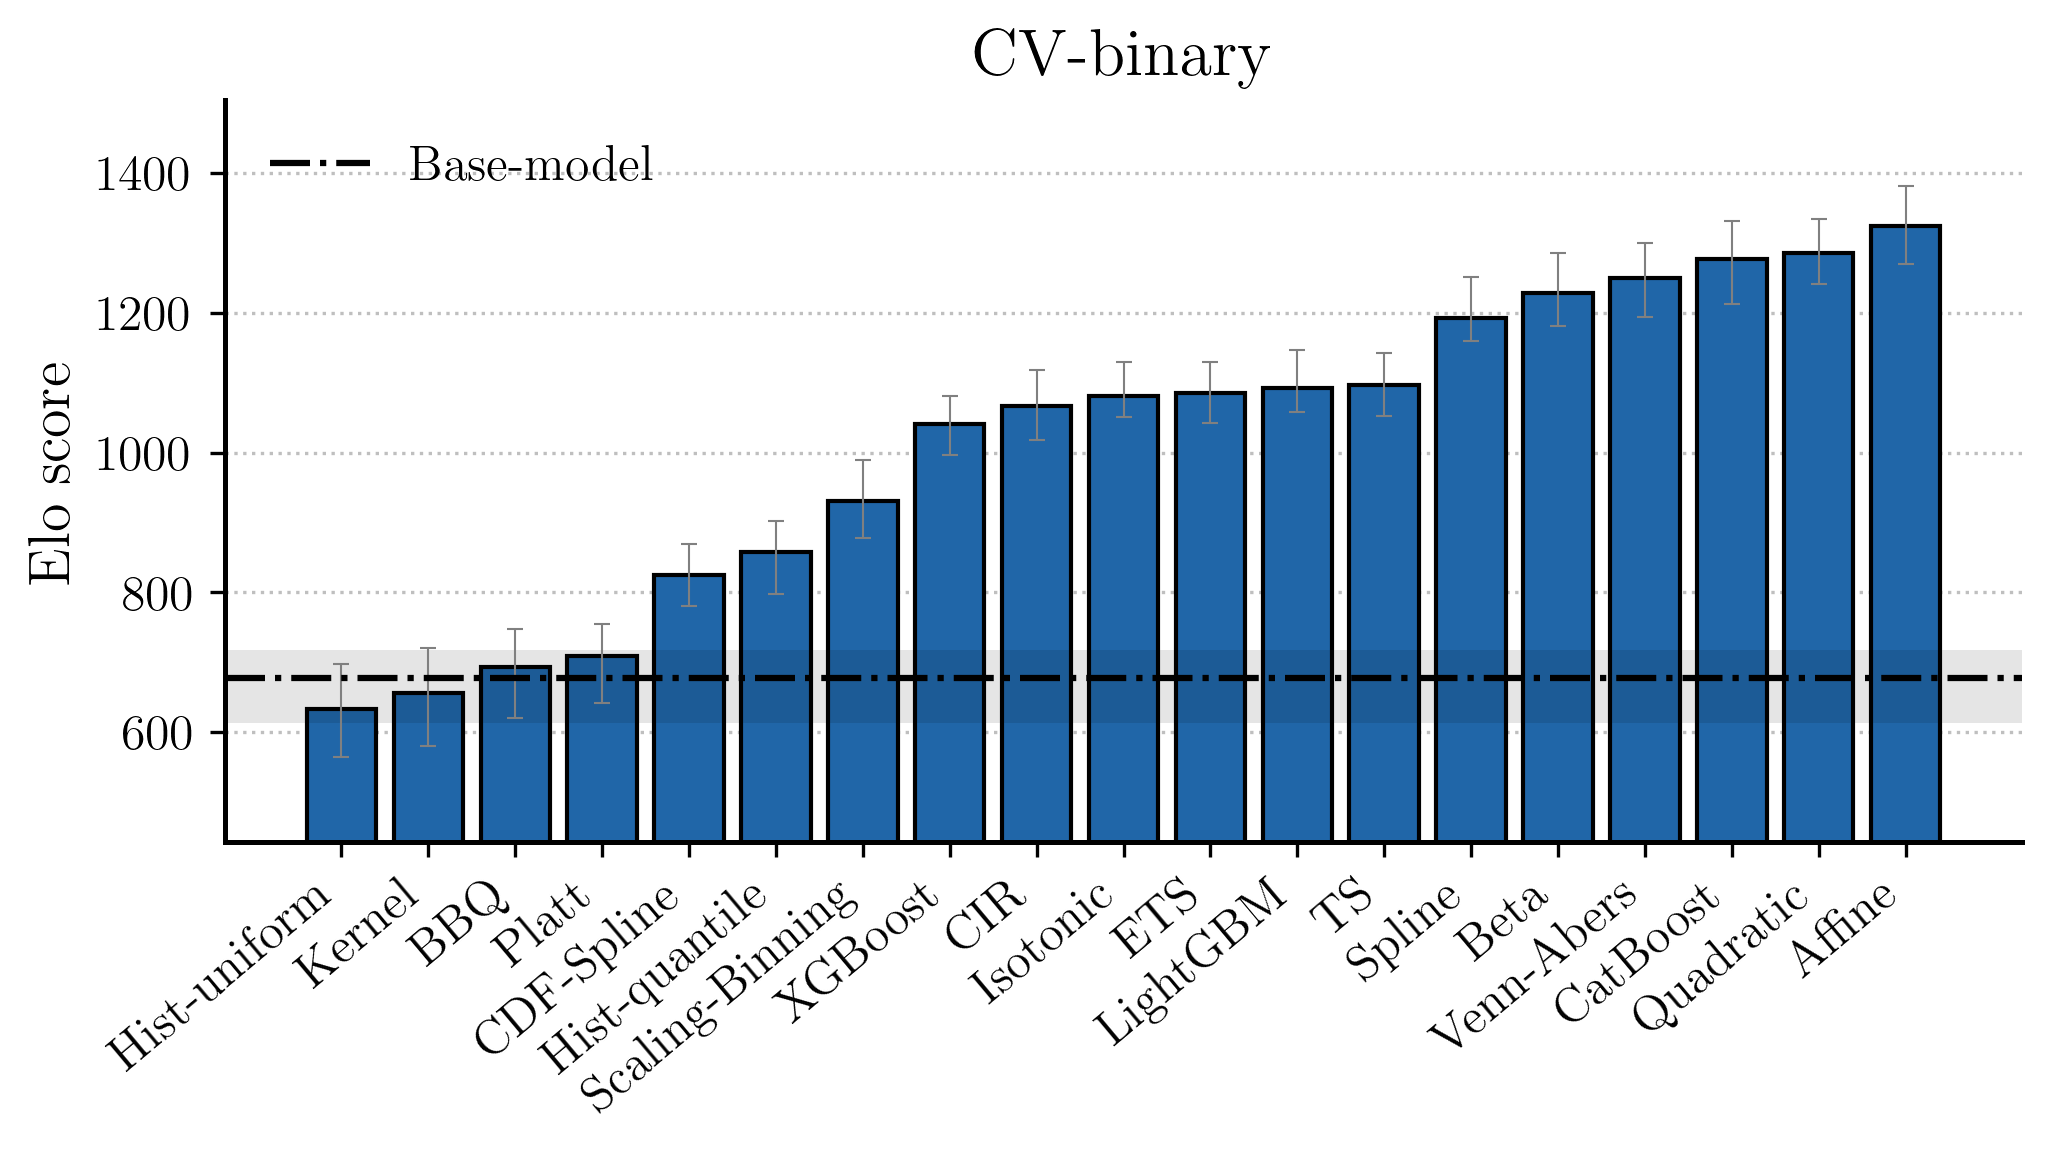

In [15]:
binary_cv_elo = compute_elo_scores(binary_cv_results, binary_methods, bootstrap_datasets=False, num_bootstrap=100)
plot_leaderboard(
    binary_cv_elo,
    title="CV-binary",
    y_label="Elo score",
    savefile="figures/binary_cv_elo.pdf"
)


Friedman Test Statistic: 136.807
P-Value: 7.43025e-20
Result: Significant difference found. Proceeding to Nemenyi test.


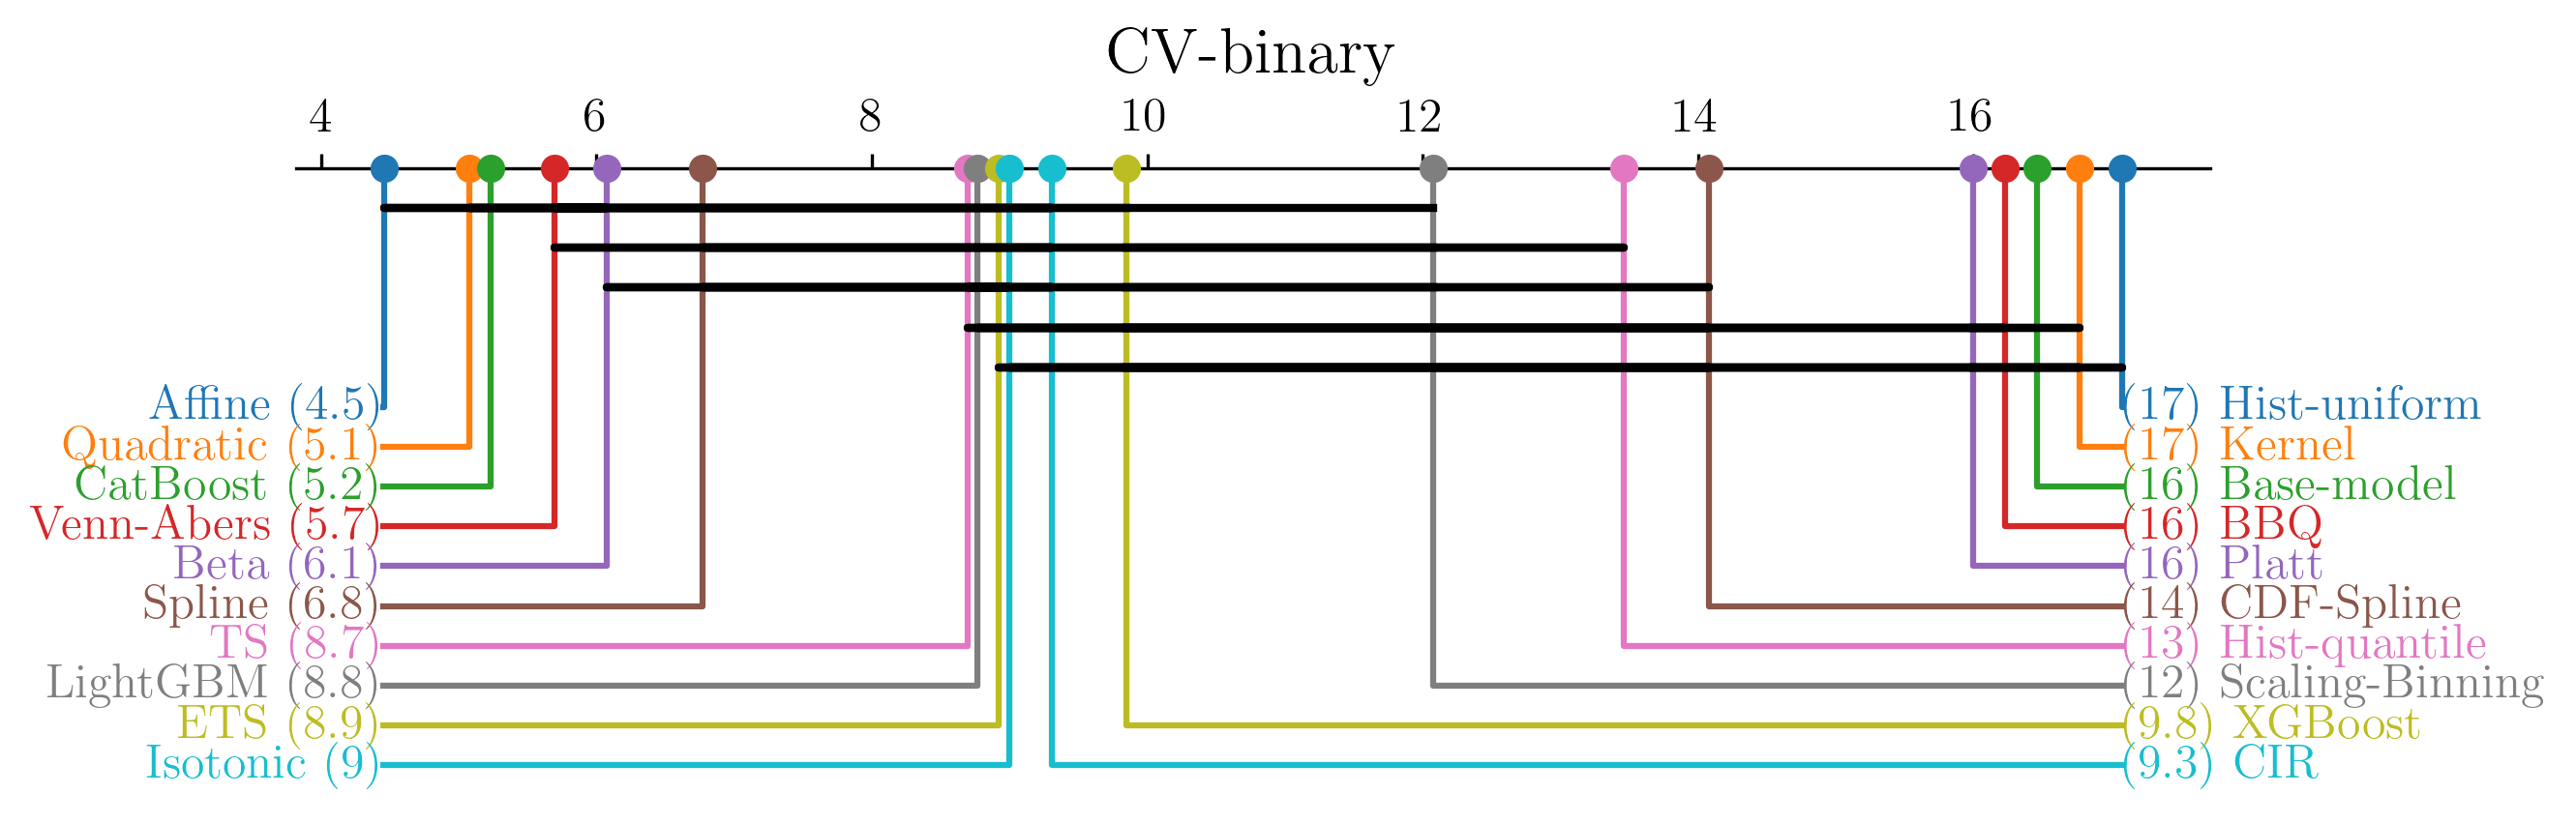

In [16]:
plot_cd_diagram(
    binary_cv_results,
    binary_methods,
    metric="brier",
    groupby_dataset=False,
    title="CV-binary",
    savefile="figures/binary_cv_cd.pdf"
)

In [17]:
binary_cv_absolute = compute_absolute_improvements(
    results=binary_cv_results,
    methods=binary_methods,
    metrics=binary_metrics,
    use_num_datasets=False,
    precision=2,
    factor=100
)
print(binary_cv_absolute.to_latex())

\begin{tabular}{llllll}
\toprule
 & Brier & Logloss & Kuiper & Ece-15 & Accuracy \\
Method &  &  &  &  &  \\
\midrule
Venn-Abers & $\phantom{-}3.48$ {\tiny $\pm 1.65$} (\#1) & $\phantom{-}115.15$ {\tiny $\pm 61.72$} (\#1) & $\phantom{-}2.34$ {\tiny $\pm 1.60$} (\#4) & $\phantom{-}3.02$ {\tiny $\pm 2.25$} (\#9) & $\phantom{-}0.13$ {\tiny $\pm 0.88$} (\#8) \\
Affine & $\phantom{-}3.39$ {\tiny $\pm 1.53$} (\#2) & $\phantom{-}102.37$ {\tiny $\pm 56.64$} (\#10) & $\phantom{-}2.40$ {\tiny $\pm 1.42$} (\#2) & $\phantom{-}2.77$ {\tiny $\pm 1.82$} (\#13) & $\phantom{-}0.30$ {\tiny $\pm 0.38$} (\#4) \\
CatBoost & $\phantom{-}3.28$ {\tiny $\pm 1.53$} (\#3) & $\phantom{-}114.09$ {\tiny $\pm 61.34$} (\#3) & $\phantom{-}2.34$ {\tiny $\pm 1.35$} (\#5) & $\phantom{-}3.37$ {\tiny $\pm 2.37$} (\#5) & $-0.18$ {\tiny $\pm 1.05$} (\#19) \\
Quadratic & $\phantom{-}3.21$ {\tiny $\pm 1.46$} (\#4) & $\phantom{-}97.11$ {\tiny $\pm 59.64$} (\#12) & $\phantom{-}2.32$ {\tiny $\pm 1.44$} (\#7) & $\phantom{-}2.85$ {

# Multiclass benchmarks

In [18]:
multiclass_methods = [
    "Base-model",
    "Hist-uniform",
    "Hist-quantile",
    "Isotonic",
    "CIR",
    "Venn-Abers",
    "BBQ",
    "Spline",
    "TS",
    "ETS",
    "VS",
    "SVS",
    "MS",
    "SMS",
    "Dirichlet",
    "Kernel",
    "LightGBM",
    "XGBoost",
]

multiclass_metrics = {
    "brier": "min",
    "logloss": "min",
    "ece-15": "min",
    "accuracy": "max",
}

## TabRepo-multiclass

In [19]:
multiclass_tabrepo_results = load_benchmark_results(benchmark_name="TabRepo-multiclass", methods=multiclass_methods)

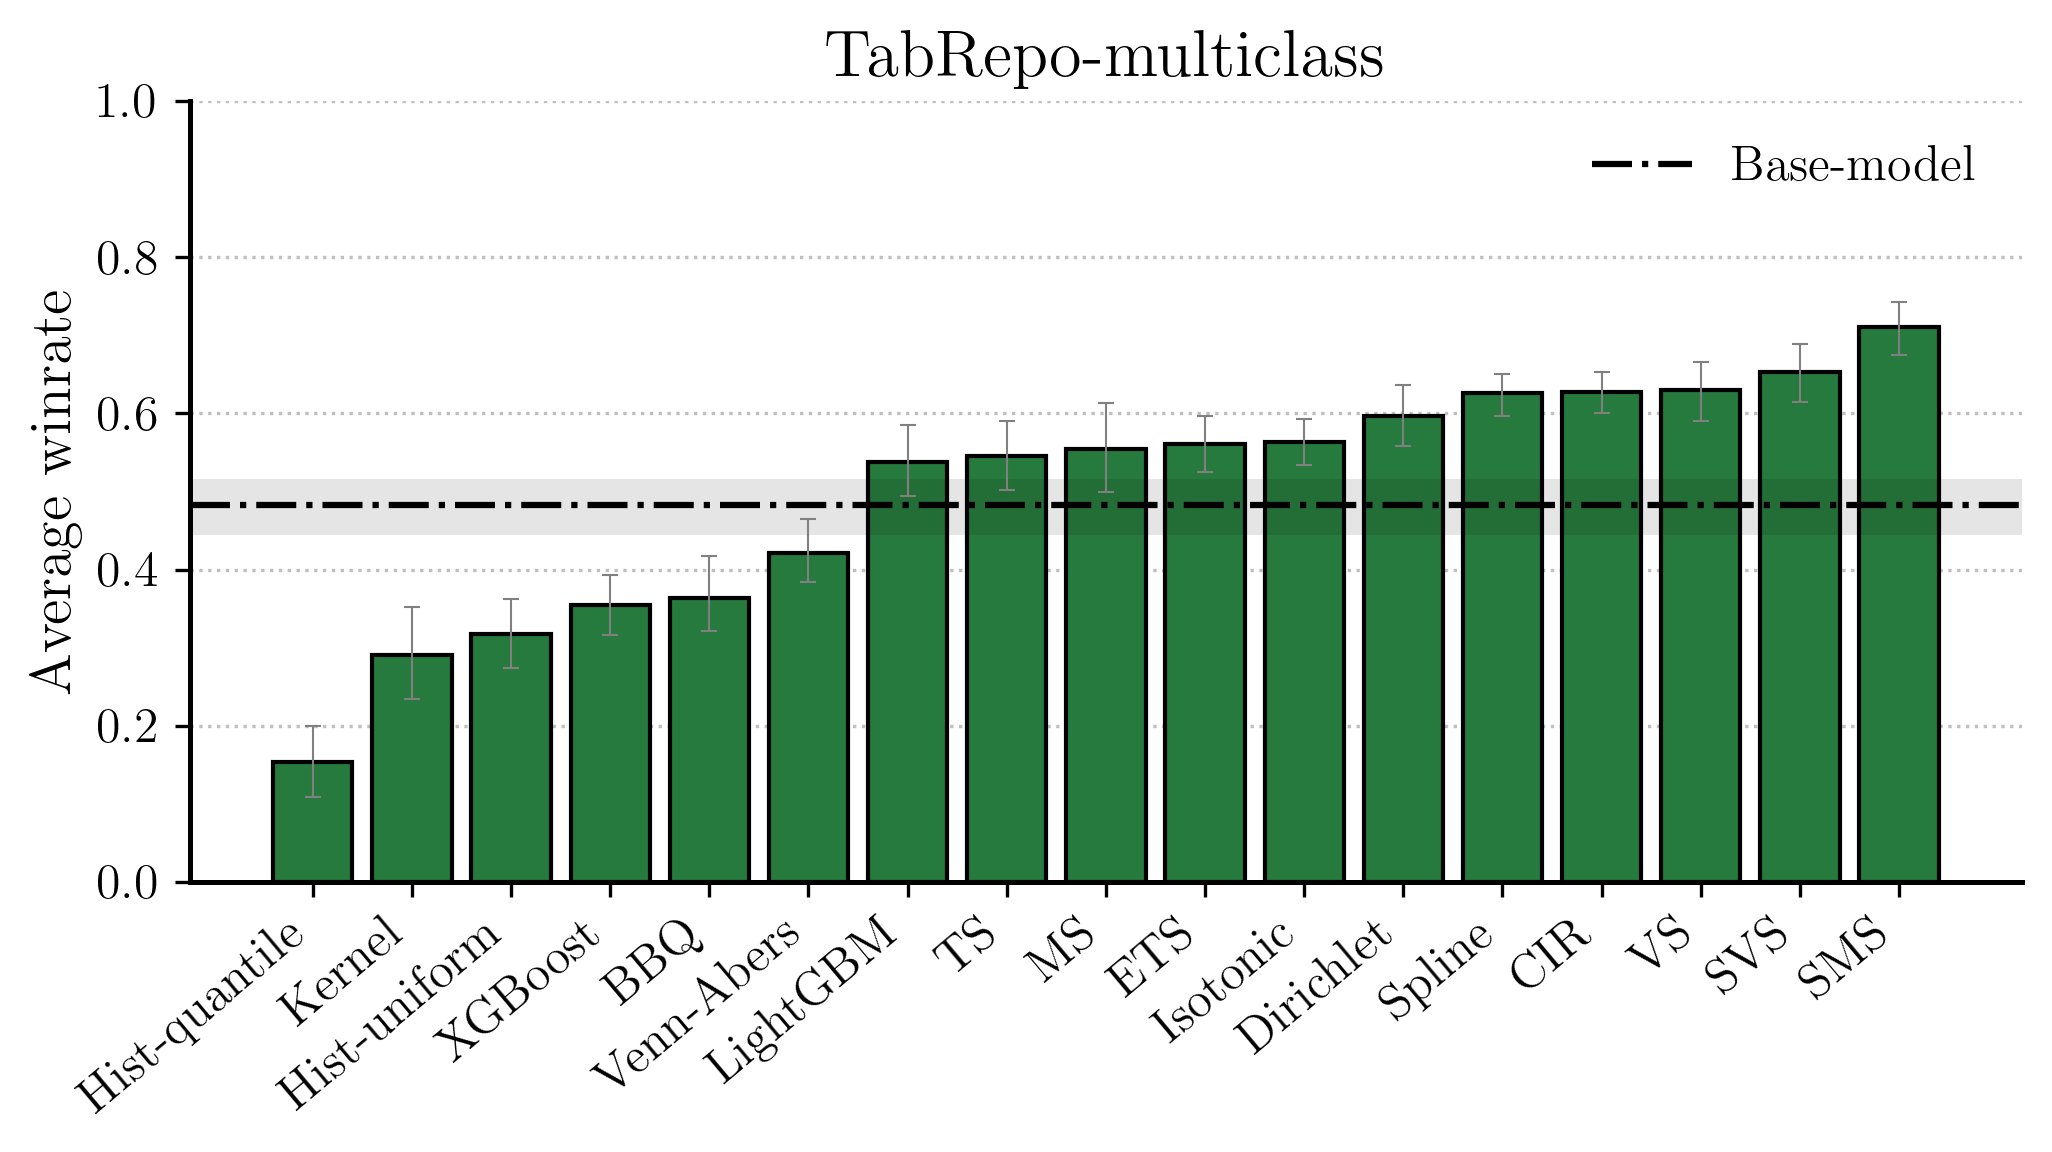

In [20]:
multiclass_tabrepo_winrates = compute_winrates(multiclass_tabrepo_results, multiclass_methods, metric="brier", bootstrap_datasets=True, n_bootstraps=1000)
plot_leaderboard(
    multiclass_tabrepo_winrates,
    title="TabRepo-multiclass",
    y_label="Average winrate",
    y_lim=(0,1),
    color="green",
    savefile="figures/multiclass_tabrepo_winrates.pdf"
)

Bootstrapping datasets: 100%|██████████| 100/100 [00:34<00:00,  2.94it/s]


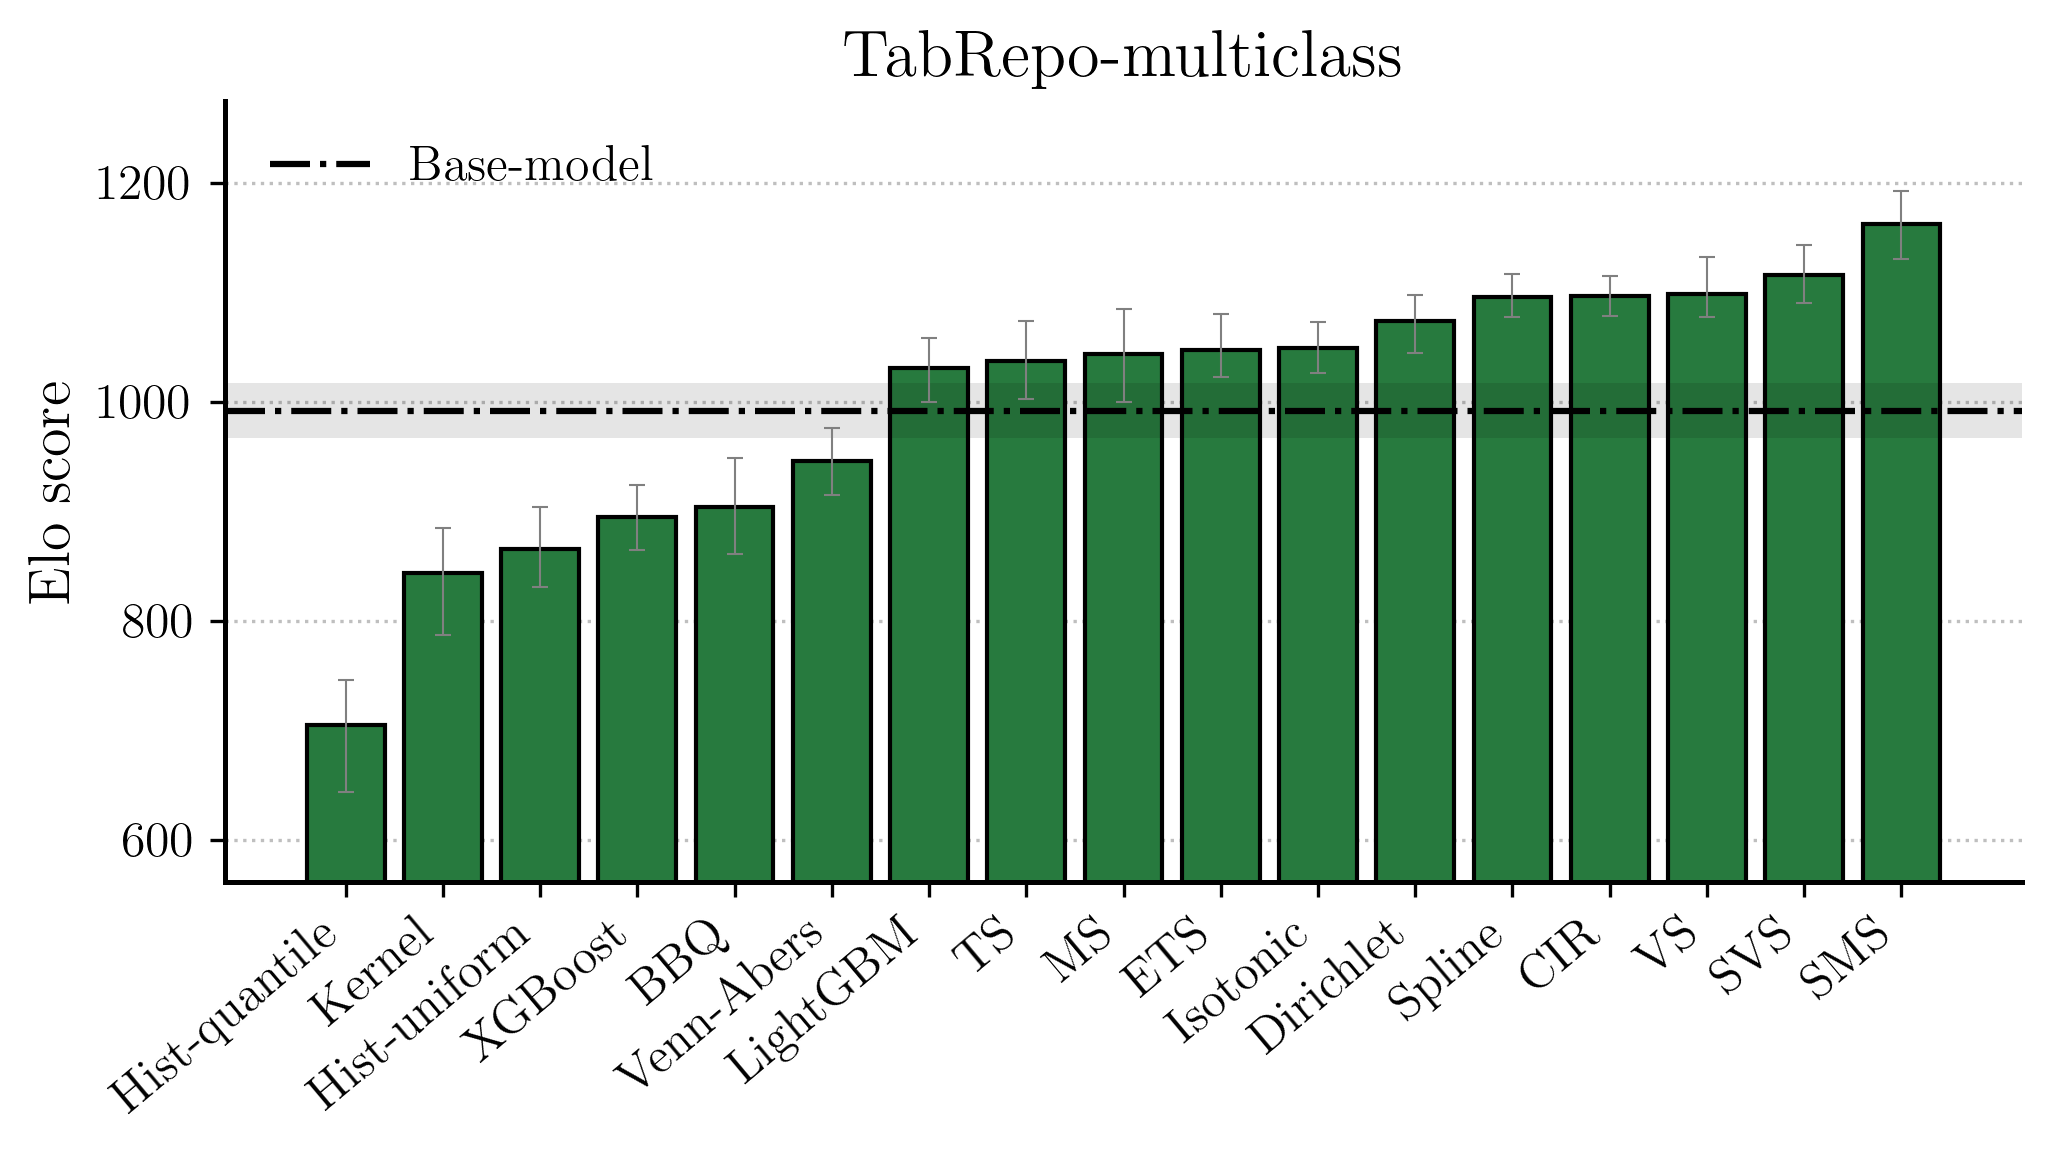

In [21]:
multiclass_tabrepo_elo = compute_elo_scores(multiclass_tabrepo_results, multiclass_methods, bootstrap_datasets=True, num_bootstrap=100)
plot_leaderboard(
    multiclass_tabrepo_elo,
    title="TabRepo-multiclass",
    y_label="Elo score",
    color="green",
    savefile="figures/multiclass_tabrepo_elo.pdf"
)


Friedman Test Statistic: 2022.787
P-Value: 0.00000e+00
Result: Significant difference found. Proceeding to Nemenyi test.


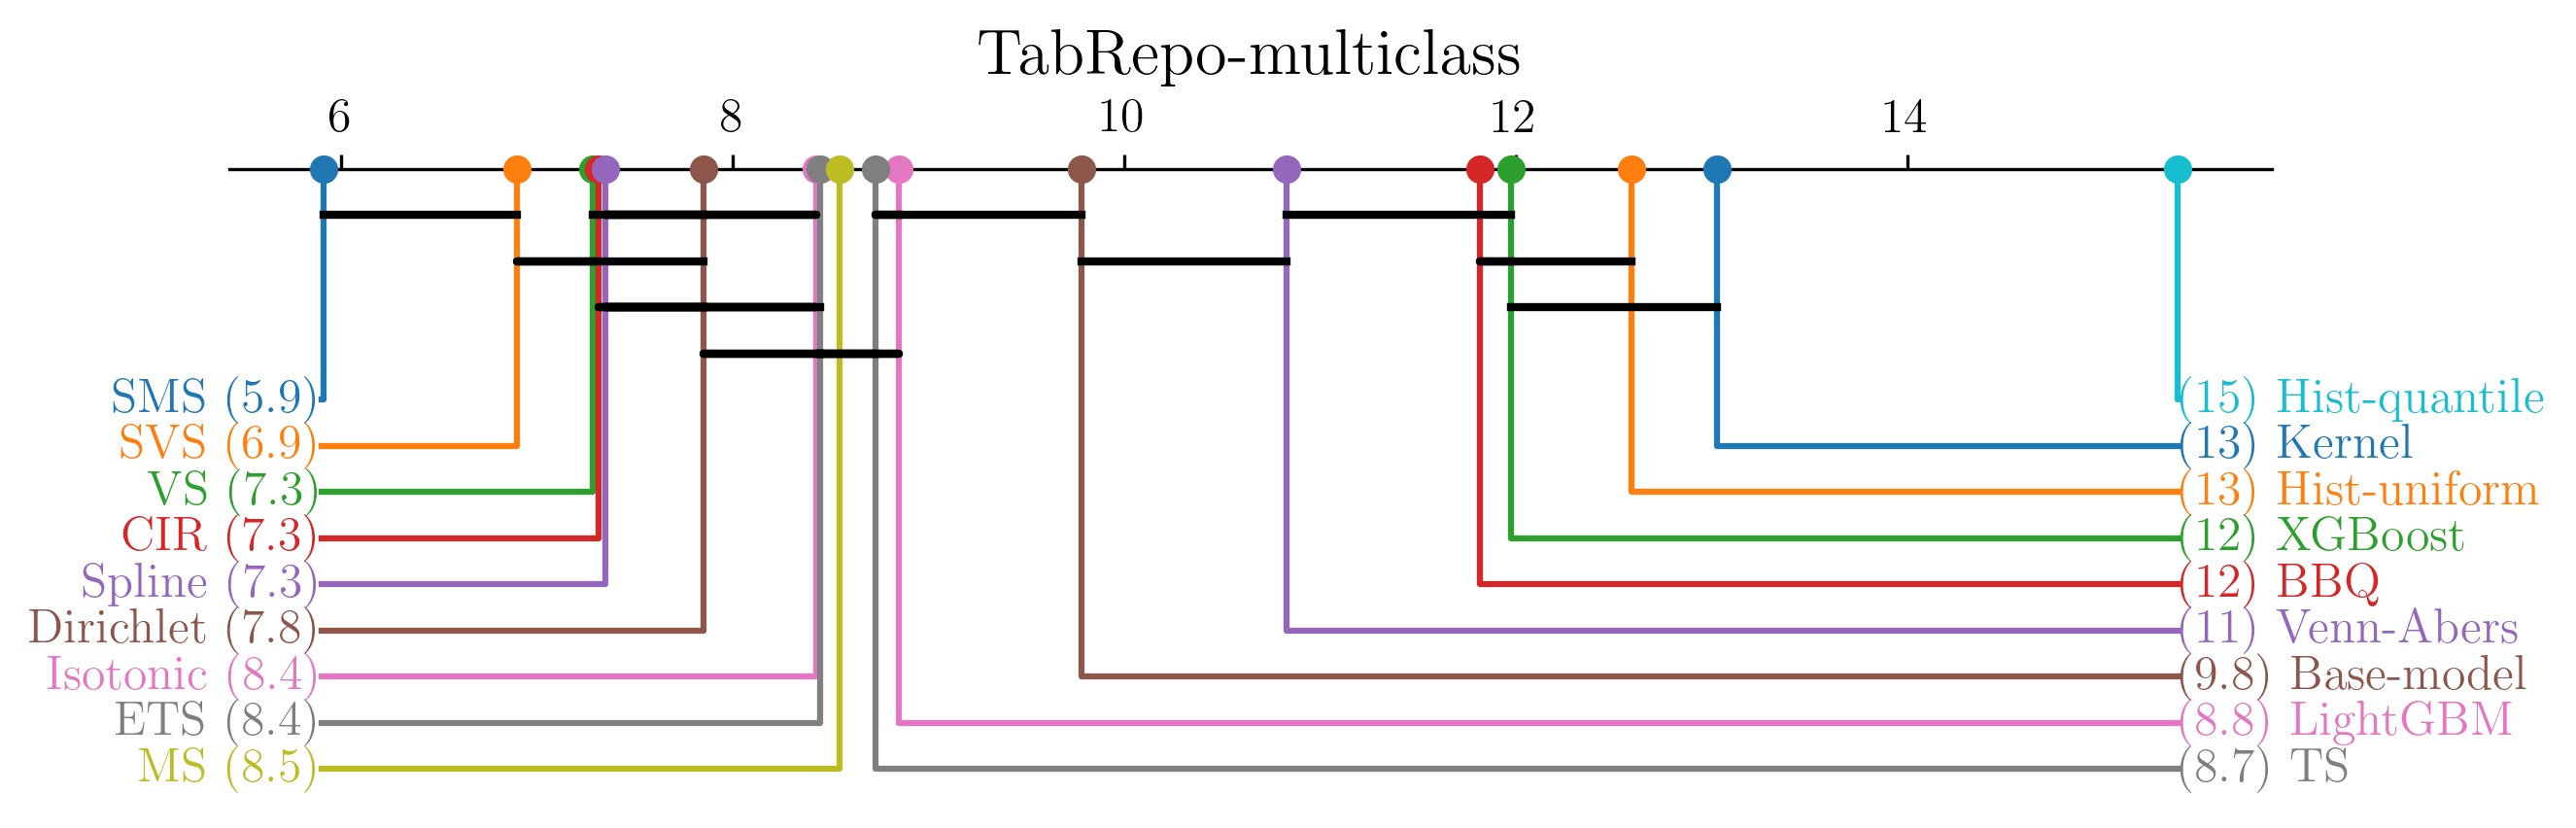

In [22]:
plot_cd_diagram(
    multiclass_tabrepo_results,
    multiclass_methods,
    metric="brier",
    groupby_dataset=False,
    title="TabRepo-multiclass",
    savefile="figures/multiclass_tabrepo_cd.pdf"
)

In [23]:
multiclass_tabrepo_absolute = compute_absolute_improvements(
    results=multiclass_tabrepo_results,
    methods=multiclass_methods,
    metrics=multiclass_metrics,
    use_num_datasets=True,
    precision=2,
    factor=100
)
print(multiclass_tabrepo_absolute.to_latex())

\begin{tabular}{lllll}
\toprule
 & Brier & Logloss & Ece-15 & Accuracy \\
Method &  &  &  &  \\
\midrule
SMS & $\phantom{-}0.63$ {\tiny $\pm 0.39$} (\#1) & $\phantom{-}2.16$ {\tiny $\pm 2.01$} (\#1) & $\phantom{-}1.25$ {\tiny $\pm 0.90$} (\#5) & $\phantom{-}0.16$ {\tiny $\pm 0.27$} (\#3) \\
SVS & $\phantom{-}0.52$ {\tiny $\pm 0.35$} (\#2) & $\phantom{-}1.81$ {\tiny $\pm 1.90$} (\#2) & $\phantom{-}1.15$ {\tiny $\pm 0.88$} (\#8) & $\phantom{-}0.01$ {\tiny $\pm 0.19$} (\#8) \\
Spline & $\phantom{-}0.52$ {\tiny $\pm 0.35$} (\#3) & $\phantom{-}1.62$ {\tiny $\pm 1.88$} (\#3) & $\phantom{-}1.13$ {\tiny $\pm 0.84$} (\#10) & $\phantom{-}0.21$ {\tiny $\pm 0.28$} (\#1) \\
CIR & $\phantom{-}0.51$ {\tiny $\pm 0.35$} (\#4) & $-10.34$ {\tiny $\pm 8.10$} (\#15) & $\phantom{-}1.29$ {\tiny $\pm 0.89$} (\#3) & $\phantom{-}0.17$ {\tiny $\pm 0.28$} (\#2) \\
VS & $\phantom{-}0.50$ {\tiny $\pm 0.37$} (\#5) & $\phantom{-}0.59$ {\tiny $\pm 3.13$} (\#7) & $\phantom{-}1.14$ {\tiny $\pm 0.89$} (\#9) & $\phantom{-

## TabArena-multiclass

In [24]:
multiclass_tabarena_results = load_benchmark_results(benchmark_name="TabArena-multiclass", methods=multiclass_methods)

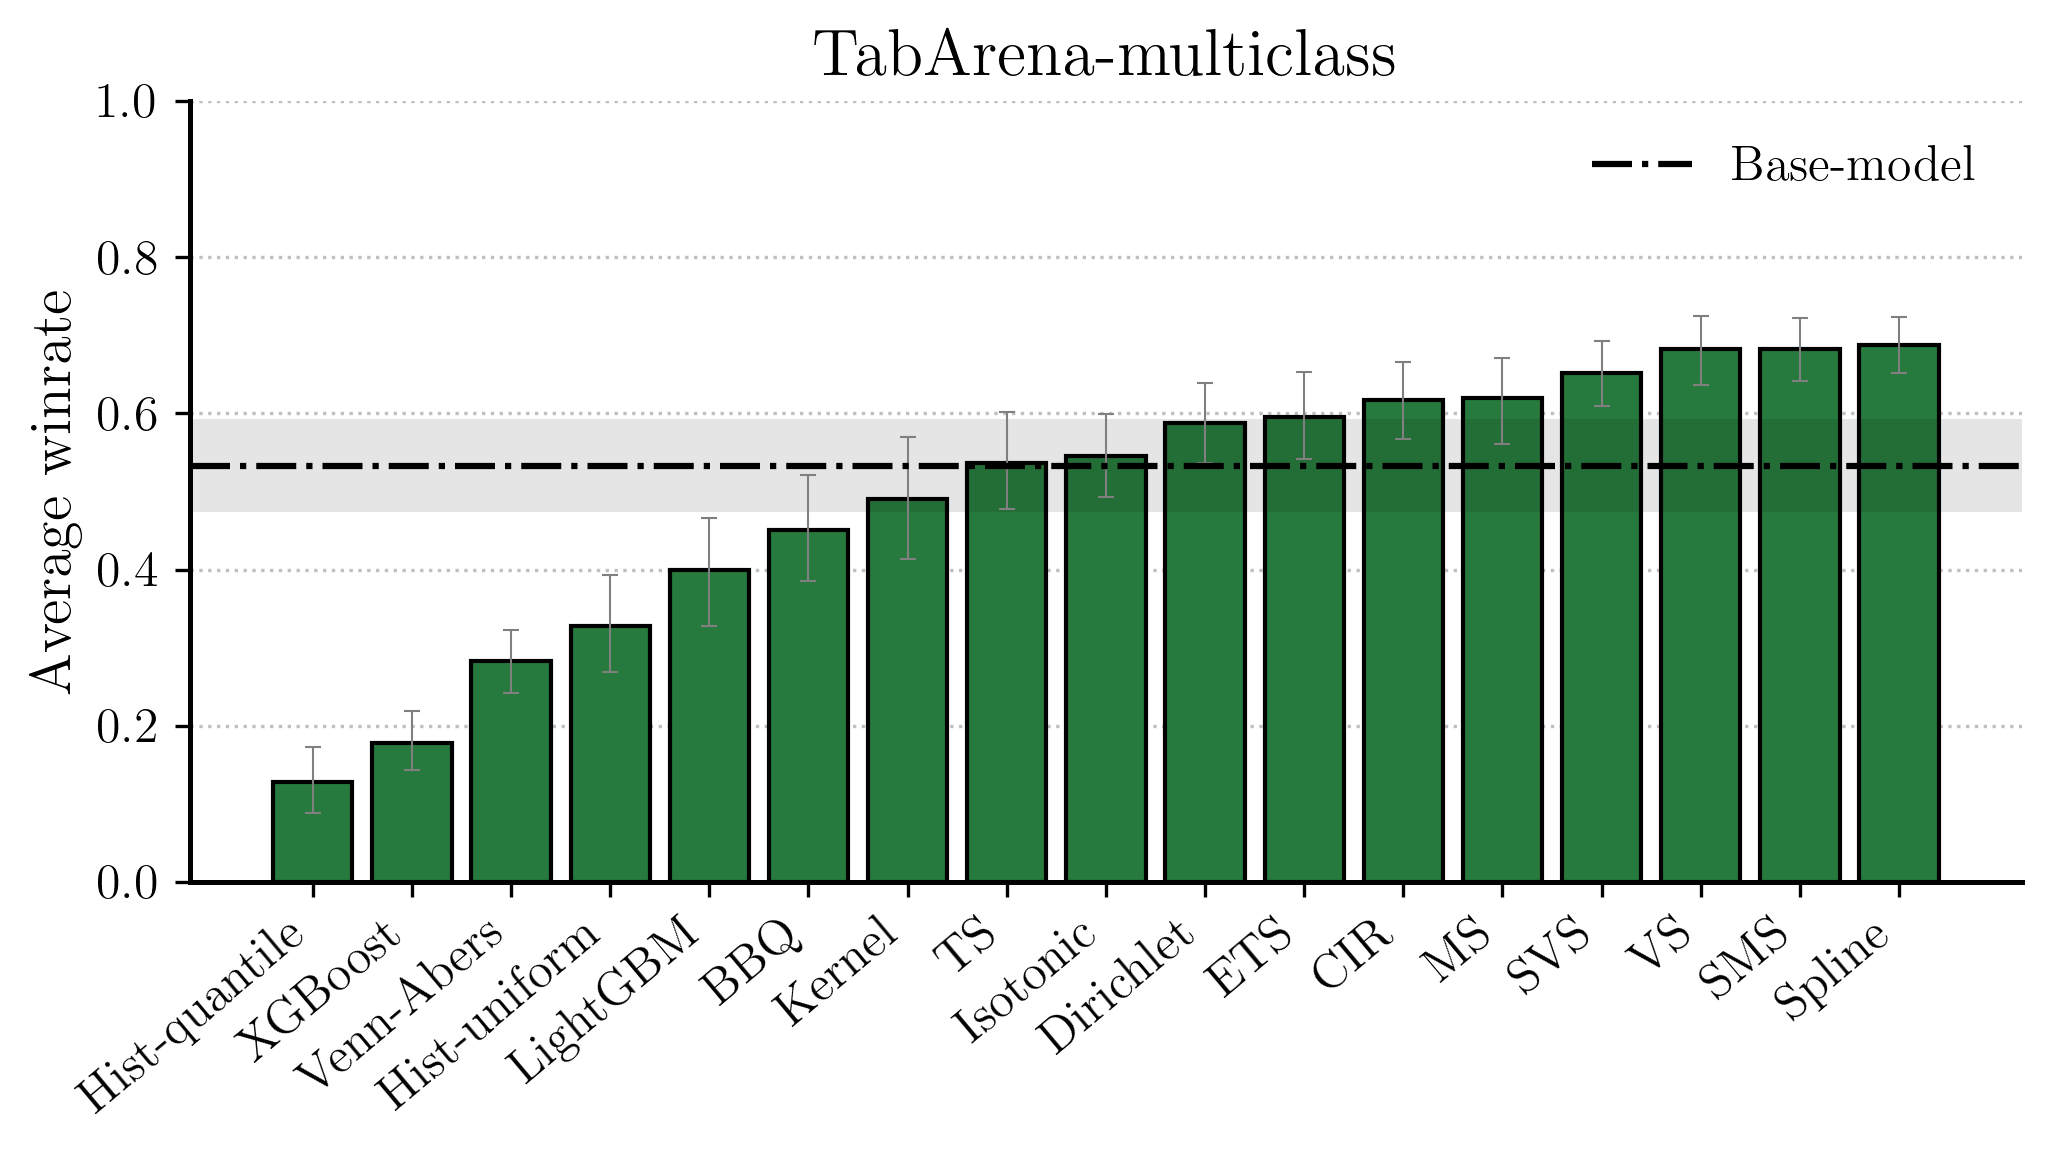

In [25]:
multiclass_tabarena_winrates = compute_winrates(multiclass_tabarena_results, multiclass_methods, metric="brier", bootstrap_datasets=False, n_bootstraps=1000)
plot_leaderboard(
    multiclass_tabarena_winrates,
    title="TabArena-multiclass",
    y_label="Average winrate",
    y_lim=(0,1),
    color="green",
    savefile="figures/multiclass_tabarena_winrates.pdf"
)

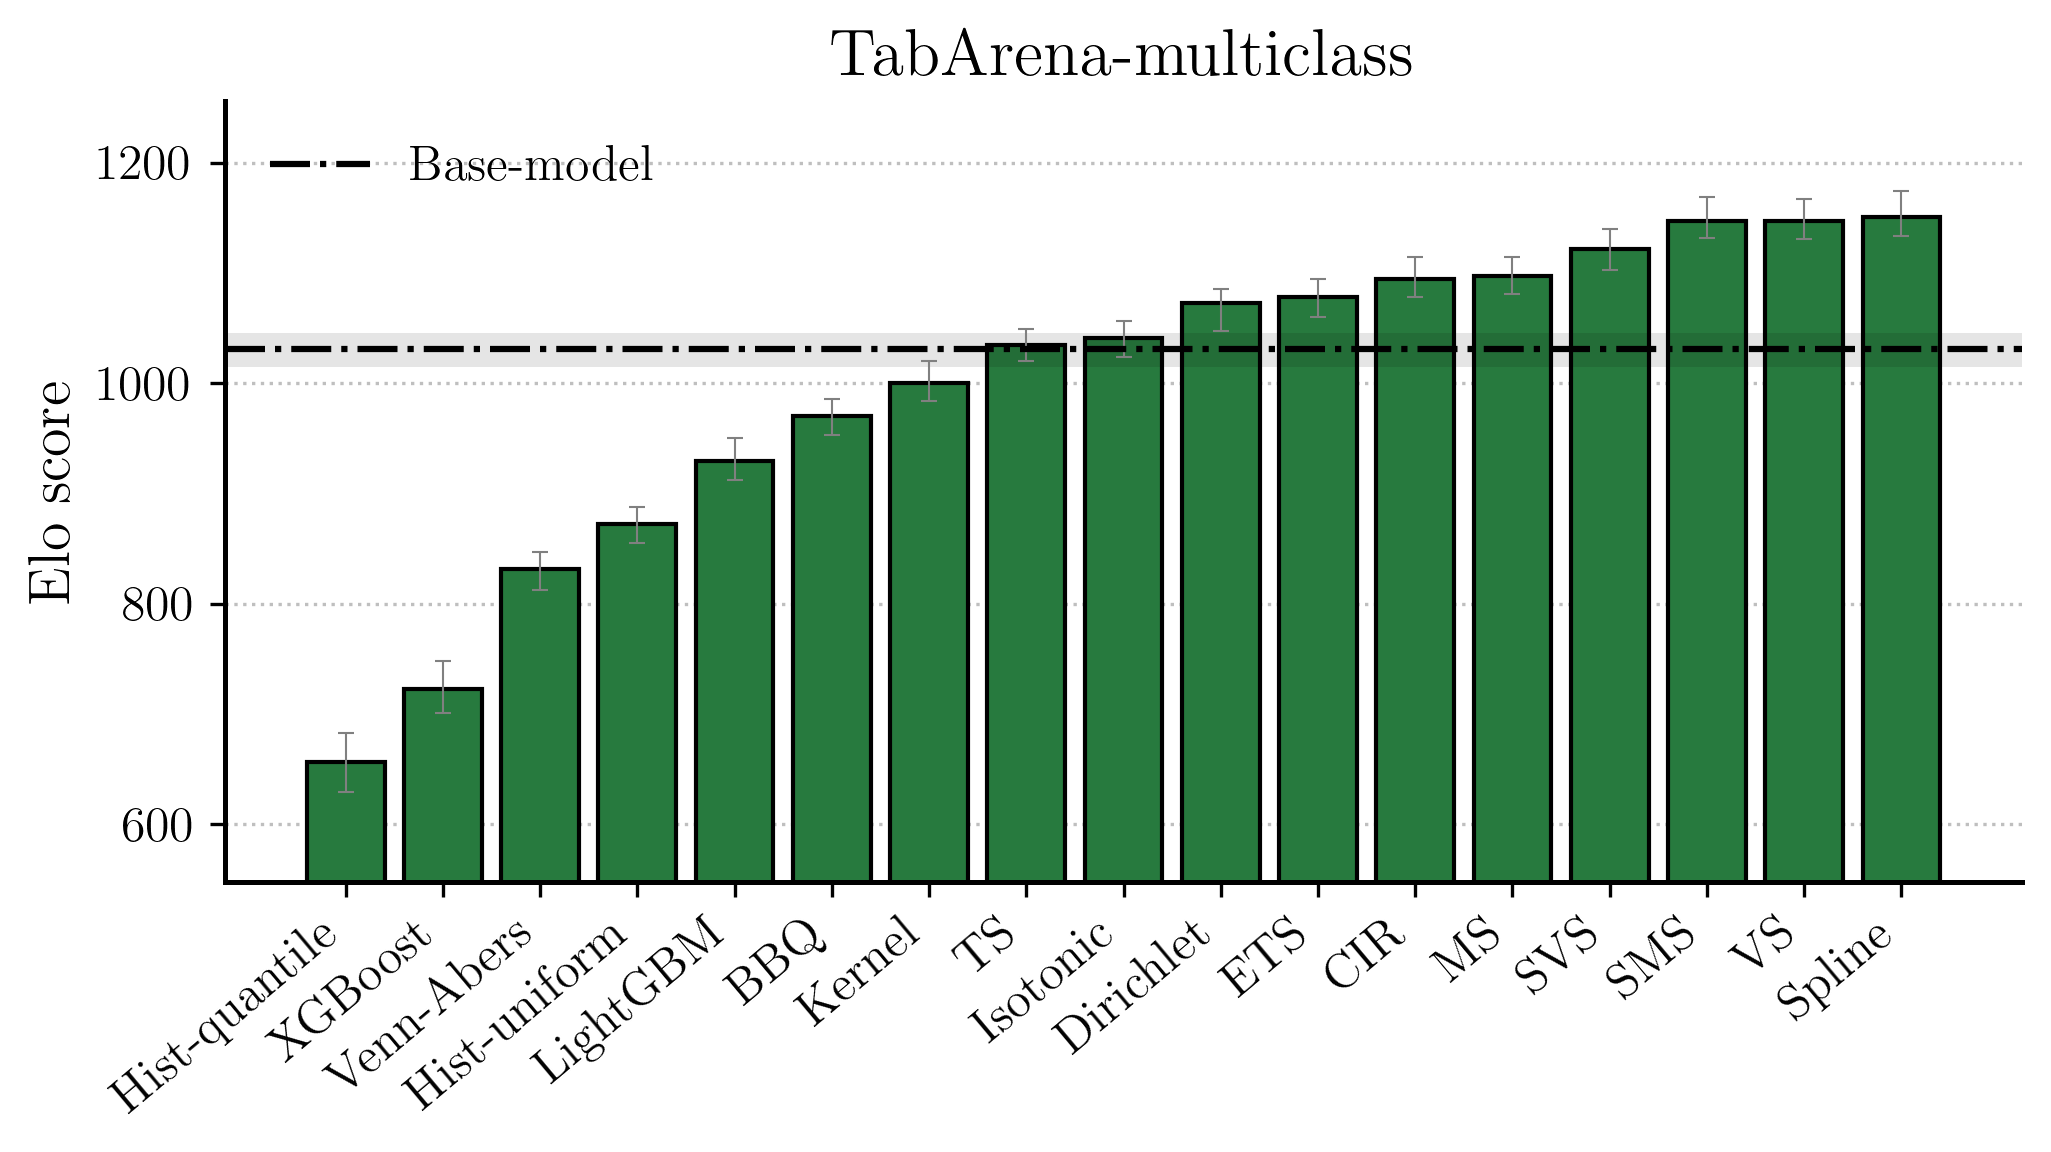

In [26]:
multiclass_tabarena_elo = compute_elo_scores(multiclass_tabarena_results, multiclass_methods, bootstrap_datasets=False, num_bootstrap=100)
plot_leaderboard(
    multiclass_tabarena_elo,
    title="TabArena-multiclass",
    y_label="Elo score",
    color="green",
    savefile="figures/multiclass_tabarena_elo.pdf"
)


Friedman Test Statistic: 429.892
P-Value: 1.02527e-80
Result: Significant difference found. Proceeding to Nemenyi test.


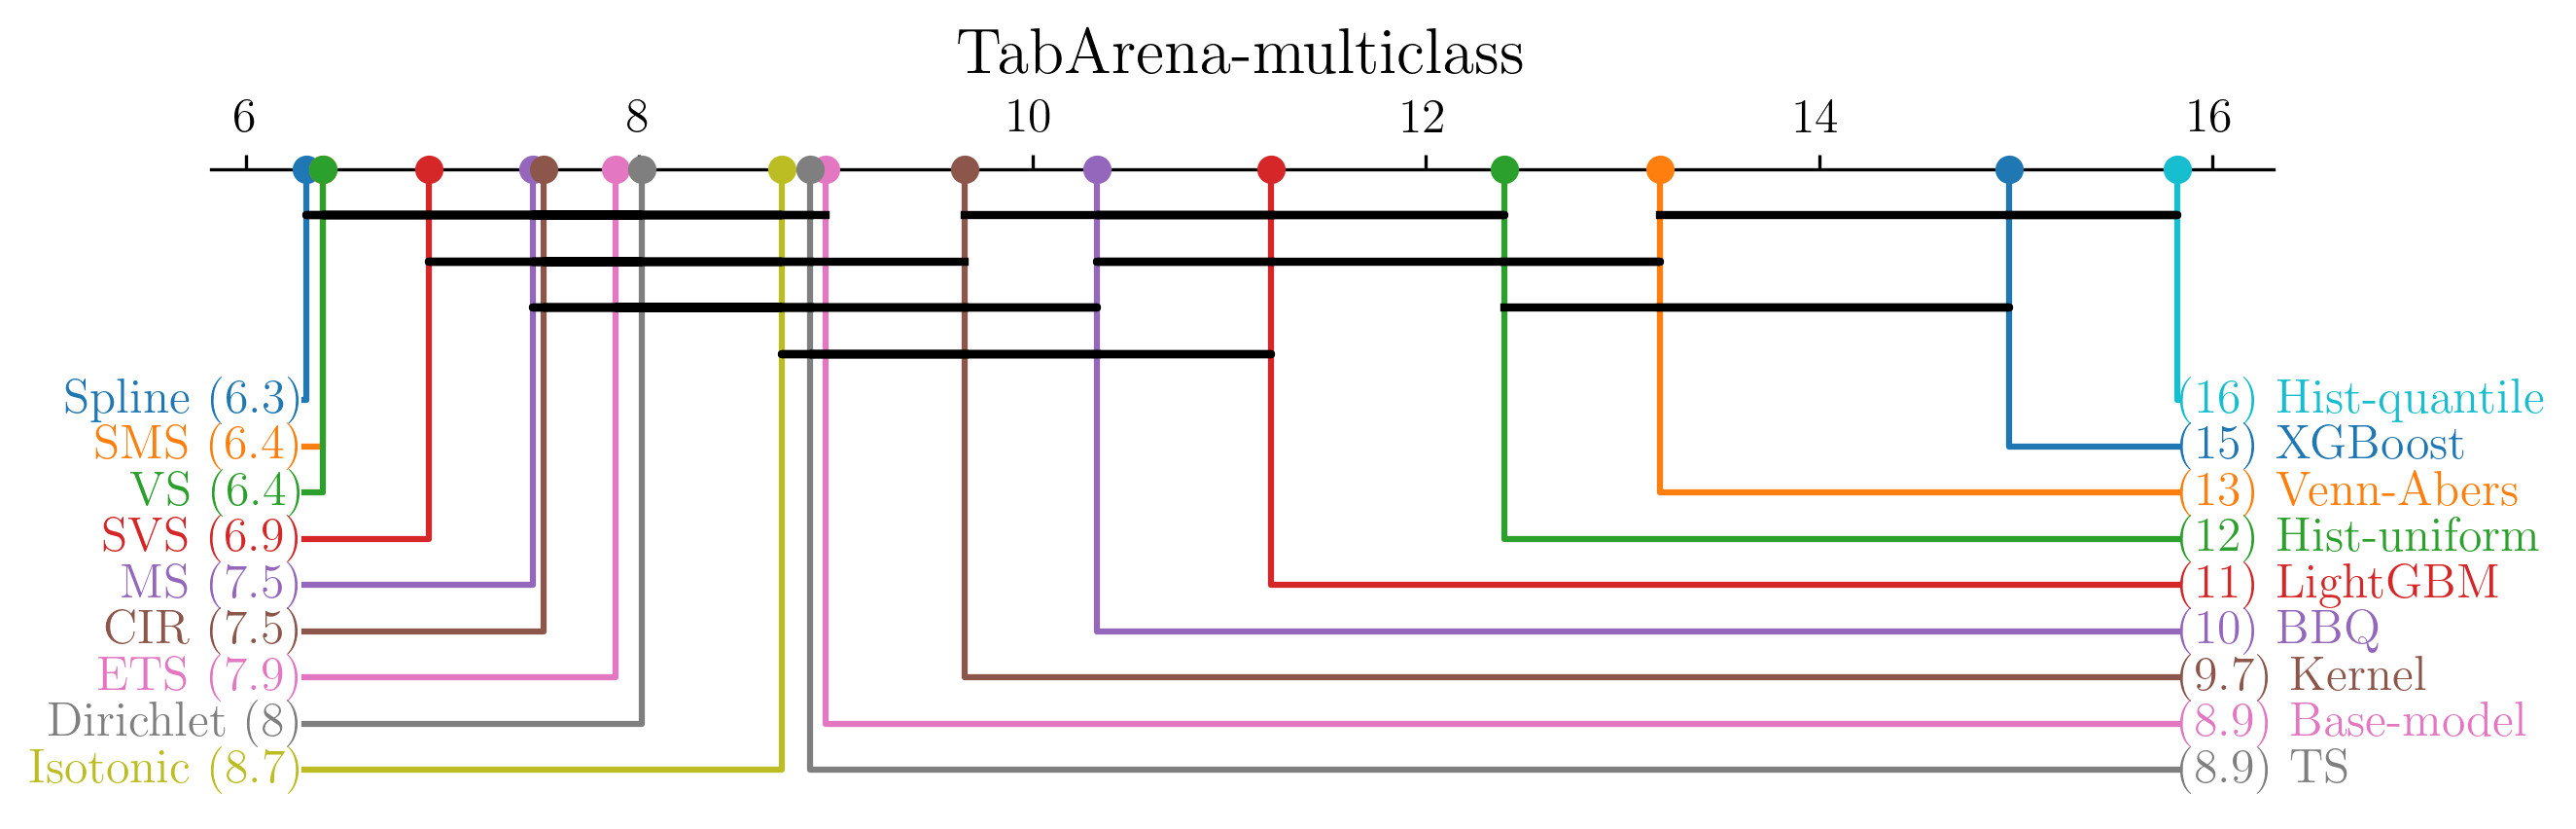

In [27]:
plot_cd_diagram(
    multiclass_tabarena_results,
    multiclass_methods,
    metric="brier",
    groupby_dataset=False,
    title="TabArena-multiclass",
    savefile="figures/multiclass_tabarena_cd.pdf"
)

In [28]:
multiclass_tabarena_absolute = compute_absolute_improvements(
    results=multiclass_tabarena_results,
    methods=multiclass_methods,
    metrics=multiclass_metrics,
    use_num_datasets=False,
    precision=2,
    factor=100
)
print(multiclass_tabarena_absolute.to_latex())

\begin{tabular}{lllll}
\toprule
 & Brier & Logloss & Ece-15 & Accuracy \\
Method &  &  &  &  \\
\midrule
Spline & $\phantom{-}0.03$ {\tiny $\pm 0.05$} (\#1) & $-0.30$ {\tiny $\pm 0.21$} (\#6) & $\phantom{-}0.11$ {\tiny $\pm 0.16$} (\#5) & $\phantom{-}0.02$ {\tiny $\pm 0.06$} (\#5) \\
SMS & $\phantom{-}0.02$ {\tiny $\pm 0.04$} (\#2) & $\phantom{-}0.11$ {\tiny $\pm 0.09$} (\#2) & $\phantom{-}0.06$ {\tiny $\pm 0.14$} (\#8) & $\phantom{-}0.07$ {\tiny $\pm 0.10$} (\#3) \\
SVS & $\phantom{-}0.02$ {\tiny $\pm 0.03$} (\#3) & $\phantom{-}0.06$ {\tiny $\pm 0.08$} (\#3) & $\phantom{-}0.06$ {\tiny $\pm 0.15$} (\#9) & $\phantom{-}0.07$ {\tiny $\pm 0.09$} (\#2) \\
VS & $\phantom{-}0.00$ {\tiny $\pm 0.05$} (\#4) & $-2.59$ {\tiny $\pm 1.92$} (\#11) & $\phantom{-}0.07$ {\tiny $\pm 0.15$} (\#7) & $\phantom{-}0.10$ {\tiny $\pm 0.10$} (\#1) \\
ETS & $\phantom{-}0.00$ {\tiny $\pm 0.04$} (\#5) & $\phantom{-}0.11$ {\tiny $\pm 0.08$} (\#1) & $\phantom{-}0.18$ {\tiny $\pm 0.15$} (\#4) & $\phantom{-}0.00$ {\tin

## CV-multiclass

In [29]:
multiclass_cv_results = load_benchmark_results(benchmark_name="CV-multiclass", methods=multiclass_methods)

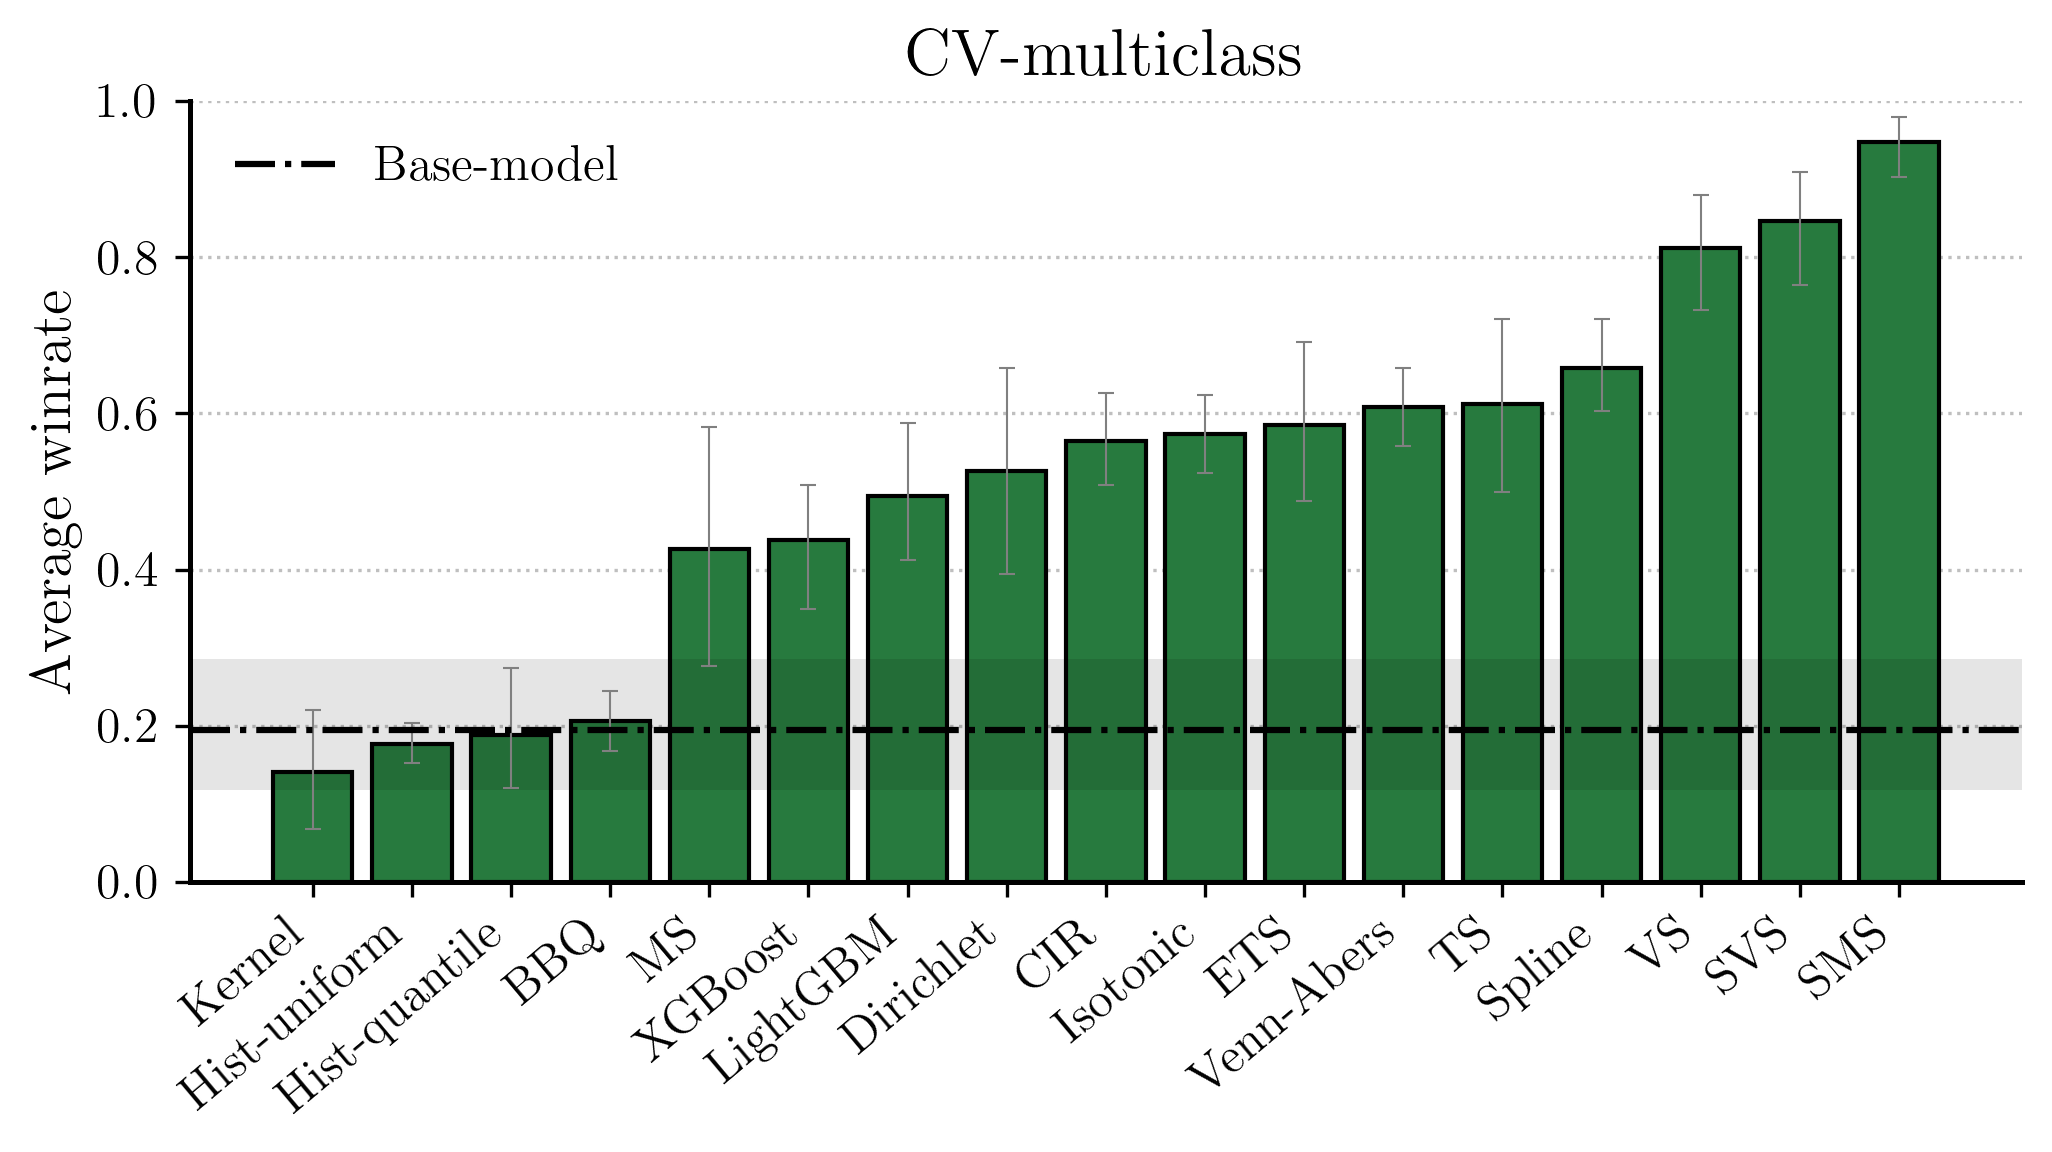

In [30]:
multiclass_cv_winrates = compute_winrates(multiclass_cv_results, multiclass_methods, metric="brier", bootstrap_datasets=False, n_bootstraps=1000)
plot_leaderboard(
    multiclass_cv_winrates,
    title="CV-multiclass",
    y_label="Average winrate",
    y_lim=(0,1),
    color="green",
    savefile="figures/multiclass_cv_winrates.pdf"
)

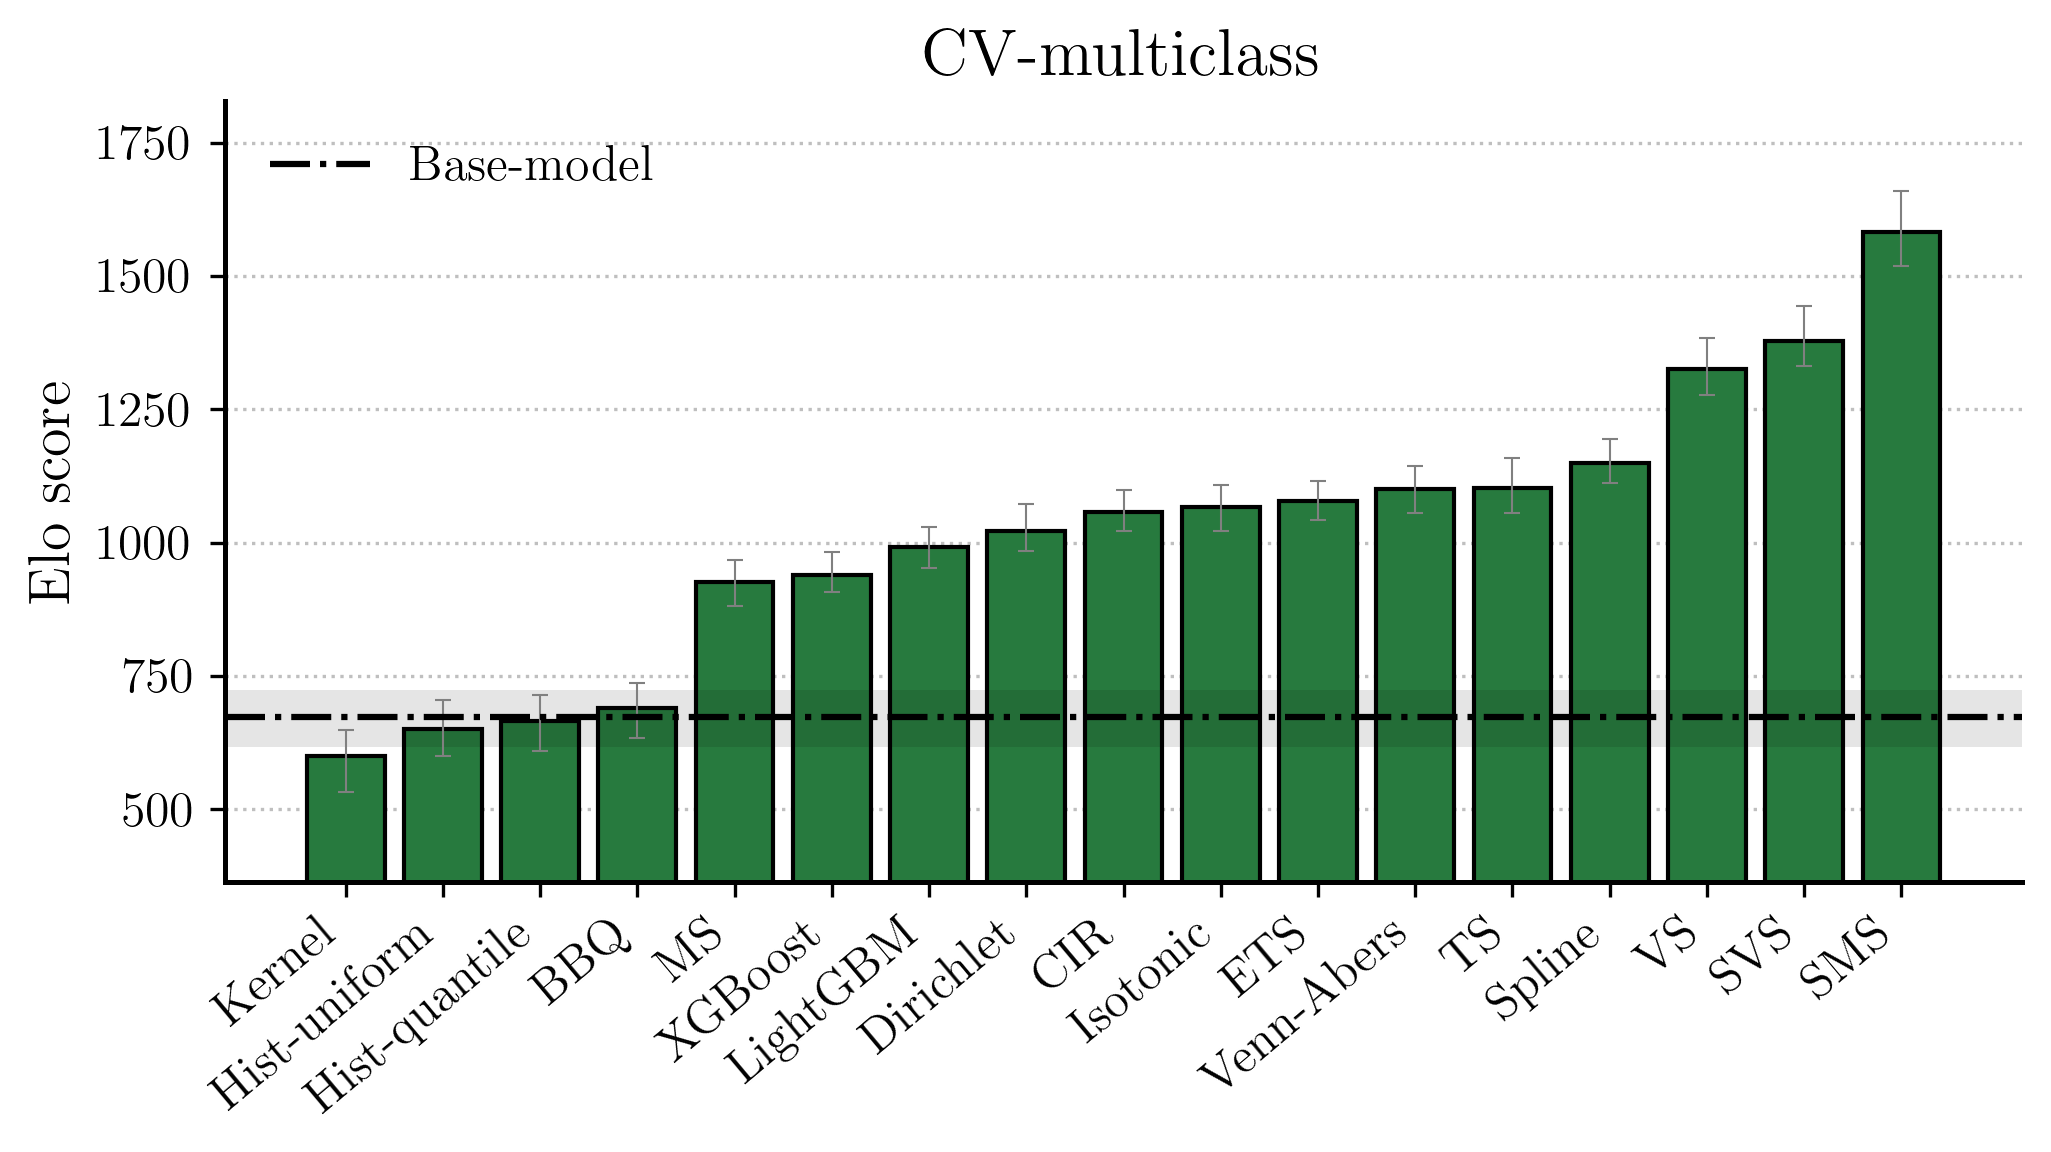

In [31]:
multiclass_cv_elo = compute_elo_scores(multiclass_cv_results, multiclass_methods, bootstrap_datasets=False, num_bootstrap=100)
plot_leaderboard(
    multiclass_cv_elo,
    title="CV-multiclass",
    y_label="Elo score",
    color="green",
    savefile="figures/multiclass_cv_elo.pdf"
)


Friedman Test Statistic: 203.737
P-Value: 5.07067e-34
Result: Significant difference found. Proceeding to Nemenyi test.


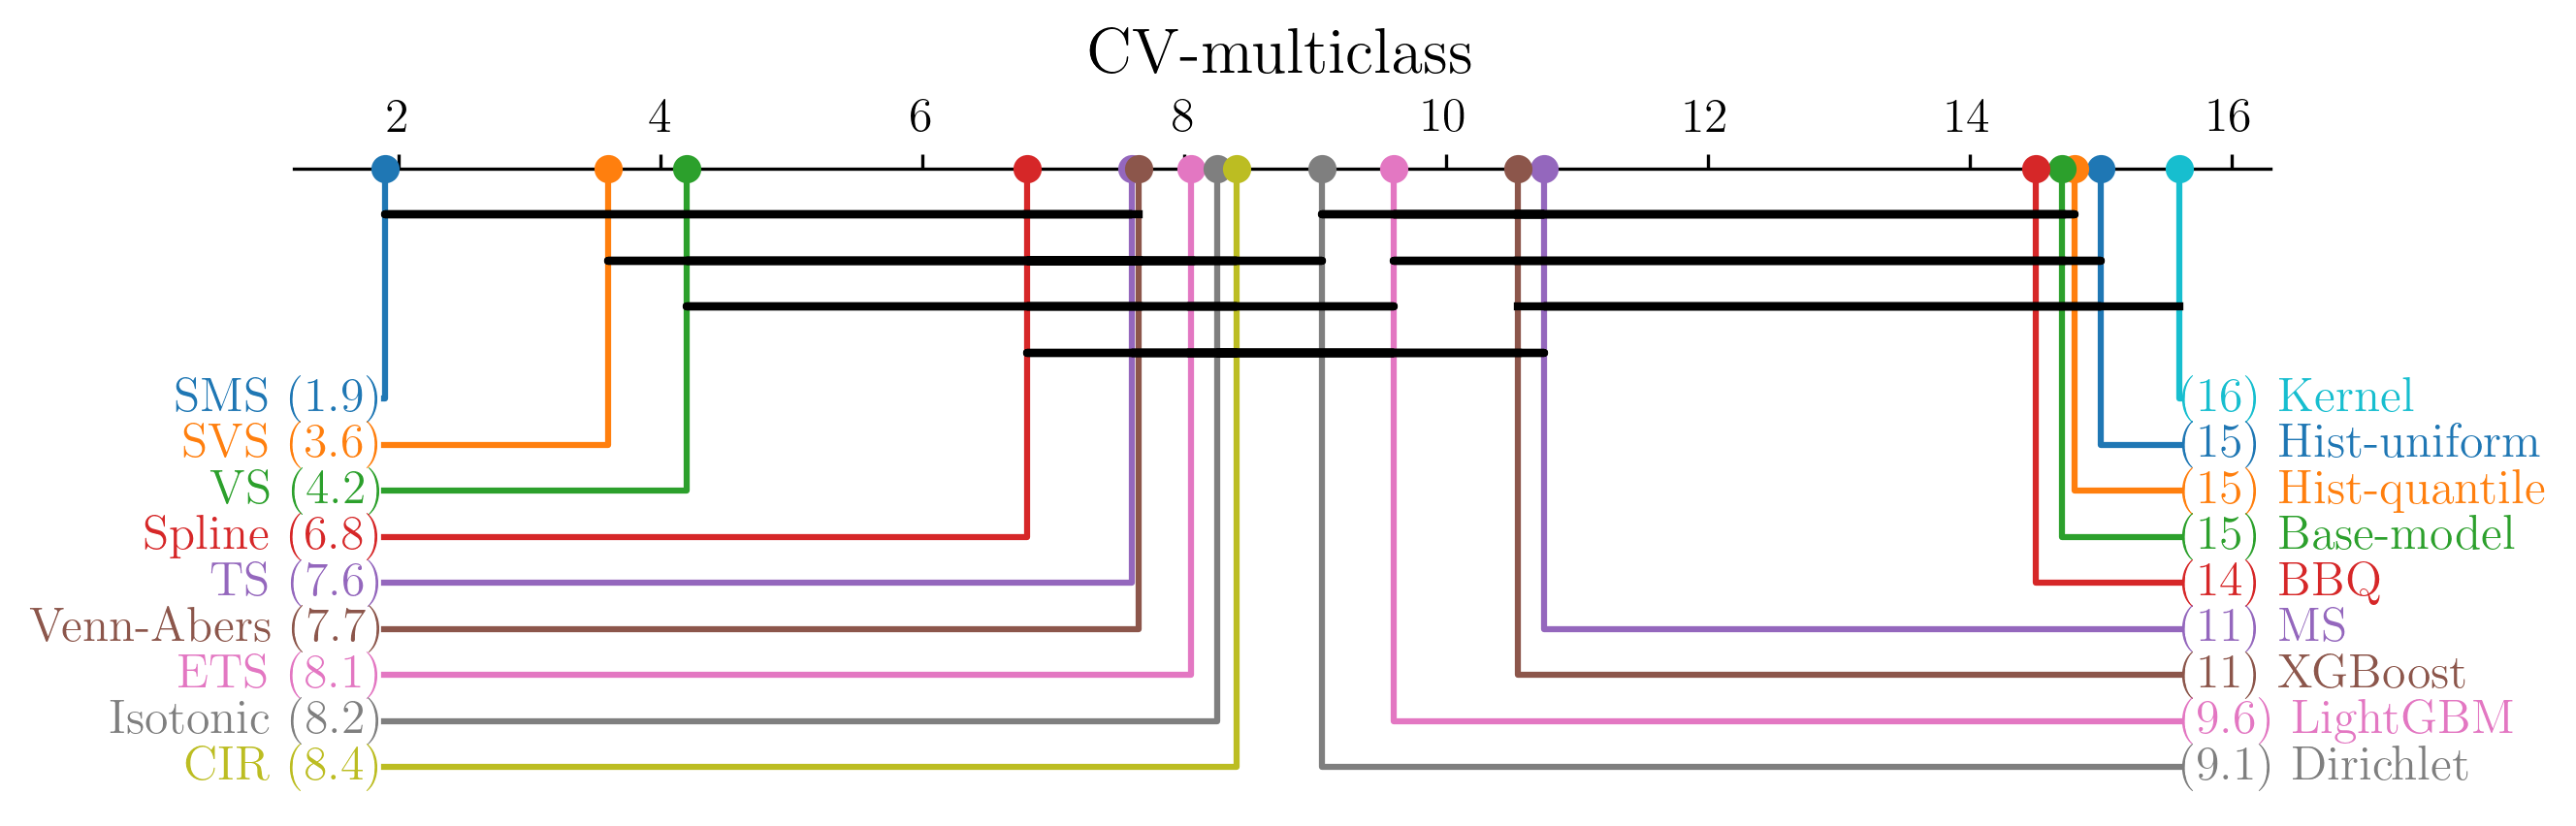

In [32]:
plot_cd_diagram(
    multiclass_cv_results,
    multiclass_methods,
    metric="brier",
    groupby_dataset=False,
    title="CV-multiclass",
    savefile="figures/multiclass_cv_cd.pdf"
)

In [33]:
multiclass_cv_absolute = compute_absolute_improvements(
    results=multiclass_cv_results,
    methods=multiclass_methods,
    metrics=multiclass_metrics,
    use_num_datasets=False,
    precision=2,
    factor=100
)
print(multiclass_cv_absolute.to_latex())

\begin{tabular}{lllll}
\toprule
 & Brier & Logloss & Ece-15 & Accuracy \\
Method &  &  &  &  \\
\midrule
SMS & $\phantom{-}5.17$ {\tiny $\pm 1.82$} (\#1) & $\phantom{-}57.67$ {\tiny $\pm 24.40$} (\#1) & $\phantom{-}8.87$ {\tiny $\pm 2.90$} (\#1) & $\phantom{-}0.83$ {\tiny $\pm 0.48$} (\#1) \\
VS & $\phantom{-}4.83$ {\tiny $\pm 1.71$} (\#2) & $\phantom{-}49.19$ {\tiny $\pm 30.45$} (\#7) & $\phantom{-}8.52$ {\tiny $\pm 2.87$} (\#5) & $\phantom{-}0.62$ {\tiny $\pm 0.47$} (\#2) \\
SVS & $\phantom{-}4.80$ {\tiny $\pm 1.69$} (\#3) & $\phantom{-}56.52$ {\tiny $\pm 24.04$} (\#2) & $\phantom{-}8.84$ {\tiny $\pm 2.89$} (\#2) & $\phantom{-}0.54$ {\tiny $\pm 0.40$} (\#3) \\
Spline & $\phantom{-}4.39$ {\tiny $\pm 1.59$} (\#4) & $\phantom{-}51.38$ {\tiny $\pm 23.54$} (\#6) & $\phantom{-}7.66$ {\tiny $\pm 2.55$} (\#6) & $\phantom{-}0.35$ {\tiny $\pm 0.23$} (\#5) \\
Isotonic & $\phantom{-}4.16$ {\tiny $\pm 1.58$} (\#5) & $-12.21$ {\tiny $\pm 61.80$} (\#15) & $\phantom{-}7.28$ {\tiny $\pm 2.65$} (\#7) 

## ImageNet-multiclass

In [34]:
imagenet_methods = [
    "Base-model",
    "Hist-uniform",
    "Hist-quantile",
    "Isotonic",
    "CIR",
    "TS",
    "ETS",
    "VS",
    "SVS",
]

In [35]:
multiclass_imagenet_results = load_benchmark_results(benchmark_name="ImageNet-multiclass", methods=imagenet_methods)

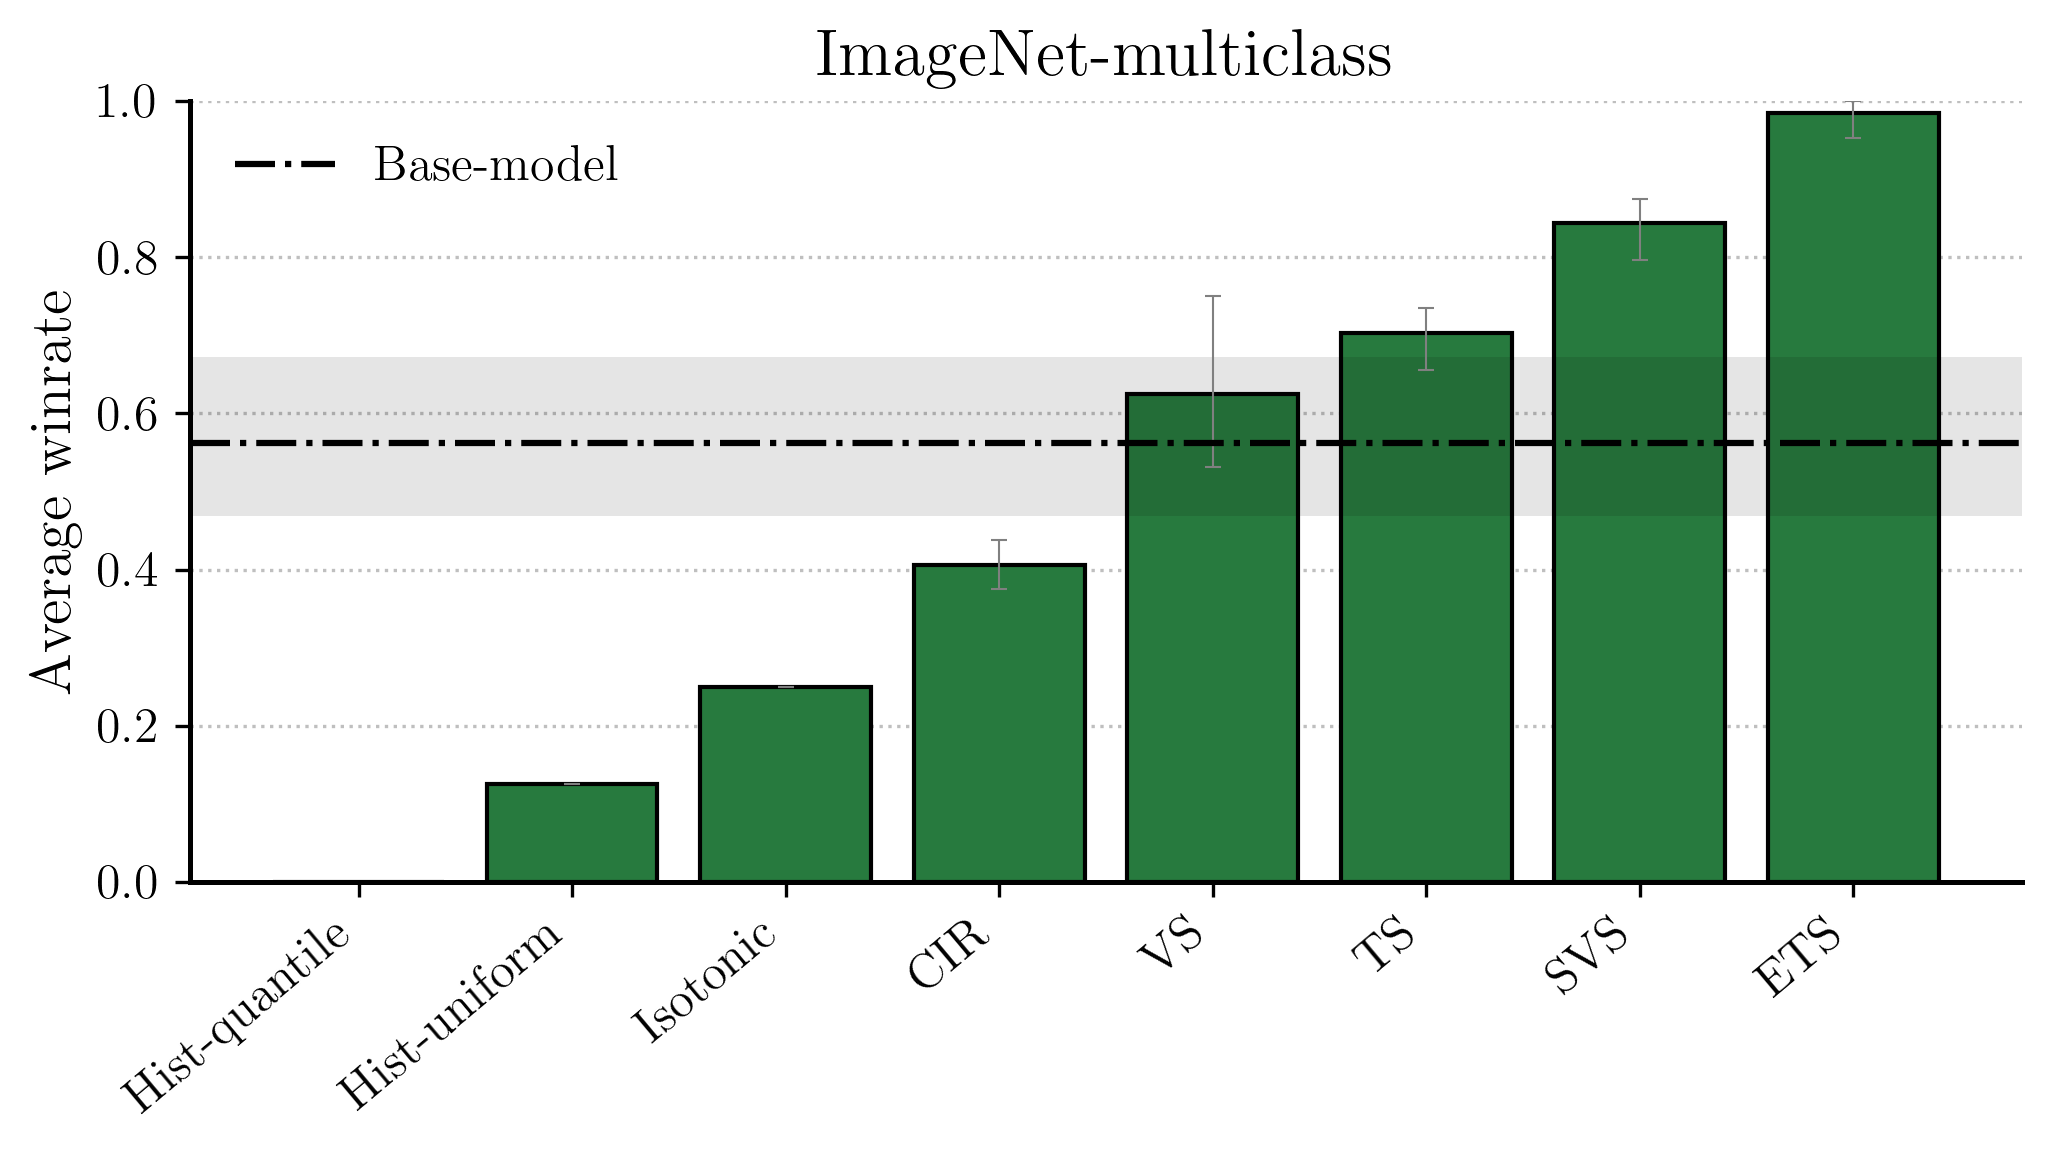

In [36]:
multiclass_imagenet_winrates = compute_winrates(multiclass_imagenet_results, imagenet_methods, metric="brier", bootstrap_datasets=False, n_bootstraps=1000)
plot_leaderboard(
    multiclass_imagenet_winrates,
    title="ImageNet-multiclass",
    y_label="Average winrate",
    y_lim=(0,1),
    color="green",
    savefile="figures/multiclass_imagenet_winrates.pdf"
)

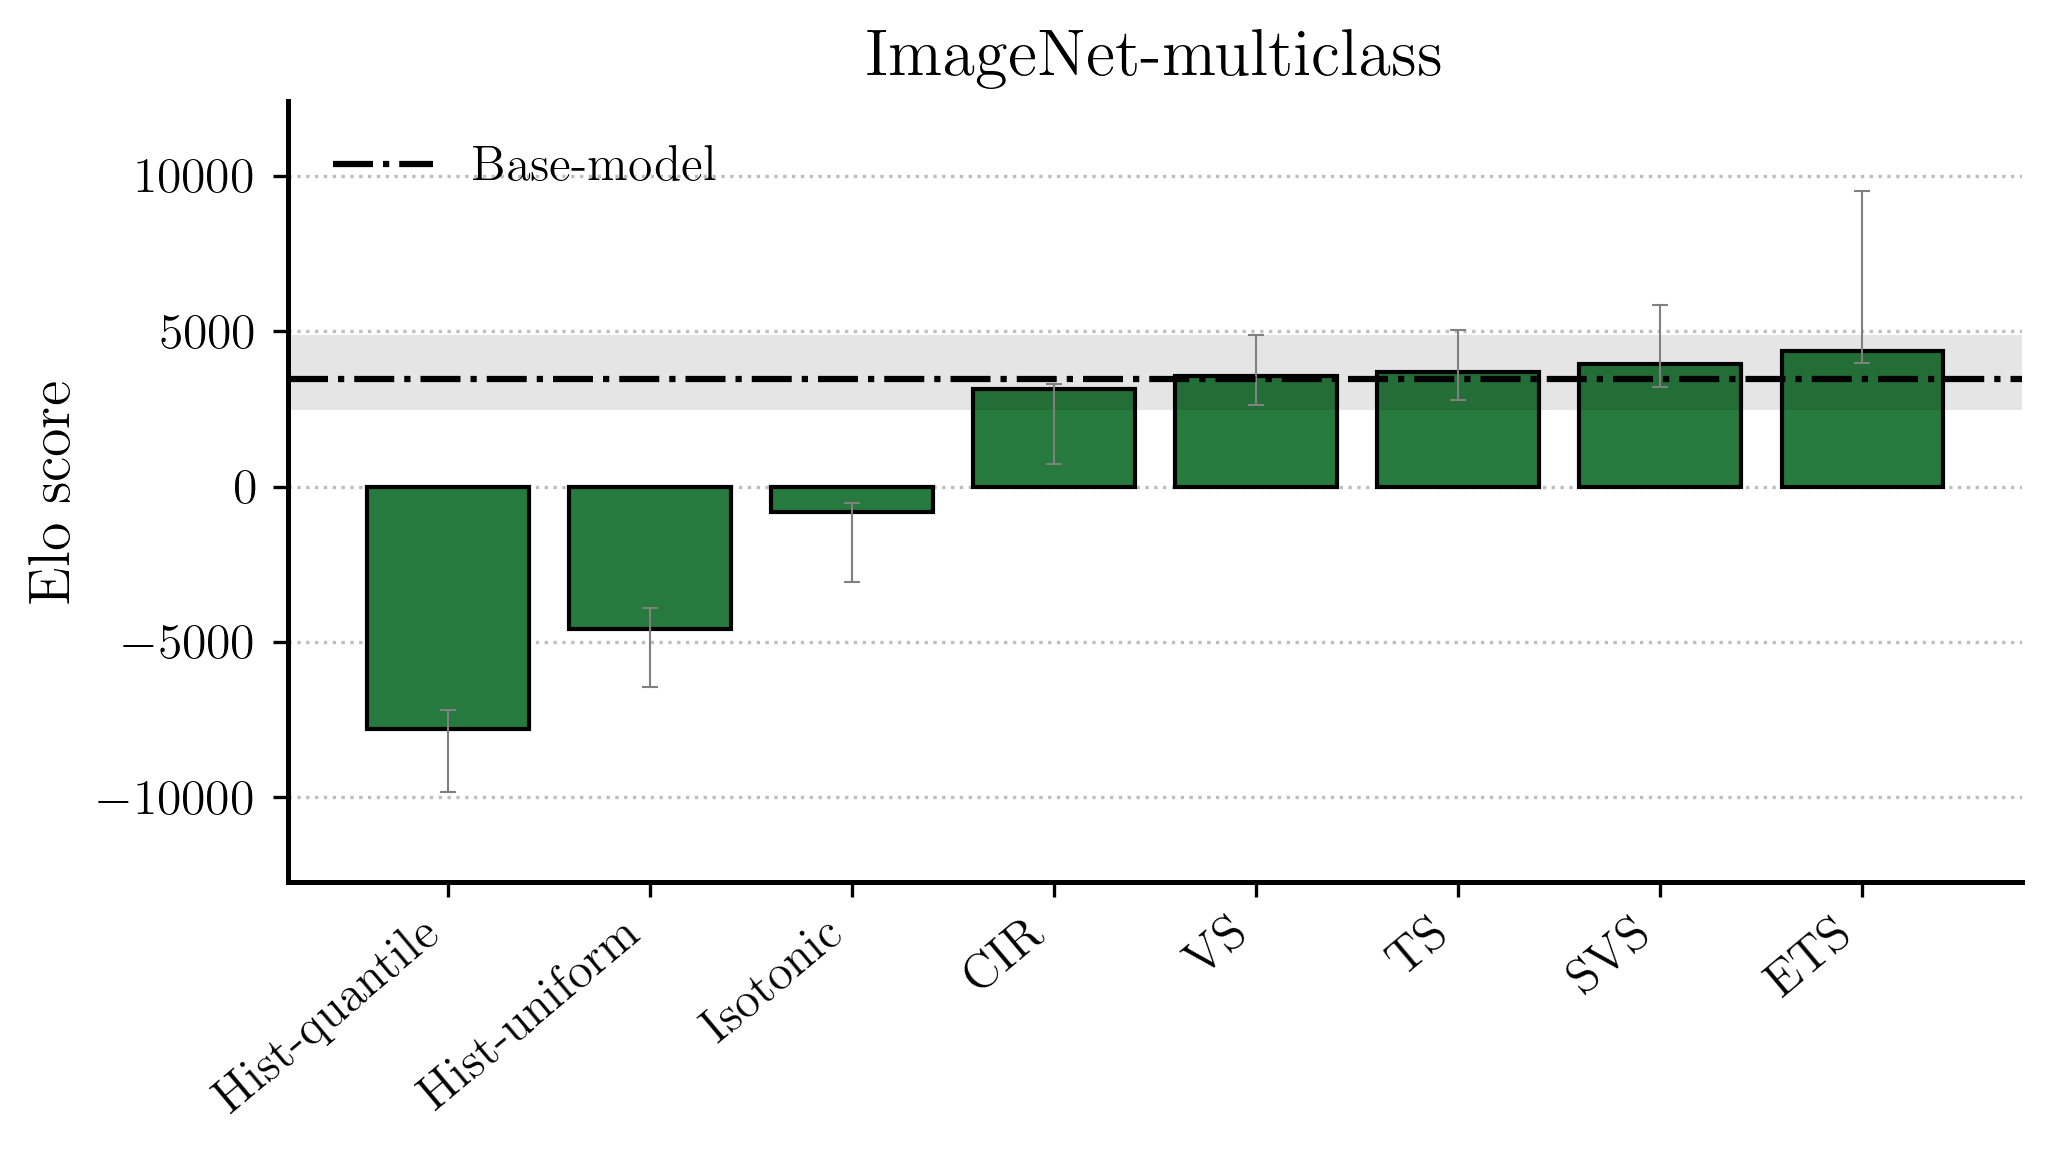

In [37]:
multiclass_imagenet_elo = compute_elo_scores(multiclass_imagenet_results, imagenet_methods, bootstrap_datasets=False, num_bootstrap=100)
plot_leaderboard(
    multiclass_imagenet_elo,
    title="ImageNet-multiclass",
    y_label="Elo score",
    color="green",
    savefile="figures/multiclass_imagenet_elo.pdf"
)


Friedman Test Statistic: 59.767
P-Value: 5.17902e-10
Result: Significant difference found. Proceeding to Nemenyi test.


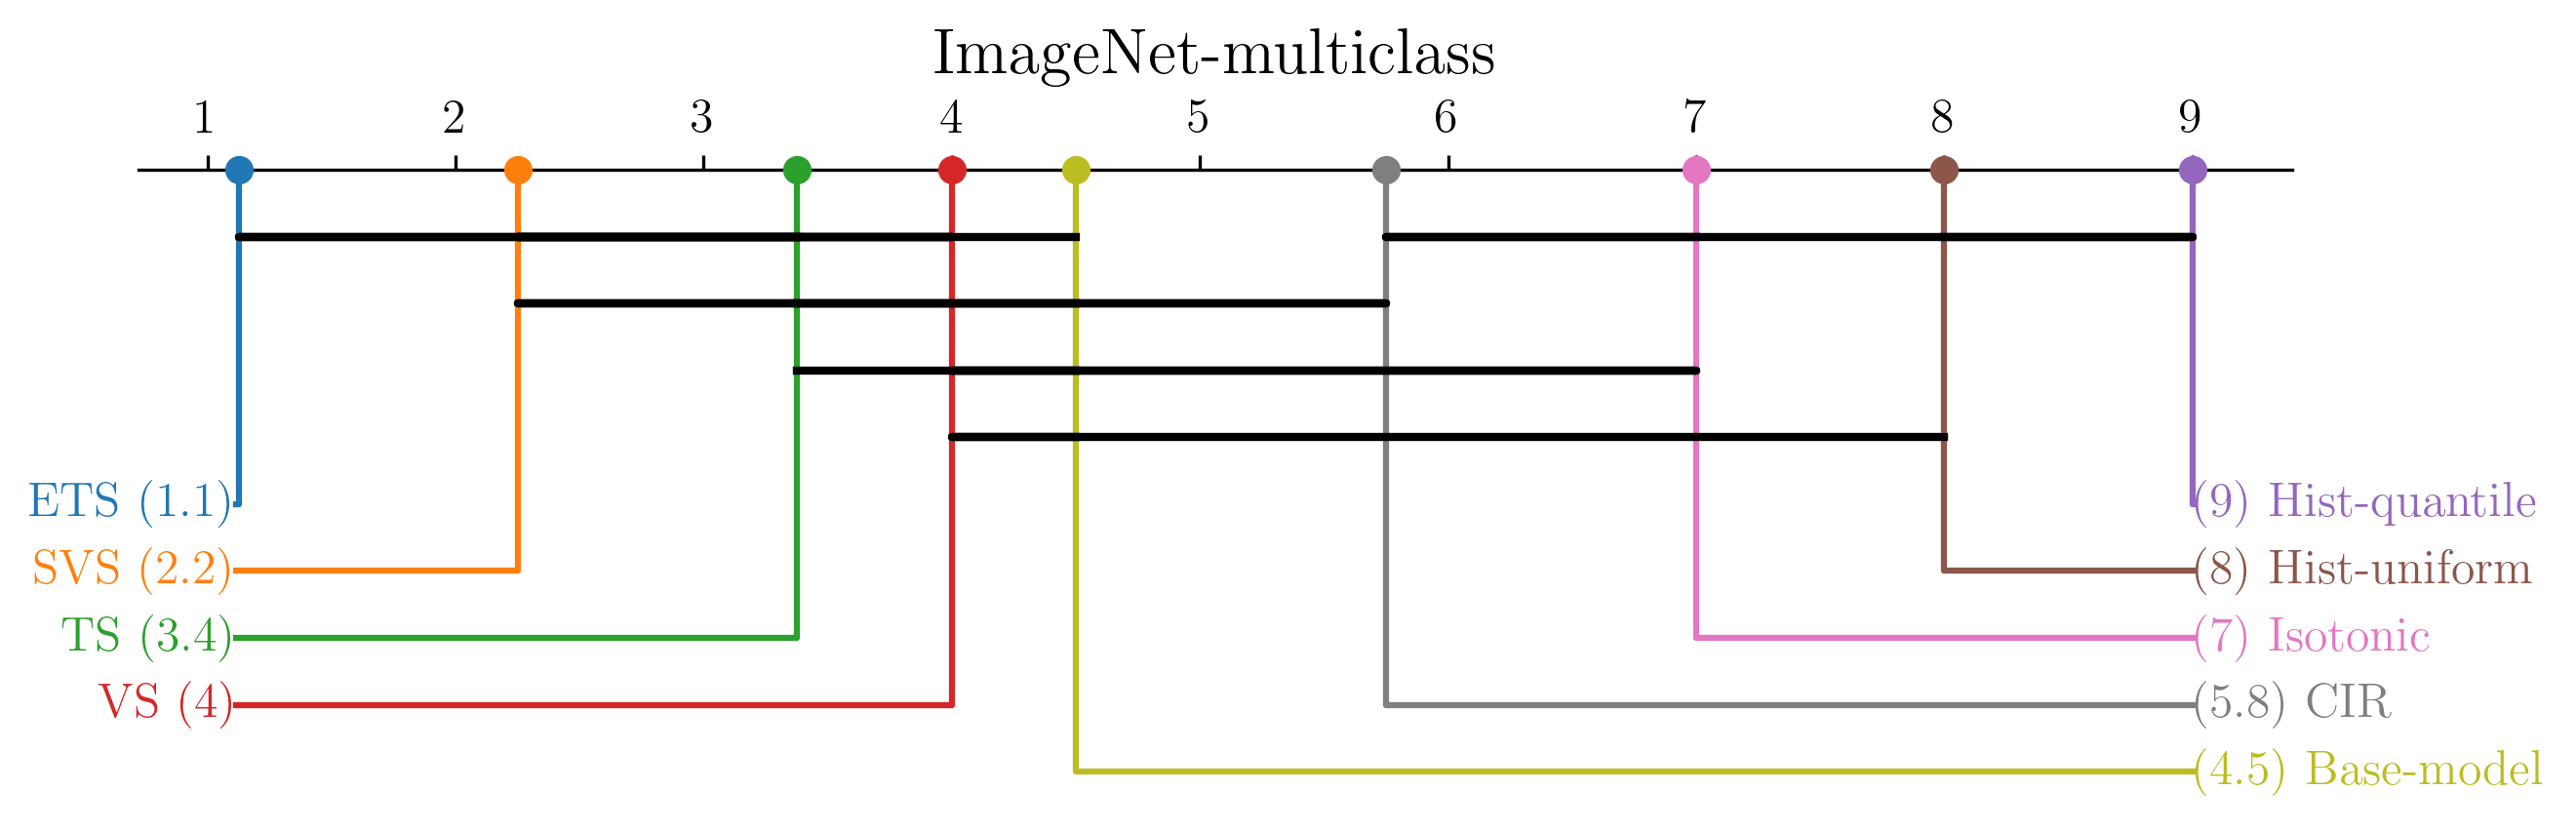

In [38]:
plot_cd_diagram(
    multiclass_imagenet_results,
    imagenet_methods,
    metric="brier",
    groupby_dataset=False,
    title="ImageNet-multiclass",
    savefile="figures/multiclass_imagenet_cd.pdf"
)

In [39]:
multiclass_imagenet_absolute = compute_absolute_improvements(
    results=multiclass_imagenet_results,
    methods=imagenet_methods,
    metrics=multiclass_metrics,
    use_num_datasets=False,
    precision=2,
    factor=100
)
print(multiclass_imagenet_absolute.to_latex())

\begin{tabular}{lllll}
\toprule
 & Brier & Logloss & Ece-15 & Accuracy \\
Method &  &  &  &  \\
\midrule
ETS & $\phantom{-}0.42$ {\tiny $\pm 0.24$} (\#1) & $\phantom{-}2.57$ {\tiny $\pm 2.13$} (\#3) & $\phantom{-}3.84$ {\tiny $\pm 1.69$} (\#1) & $\phantom{-}0.00$ {\tiny $\pm 0.00$} (\#2) \\
SVS & $\phantom{-}0.33$ {\tiny $\pm 0.25$} (\#2) & $\phantom{-}4.10$ {\tiny $\pm 2.06$} (\#1) & $\phantom{-}3.21$ {\tiny $\pm 1.59$} (\#2) & $\phantom{-}0.00$ {\tiny $\pm 0.01$} (\#1) \\
TS & $\phantom{-}0.32$ {\tiny $\pm 0.25$} (\#3) & $\phantom{-}4.00$ {\tiny $\pm 2.06$} (\#2) & $\phantom{-}3.20$ {\tiny $\pm 1.59$} (\#3) & $\phantom{-}0.00$ {\tiny $\pm 0.00$} (\#2) \\
VS & $\phantom{-}0.00$ {\tiny $\pm 0.32$} (\#4) & $-4.28$ {\tiny $\pm 3.39$} (\#5) & $\phantom{-}2.67$ {\tiny $\pm 1.55$} (\#5) & $-0.11$ {\tiny $\pm 0.11$} (\#5) \\
Base-model & $\phantom{-}0.00$ {\tiny $\pm 0.00$} (\#5) & $\phantom{-}0.00$ {\tiny $\pm 0.00$} (\#4) & $\phantom{-}0.00$ {\tiny $\pm 0.00$} (\#8) & $\phantom{-}0.00$ {\t

# Grouped leaderboards

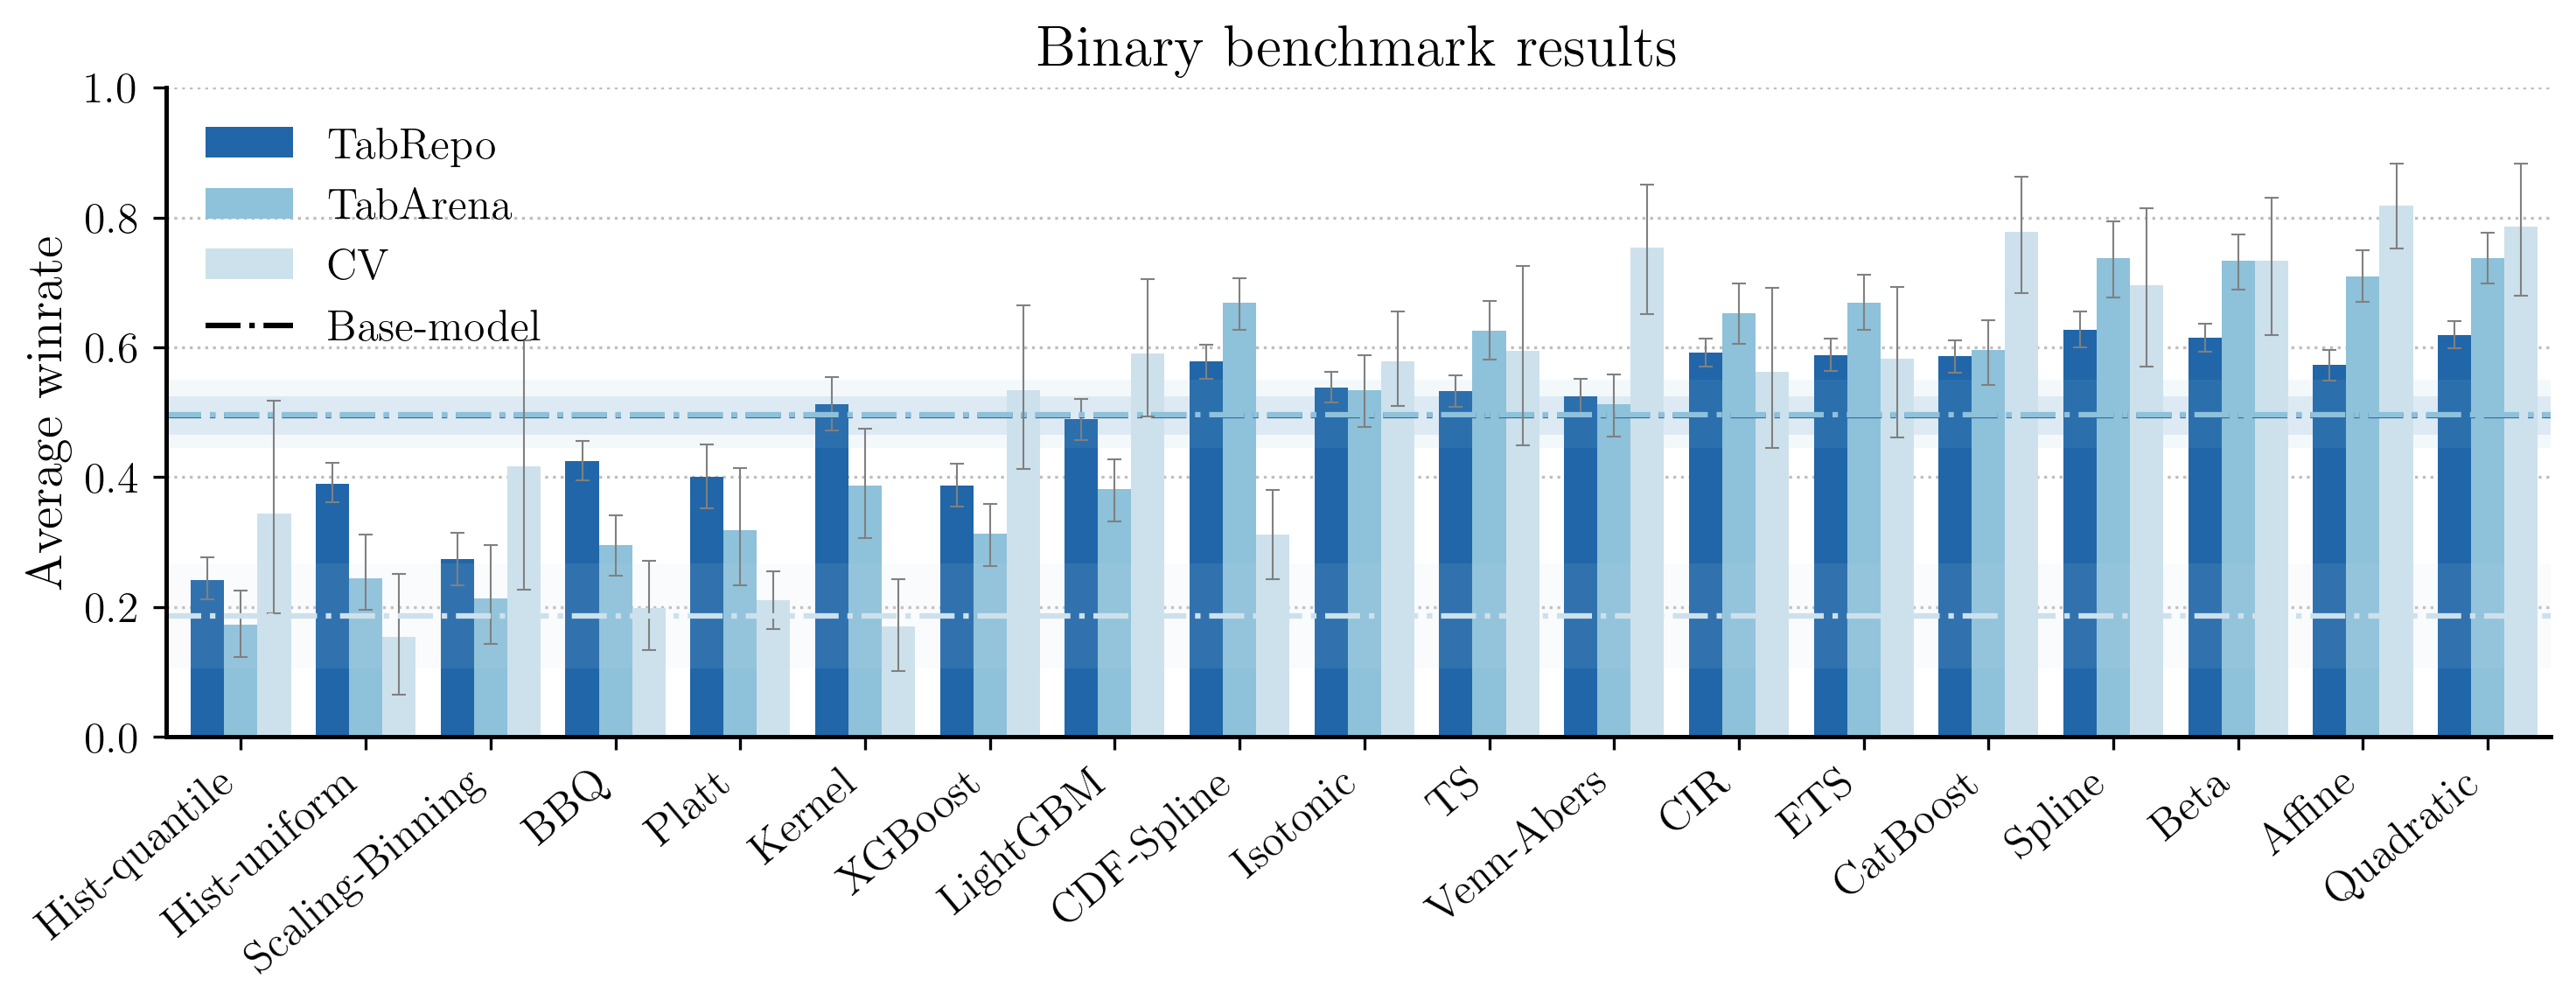

In [40]:
plot_grouped_leaderboards(
    {"TabRepo": binary_tabrepo_winrates, "TabArena": binary_tabarena_winrates, "CV": binary_cv_winrates},
    title="Binary benchmark results",
    y_label="Average winrate",
    y_lim=(0,1),
    savefile="figures/binary_winrates.pdf",
    color="blue"
)

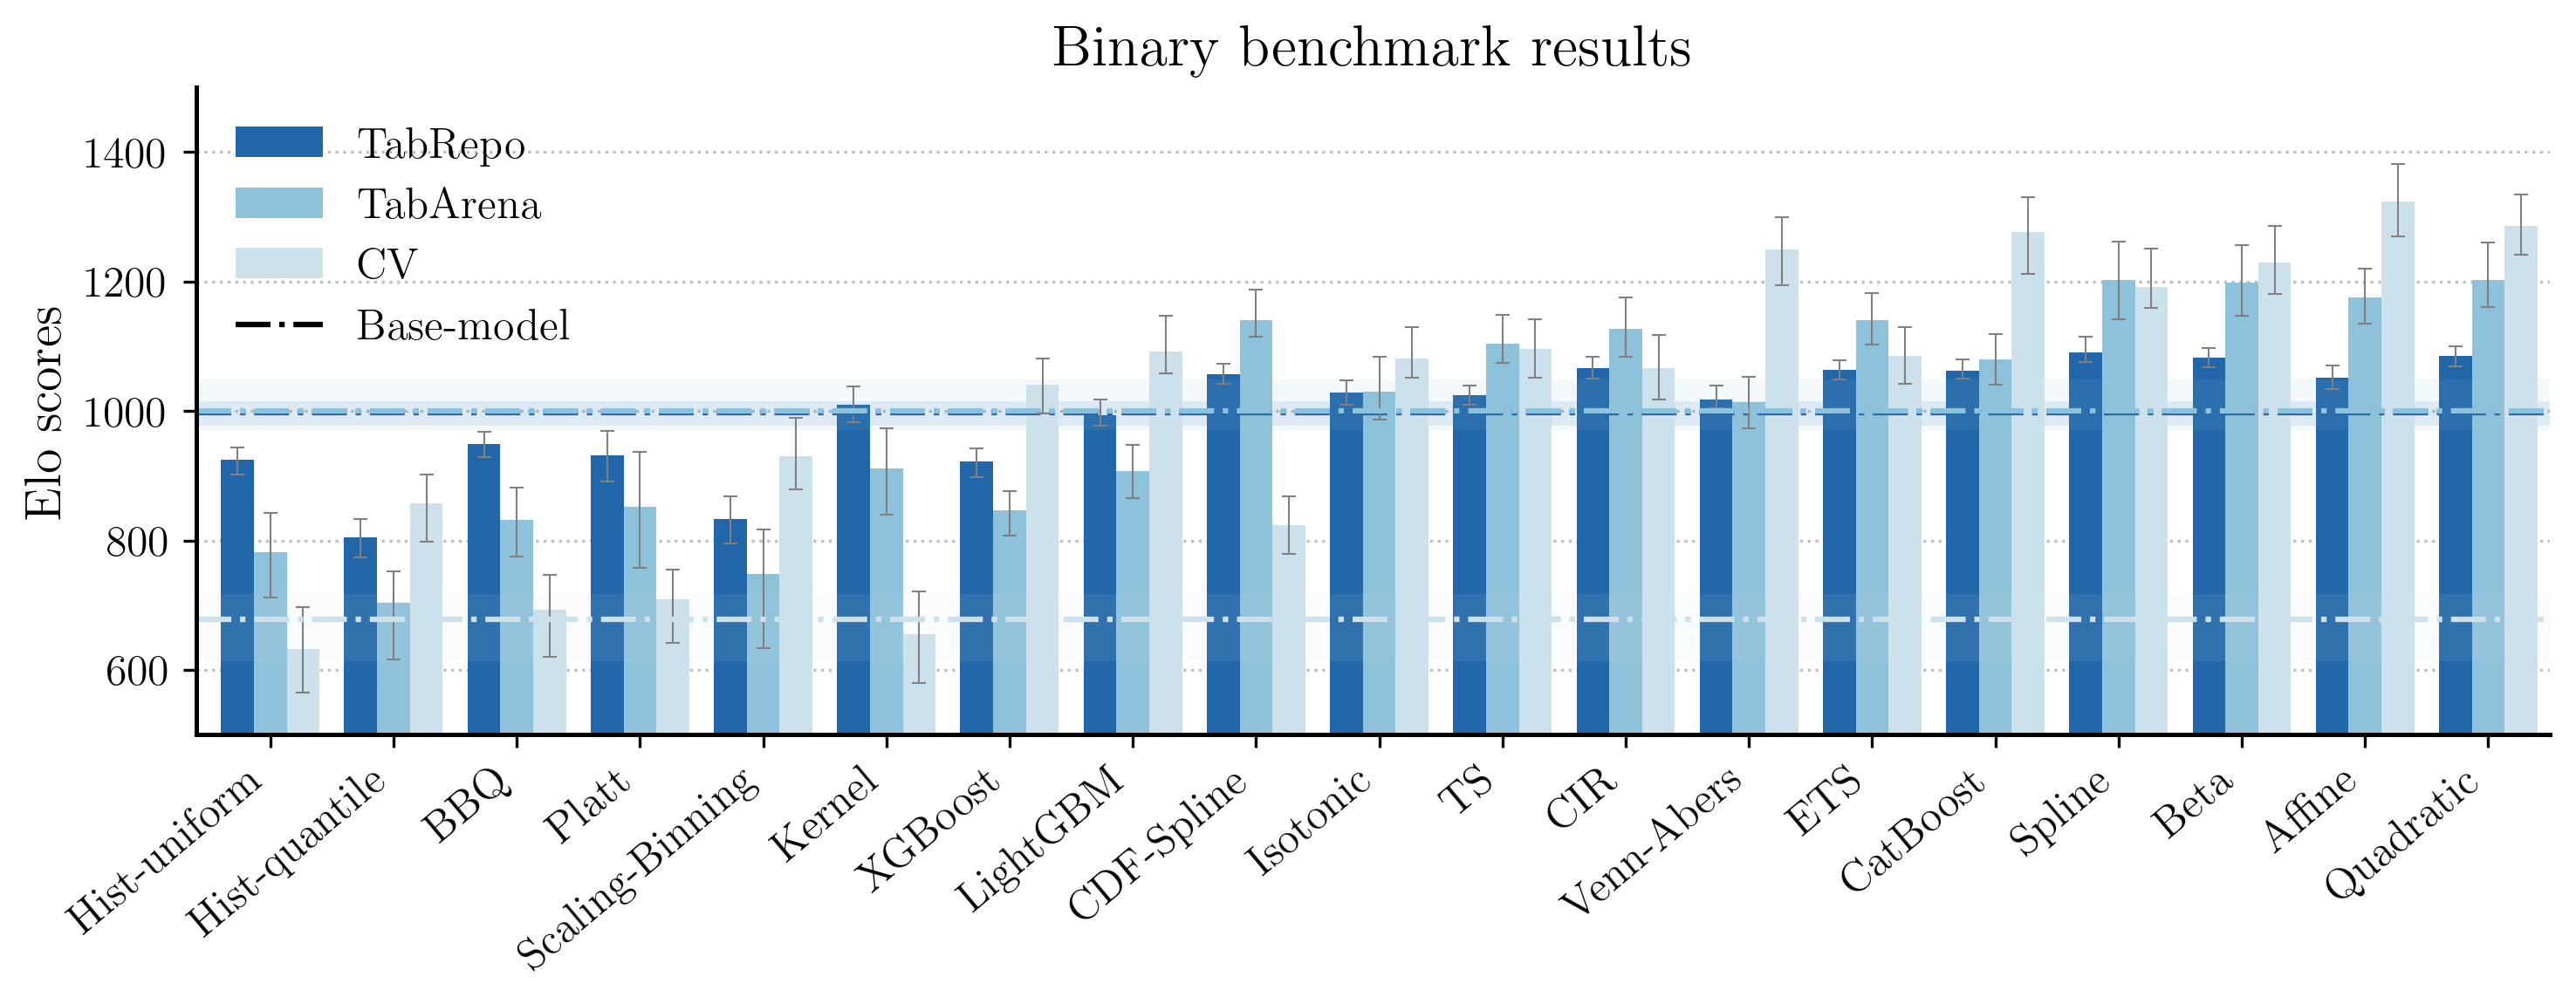

In [41]:
plot_grouped_leaderboards(
    {"TabRepo": binary_tabrepo_elo, "TabArena": binary_tabarena_elo, "CV": binary_cv_elo},
    title="Binary benchmark results",
    y_label="Elo scores",
    y_lim=(500, 1500),
    savefile="figures/binary_elo.pdf",
    color="blue"
)

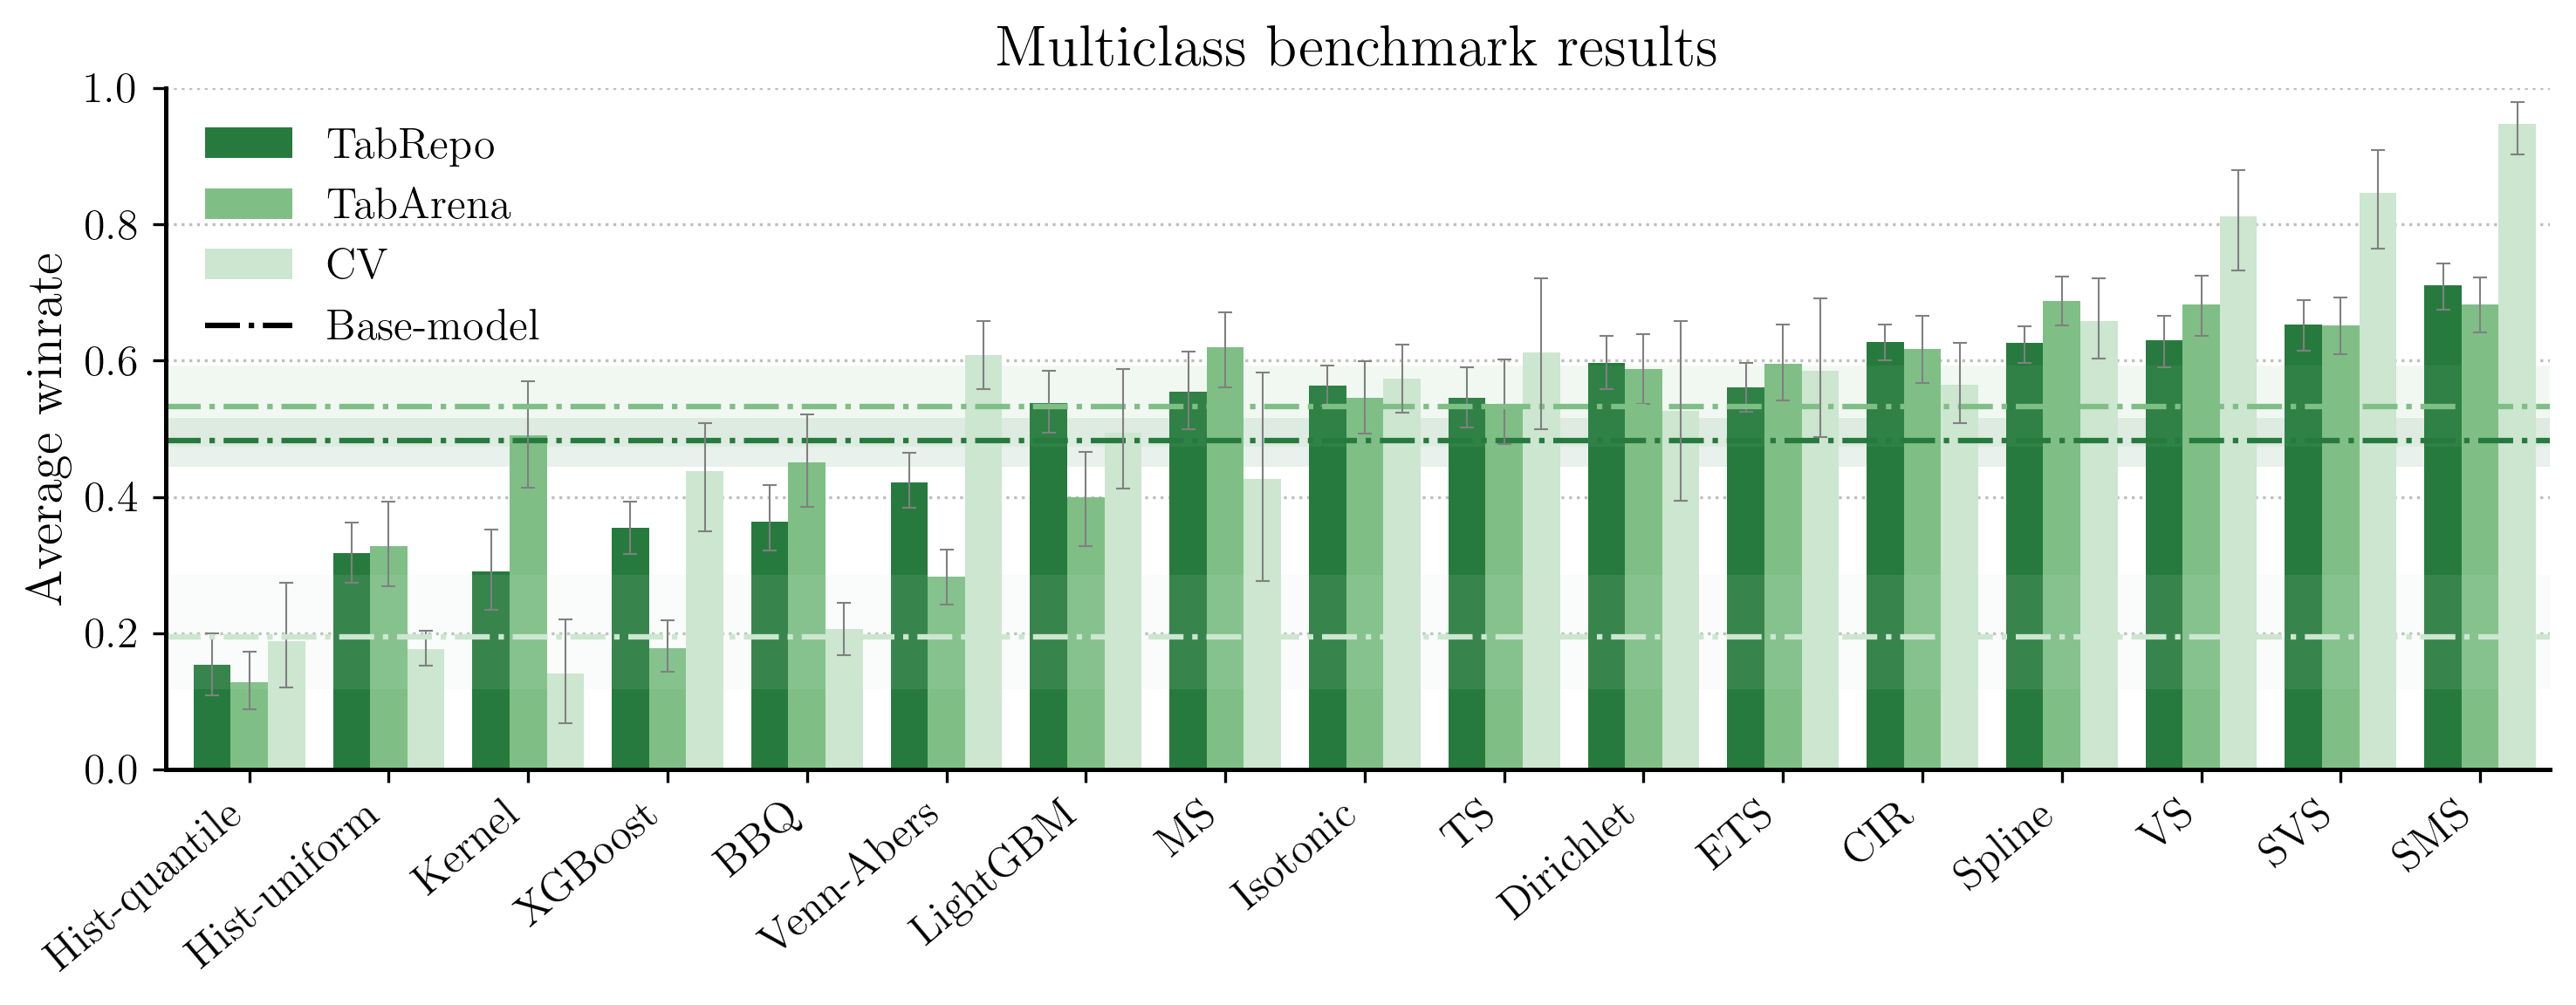

In [42]:
plot_grouped_leaderboards(
    {"TabRepo": multiclass_tabrepo_winrates, "TabArena": multiclass_tabarena_winrates, "CV": multiclass_cv_winrates},
    title="Multiclass benchmark results",
    y_label="Average winrate",
    y_lim=(0,1),
    savefile="figures/multiclass_winrates.pdf",
    color="green"
)

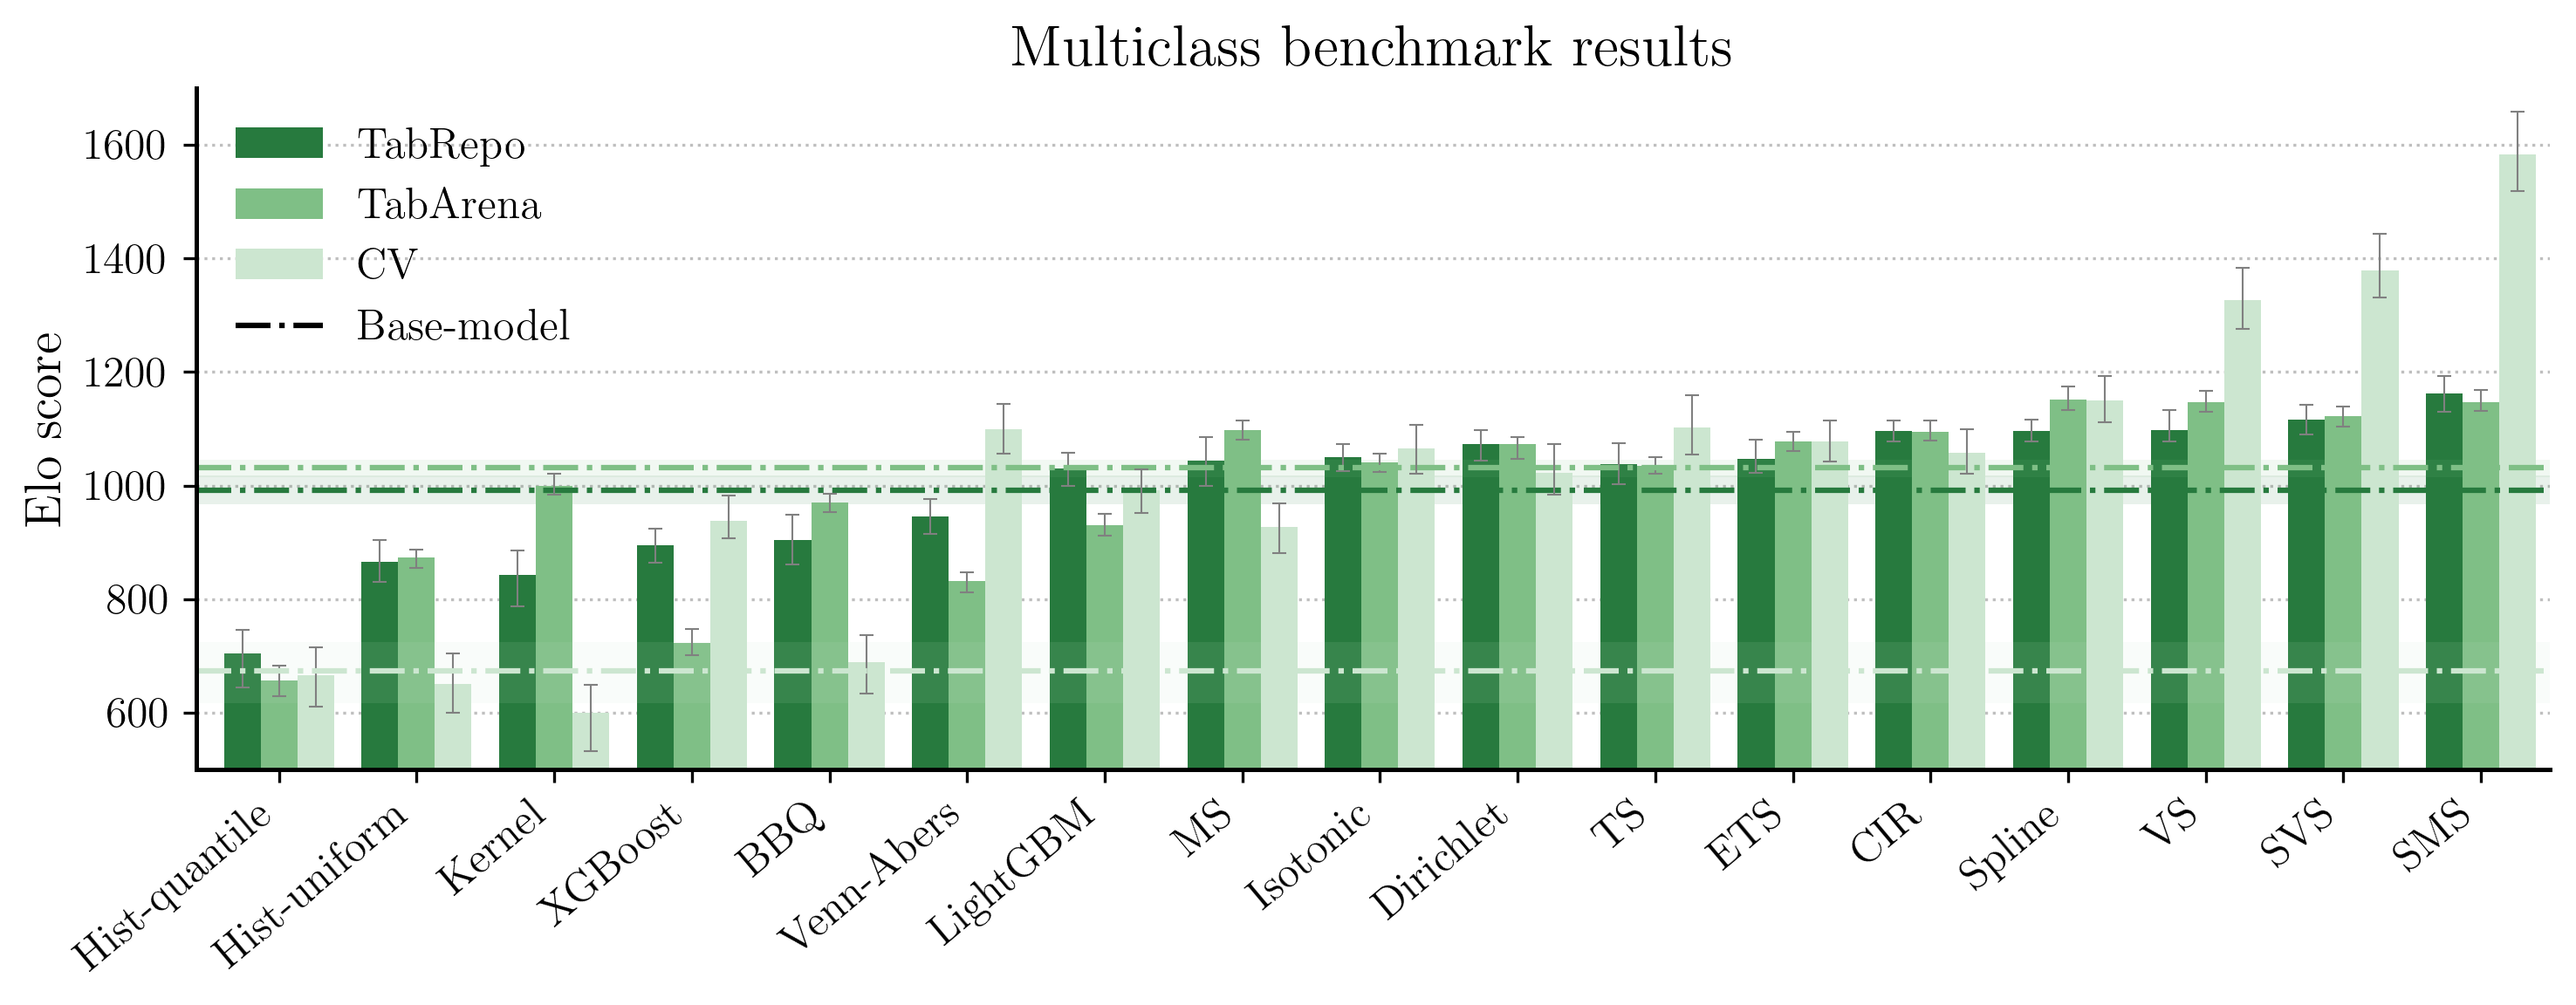

In [43]:
plot_grouped_leaderboards(
    {"TabRepo": multiclass_tabrepo_elo, "TabArena": multiclass_tabarena_elo, "CV": multiclass_cv_elo},
    title="Multiclass benchmark results",
    y_label="Elo score",
    y_lim=(500, 1700),
    savefile="figures/multiclass_elo.pdf",
    color="green"
)

## Num classes OvR experiment

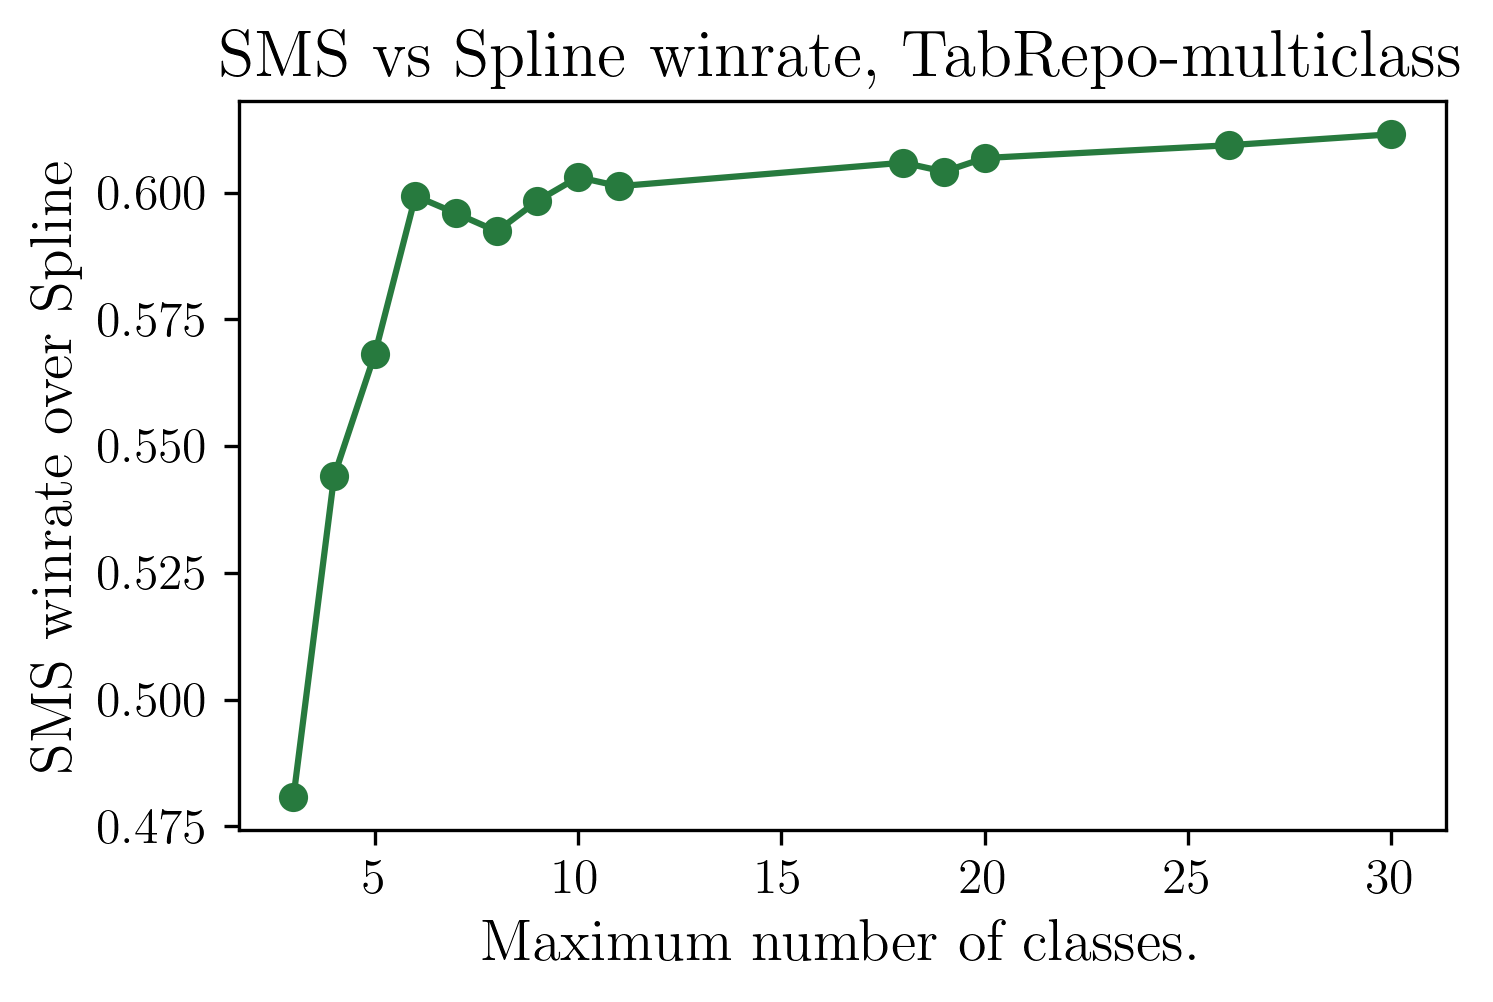

In [44]:
results = load_benchmark_results(benchmark_name="TabRepo-multiclass", methods=["Spline", "SMS"])
n_classes = results.n_classes.unique()
n_classes.sort()

sms_winrate = []
for n_class in n_classes:
    results_filter = results[results.n_classes <= n_class]
    sms_winrate.append((results_filter["SMS_brier"] < results_filter["Spline_brier"]).mean().item())

fig, ax = plt.subplots(figsize=(5,3.5))

ax.plot(n_classes, sms_winrate, marker="o", color="#277a3e")

ax.set_xlabel("Maximum number of classes.")
ax.set_ylabel("SMS winrate over Spline")

ax.set_title("SMS vs Spline winrate, TabRepo-multiclass")

plt.tight_layout()

plt.savefig("figures/sms_spline_winrate.pdf", bbox_inches="tight")

plt.show()

# Calibration designs experiment

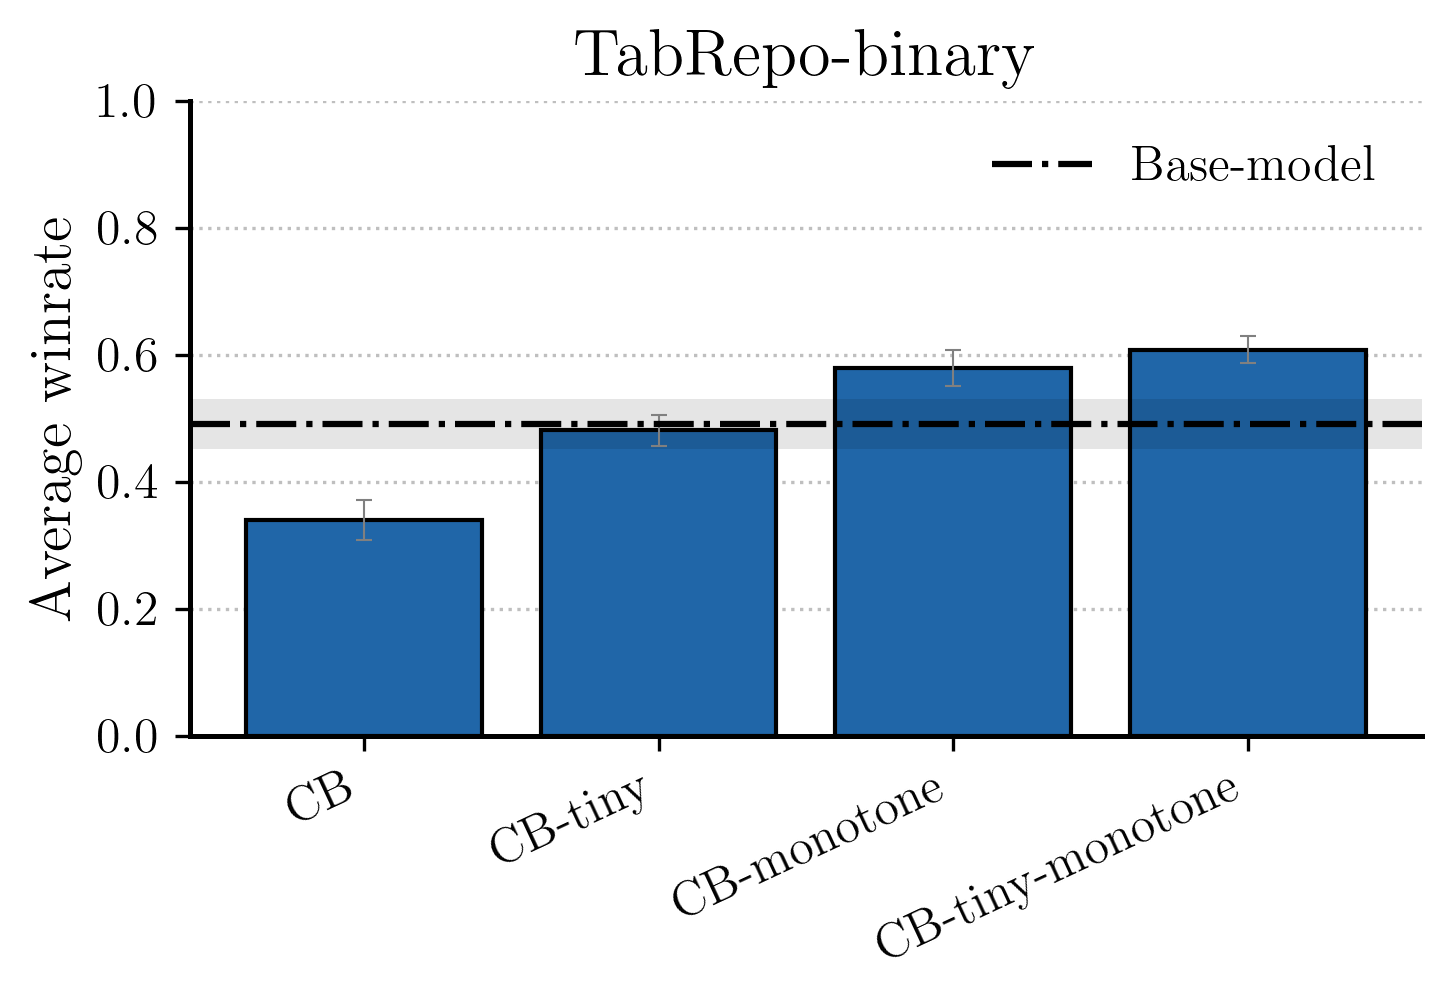

In [45]:
results = load_benchmark_results(benchmark_name="TabRepo-binary", methods=["Base-model", "CB", "CB-tiny", "CB-monotone", "CB-tiny-monotone"])
winrates = compute_winrates(results, ["Base-model", "CB", "CB-tiny", "CB-monotone", "CB-tiny-monotone"], metric="brier", bootstrap_datasets=True, n_bootstraps=1000)
plot_leaderboard(
    winrates,
    title="TabRepo-binary",
    y_label="Average winrate",
    y_lim=(0,1),
    savefile="figures/catboost_ablation.pdf",
    figsize=(5,3.5),
    xticks_rotation=25
)

# Runtimes

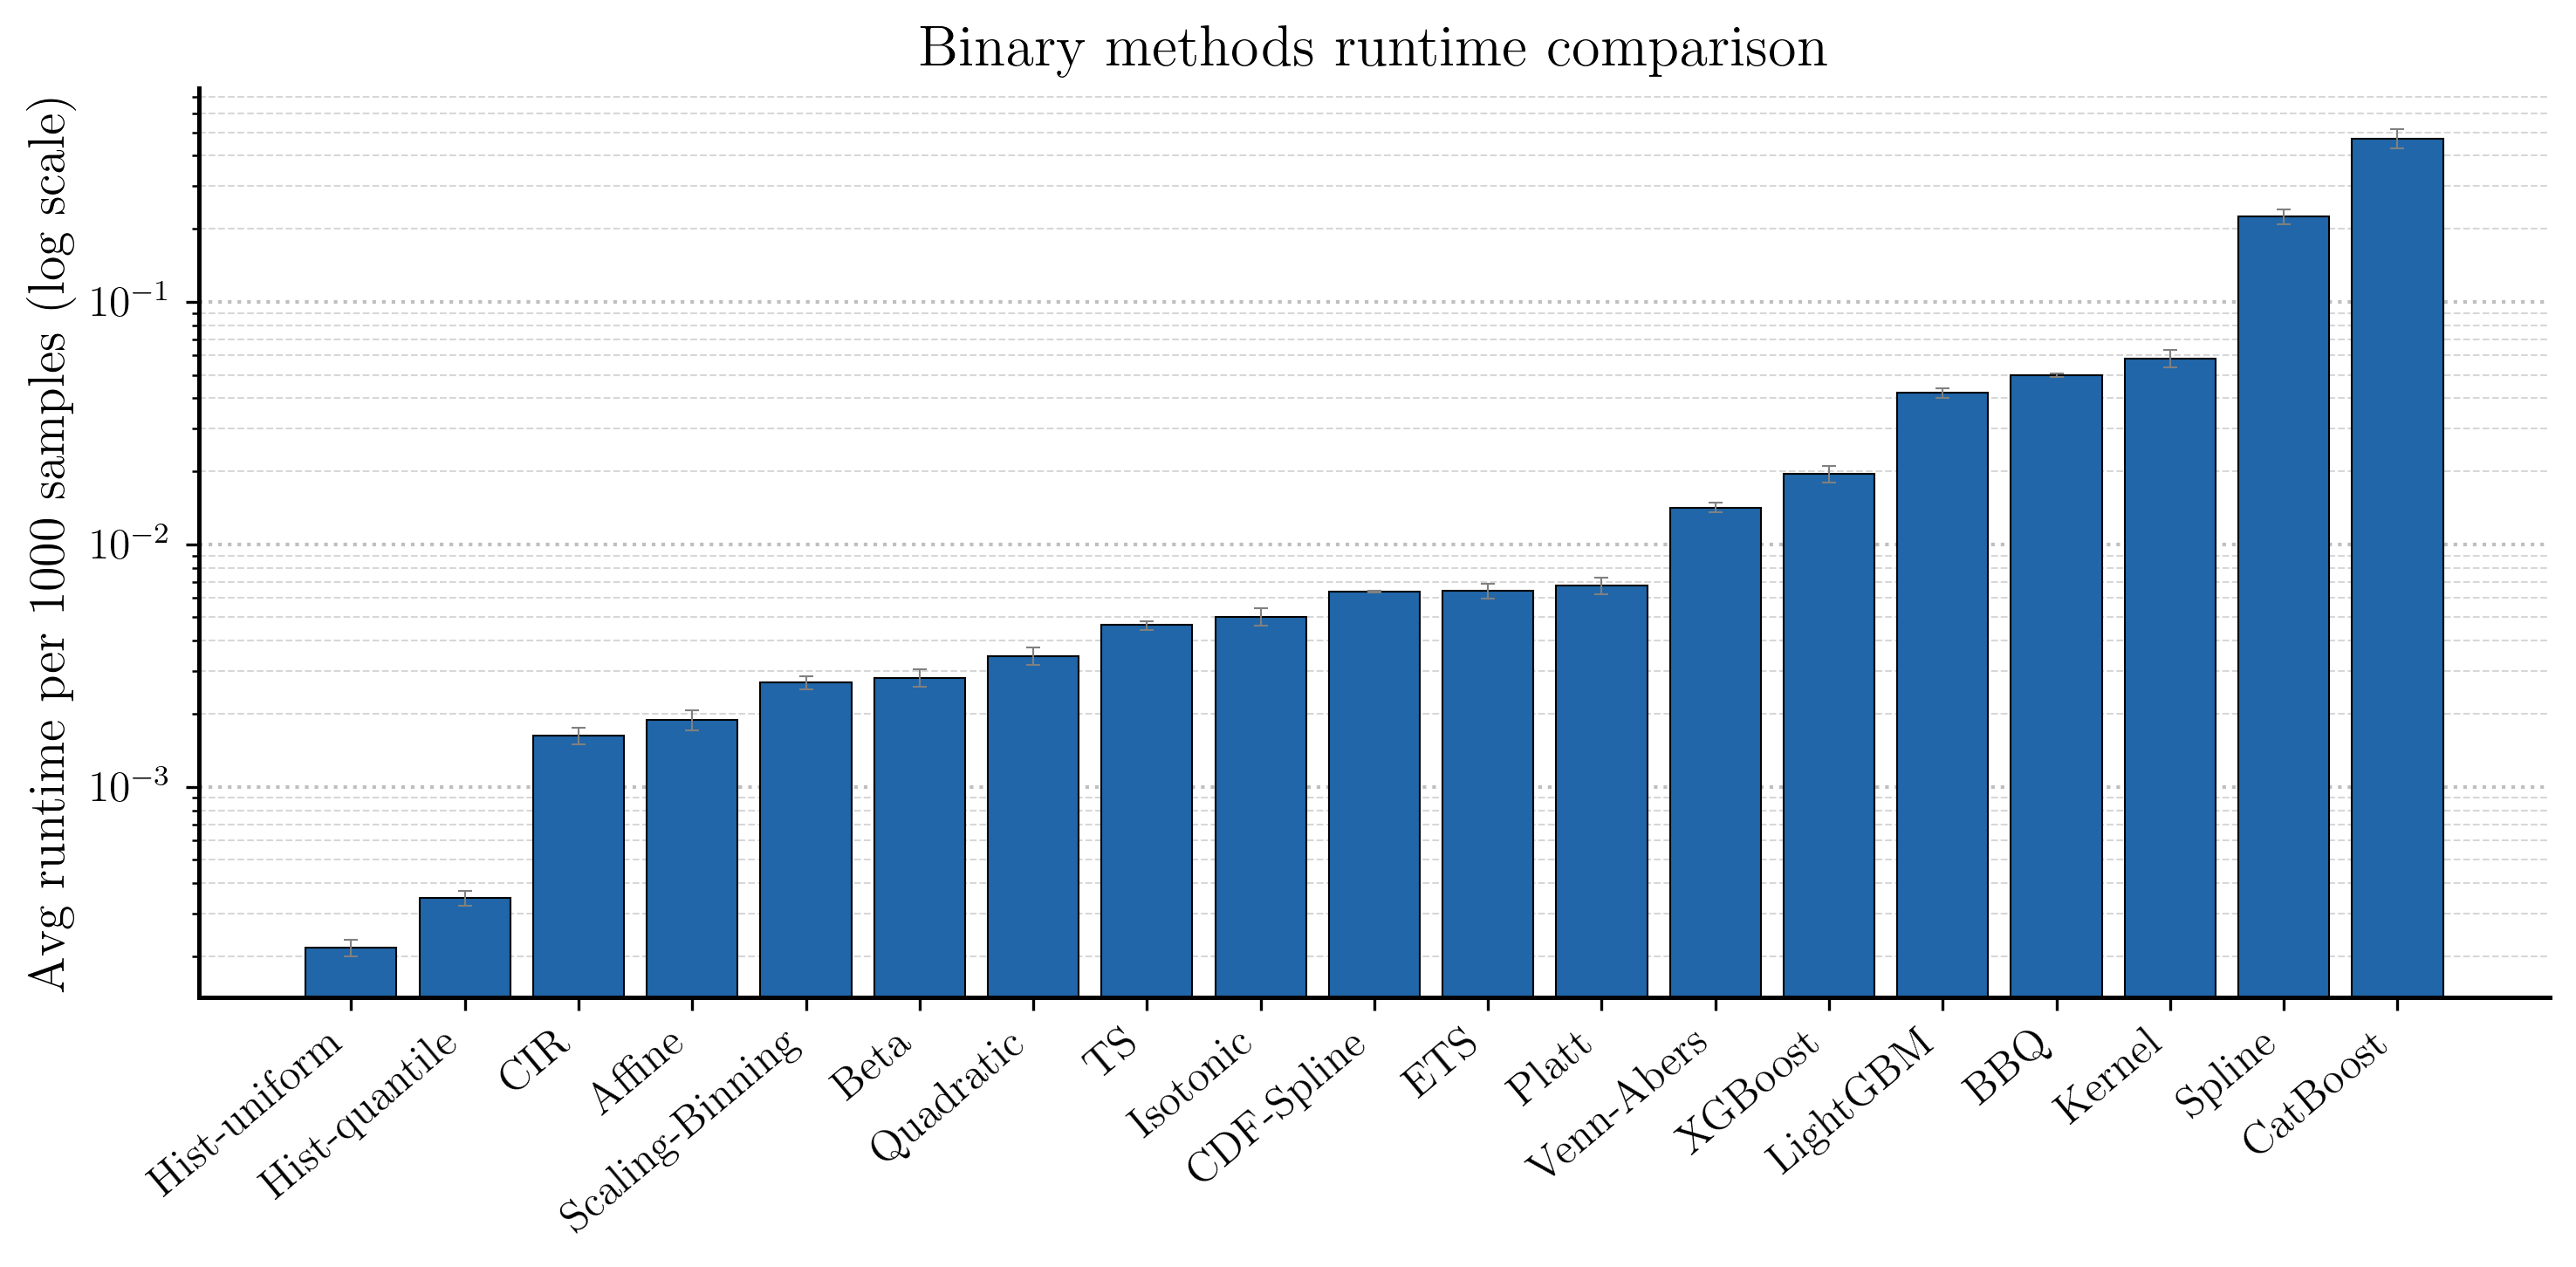

In [46]:
results_binary = pd.concat([binary_tabrepo_results, binary_tabarena_results, binary_cv_results])

methods = binary_methods.copy()
methods.remove("Base-model")

df = results_binary[[f"{method}_time" for method in methods]].copy()
df = df.rename(columns={f"{method}_time": method for method in methods})

df["cal_size"] = results_binary["cal_size"]

for method in methods:
    df[method] = 1000 * df[method] / df["cal_size"]

table = pd.DataFrame({
    "time_mean": df[methods].mean(),
    "time_err": 1.96 * df[methods].sem(),
})

table = table.sort_values(by="time_mean", ascending=True)

fig, ax = plt.subplots(figsize=(10,5))

bars = ax.bar(
    table.index, 
    table["time_mean"], 
    yerr=table["time_err"], 
    color="#2066a8",
    capsize=2,
    edgecolor="black",
    linewidth=0.5,
    error_kw={
        "elinewidth": 0.5,
        "capthick": 0.5,
        "ecolor": "gray",
    }
)
ax.grid(True, axis='y', which='minor', linestyle='--', linewidth=0.5, alpha=0.5)
ax.grid(True, axis='y', which='major', linestyle='-', linewidth=1.0, alpha=0.8)
ax.set_axisbelow(True)

ax.set_yscale("log")
ax.set_ylabel("Avg runtime per 1000 samples (log scale)")

ax.set_title("Binary methods runtime comparison")

ax.yaxis.grid(True, linestyle=":", alpha=0.5, color="gray")
ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1.2)
ax.spines["bottom"].set_linewidth(1.2)

plt.xticks(rotation=40, ha="right")

plt.tight_layout()

plt.savefig("figures/binary_runtimes.pdf", bbox_inches="tight")

plt.show()

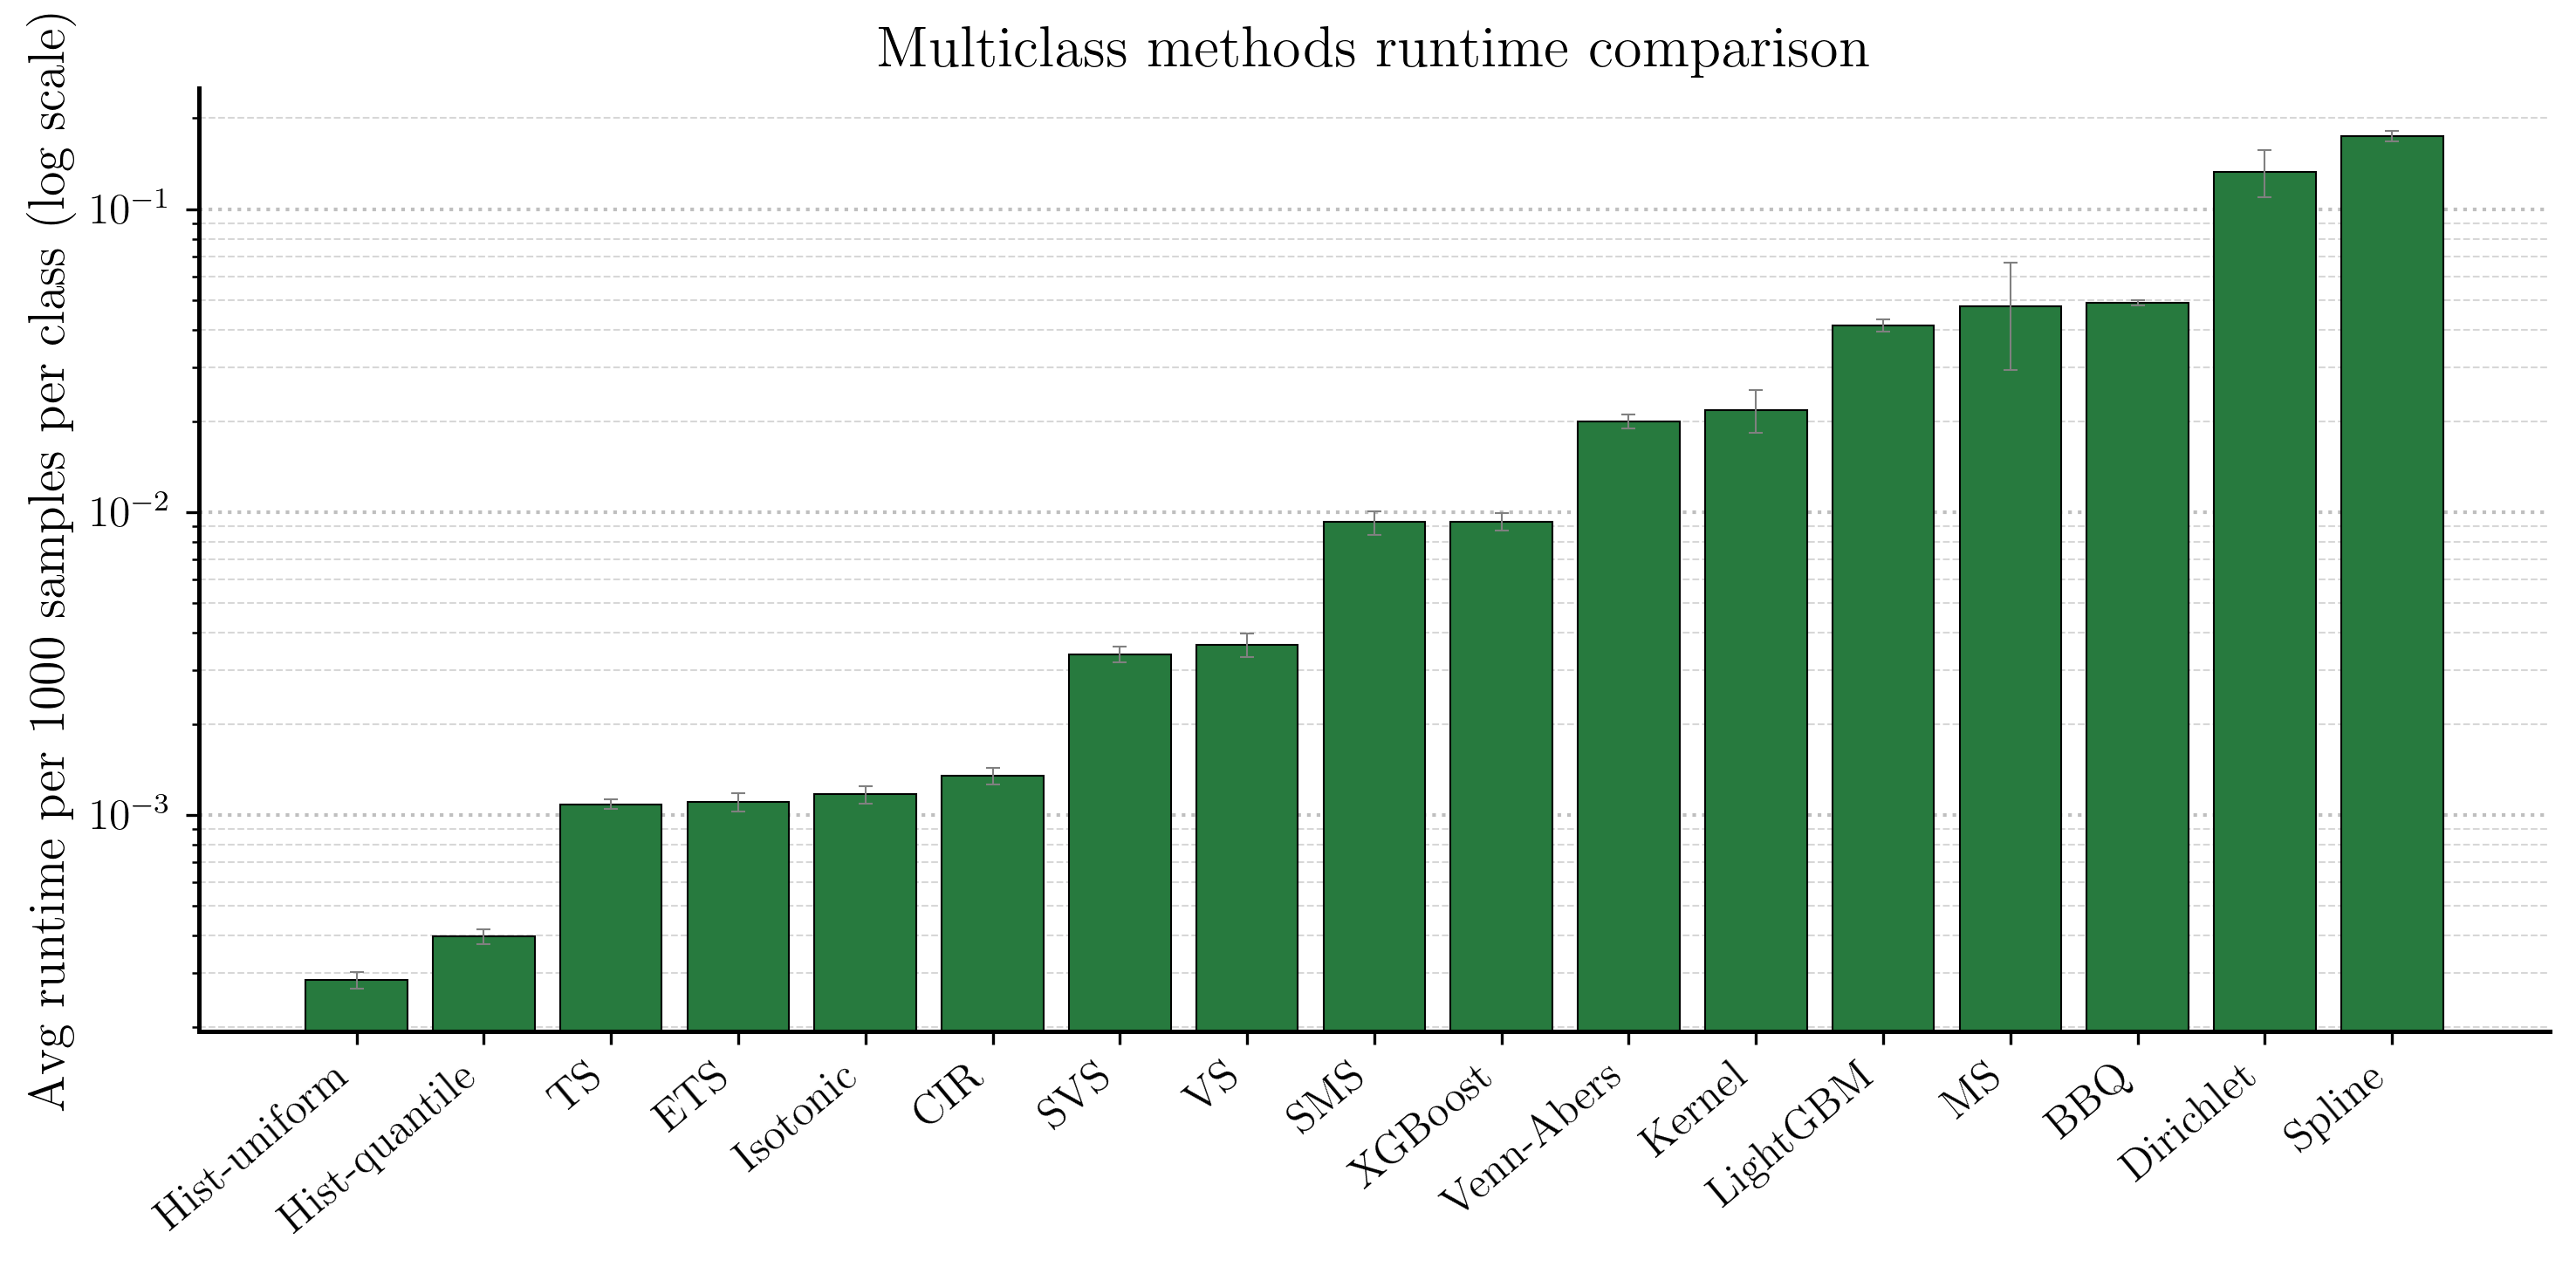

In [47]:
results_multiclass = pd.concat([multiclass_tabrepo_results, multiclass_tabarena_results, multiclass_cv_results])

methods = multiclass_methods.copy()
methods.remove("Base-model")

df = results_multiclass[[f"{method}_time" for method in methods]].copy()
df = df.rename(columns={f"{method}_time": method for method in methods})

df["cal_size"] = results_multiclass["cal_size"]
df["n_classes"] = results_multiclass["n_classes"]

for method in methods:
    df[method] = (1000 * df[method] / df["cal_size"]) / df["n_classes"]

table = pd.DataFrame({
    "time_mean": df[methods].mean(),
    "time_err": 1.96 * df[methods].sem(),
})

table = table.sort_values(by="time_mean", ascending=True)

fig, ax = plt.subplots(figsize=(10,5))

bars = ax.bar(
    table.index, 
    table["time_mean"], 
    yerr=table["time_err"], 
    color="#277a3e",
    capsize=2,
    edgecolor="black",
    linewidth=0.5,
    error_kw={
        "elinewidth": 0.5,
        "capthick": 0.5,
        "ecolor": "gray",
    }
)
ax.grid(True, axis='y', which='minor', linestyle='--', linewidth=0.5, alpha=0.5)
ax.grid(True, axis='y', which='major', linestyle='-', linewidth=1.0, alpha=0.8)
ax.set_axisbelow(True)

ax.set_yscale("log")
ax.set_ylabel("Avg runtime per 1000 samples per class (log scale)")

ax.set_title("Multiclass methods runtime comparison")

ax.yaxis.grid(True, linestyle=":", alpha=0.5, color="gray")
ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1.2)
ax.spines["bottom"].set_linewidth(1.2)

plt.xticks(rotation=40, ha="right")

plt.tight_layout()

plt.savefig("figures/multiclass_runtimes.pdf", bbox_inches="tight")

plt.show()